The code below imports all the necessary functions to plot out the visualizations and configure MongoDB client to connect and access the data. The outputs have keyboard interrupt as the output will be too long if left to run for long.

In [1]:
from pymongo import MongoClient
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from datetime import datetime
host_ip = "192.168.1.108"

client = MongoClient(host_ip, 27017)
db = client.a2_db
violations = db.violations_daily_summary



This plots the violations count against time. It starts by aggregating the violations based on timestamp_end and counting the amount of violations for each timestamp_end. The data is then sorted by ascending order of timestamp_end and saved in violations_list

Then, using matplotlib, it plots the data from violations_list into individual plots, with the first plot showing the first 10 data and the subsequent plots showing the previous 9 and the next 1, simulating an updating chart.

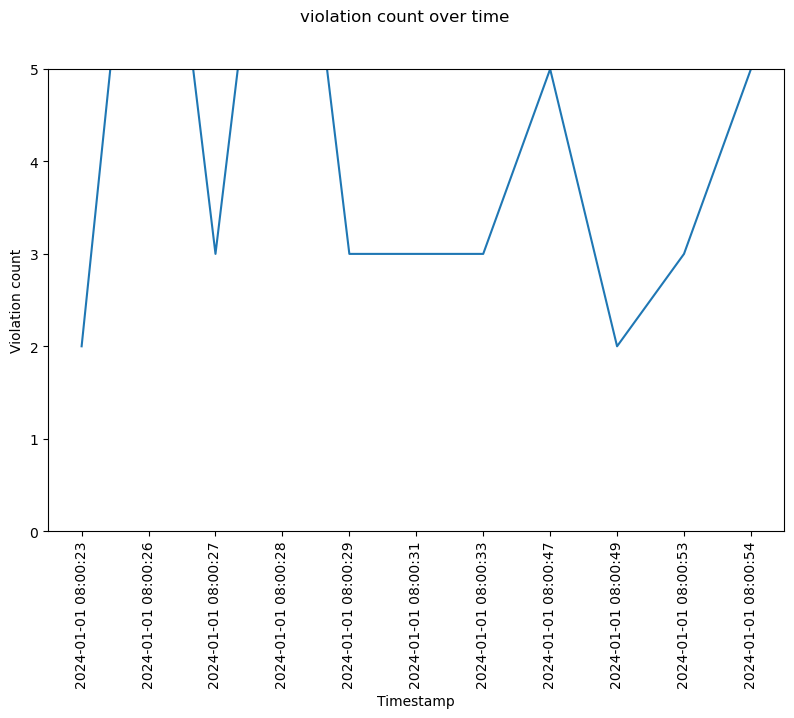

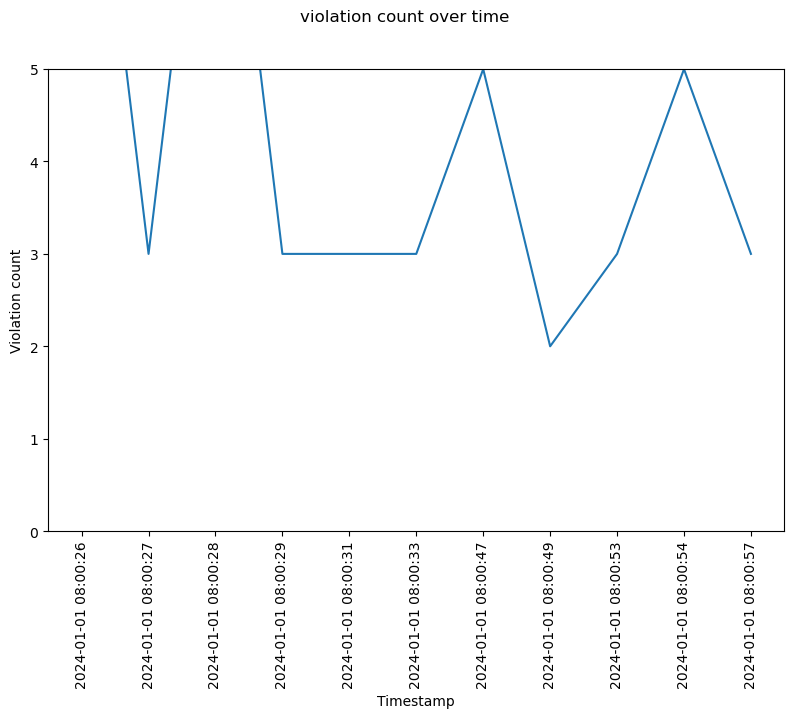

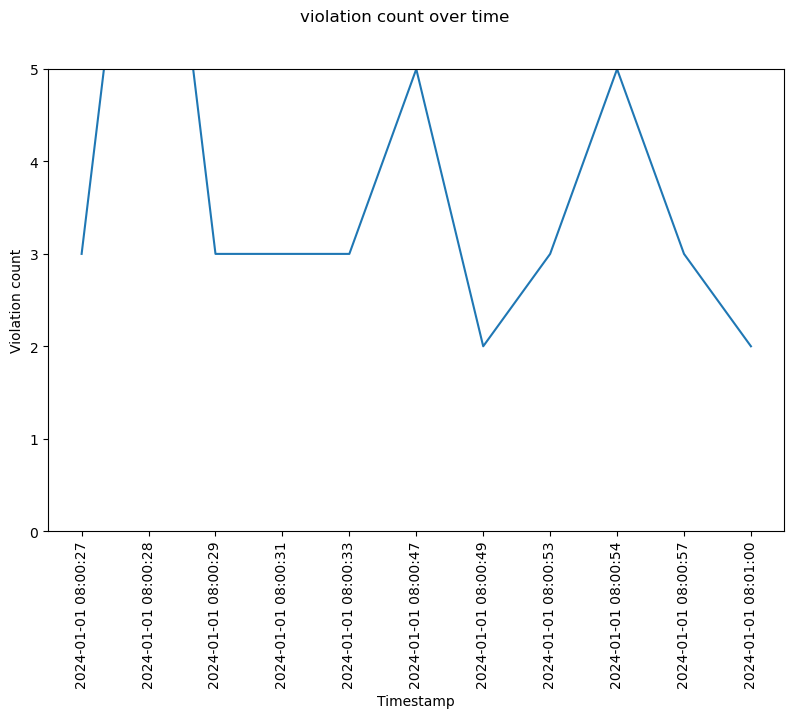

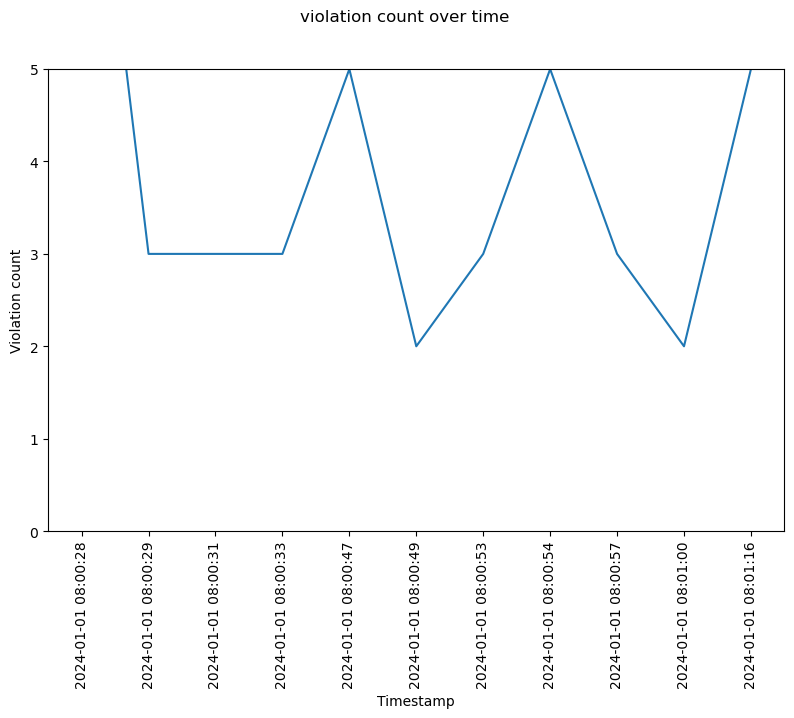

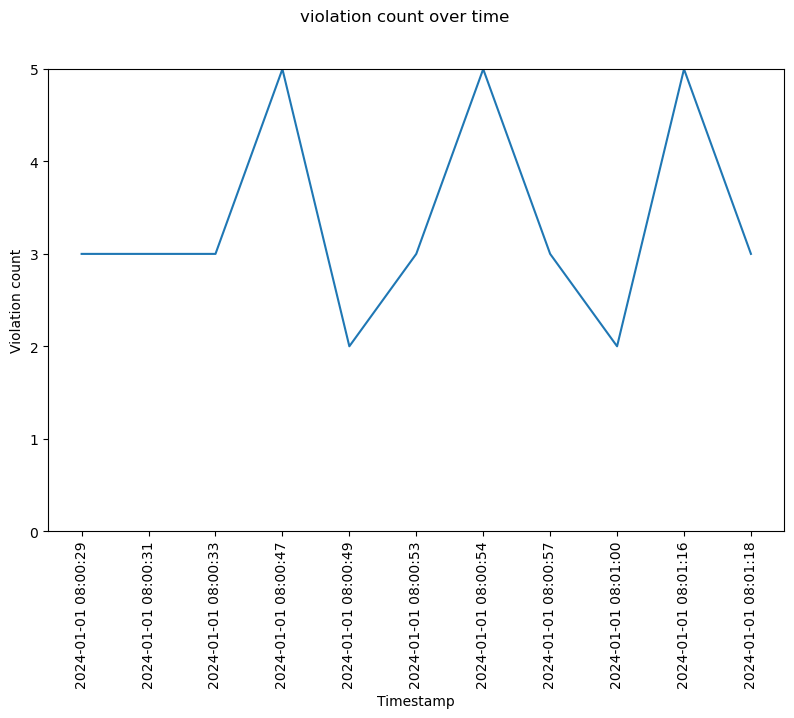

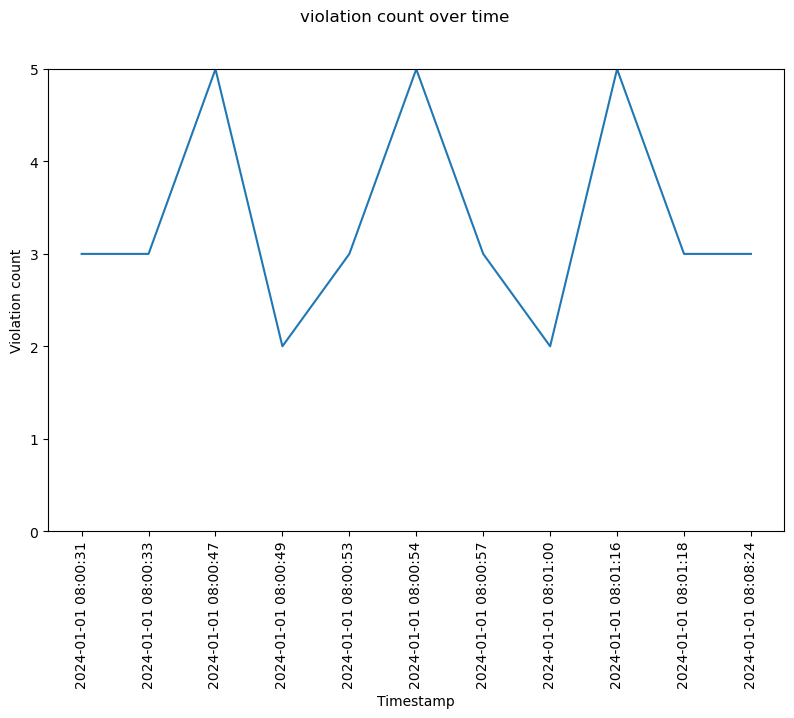

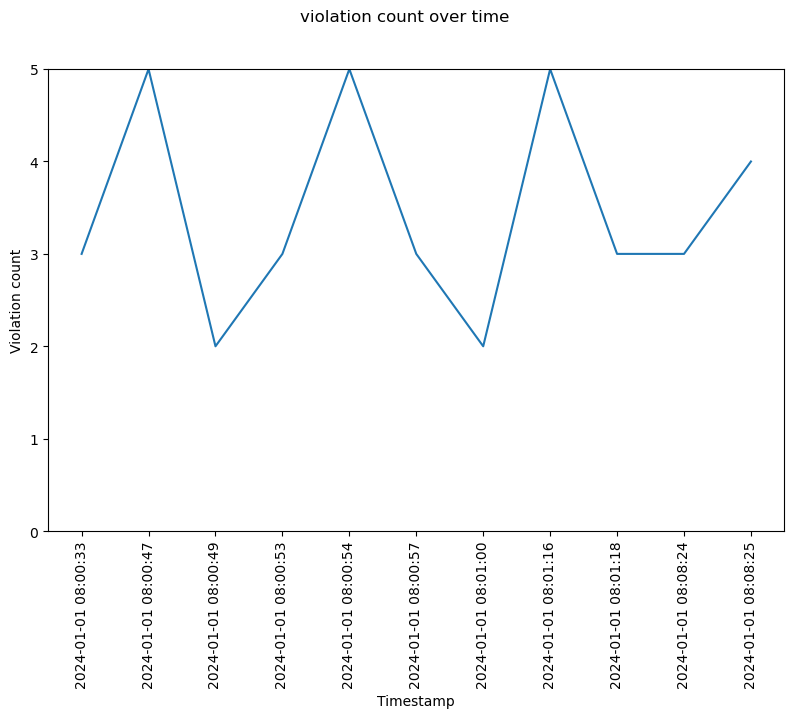

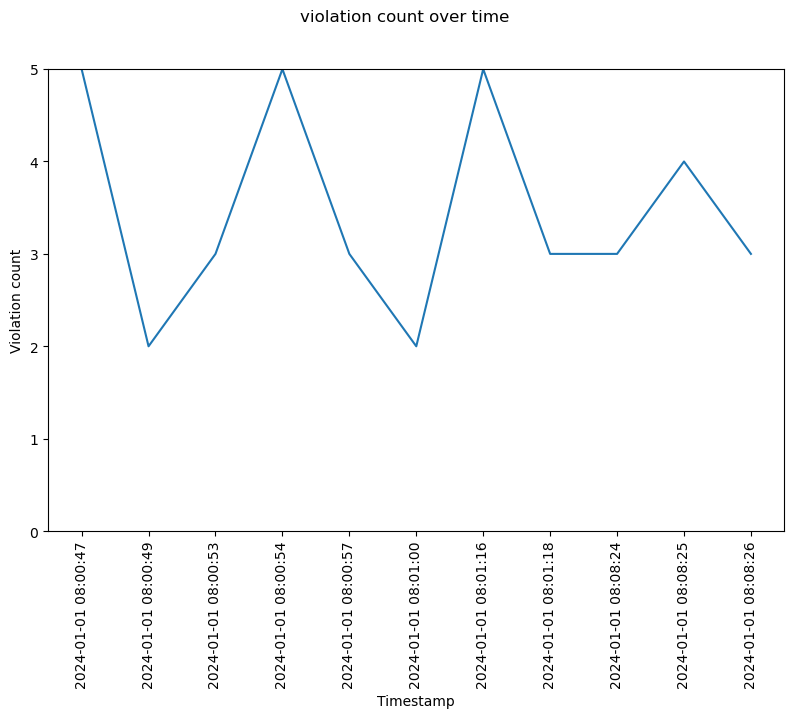

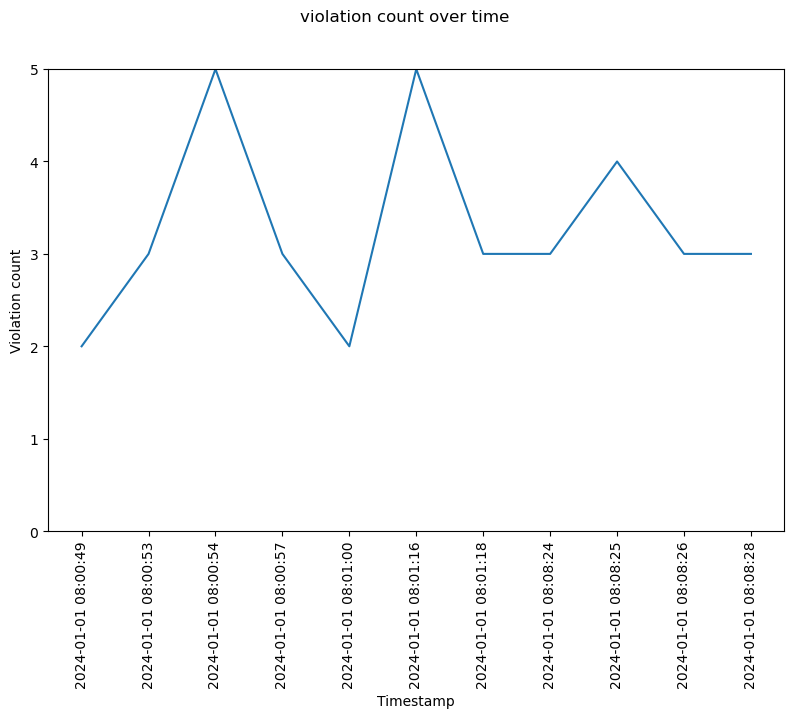

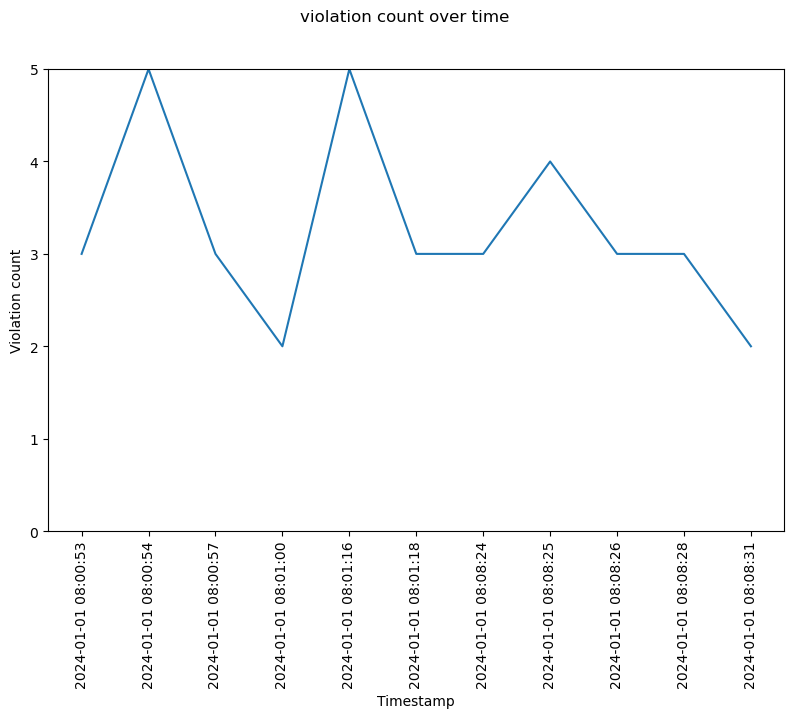

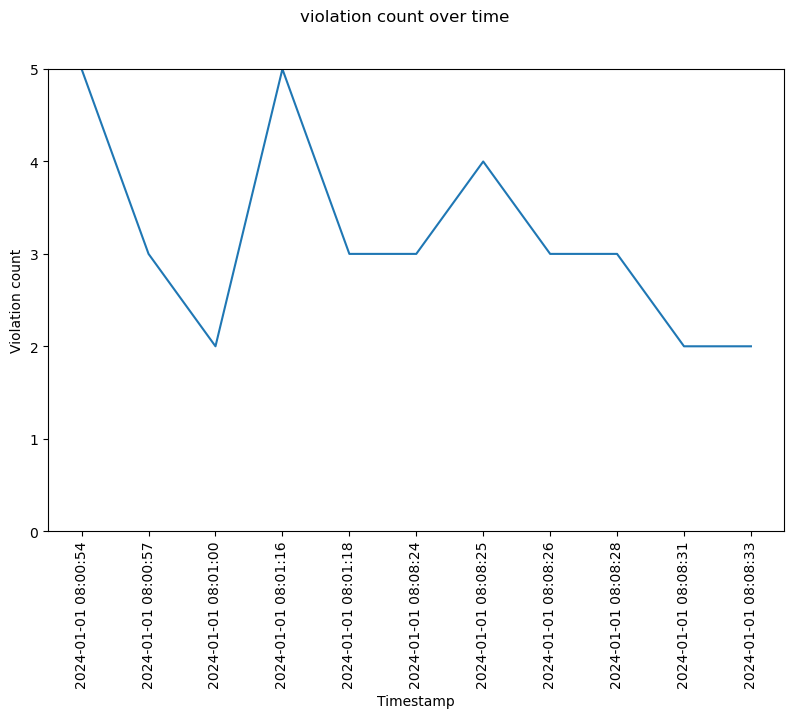

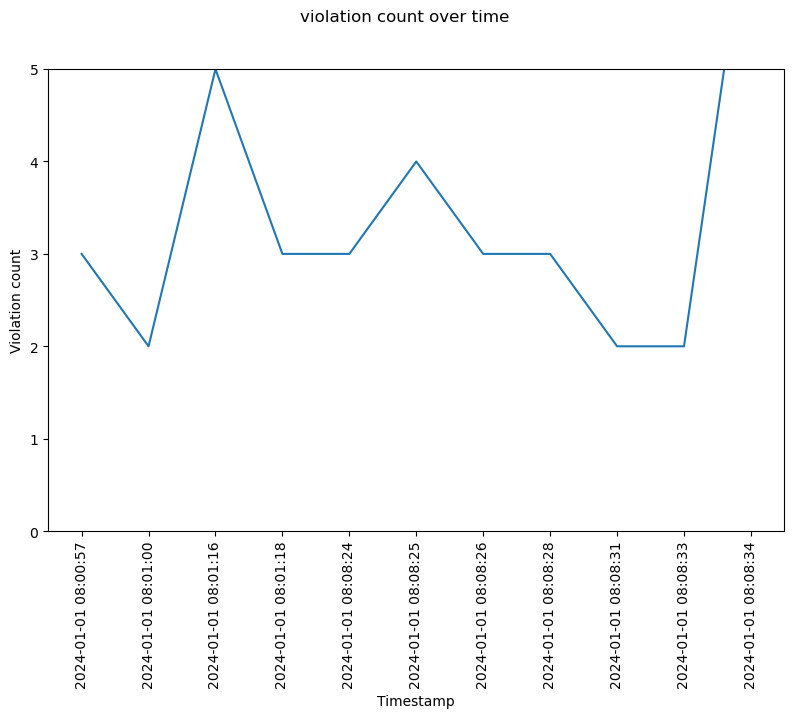

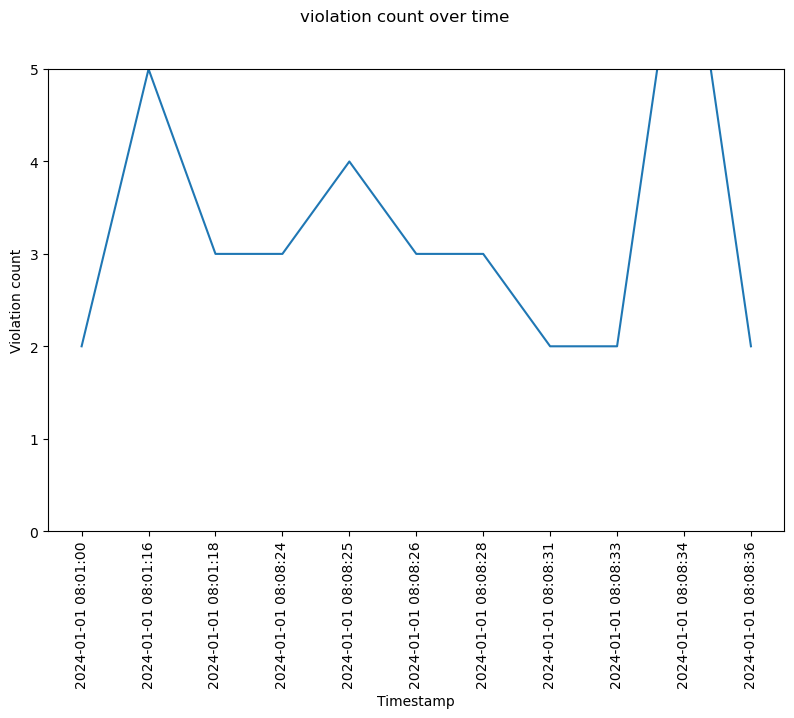

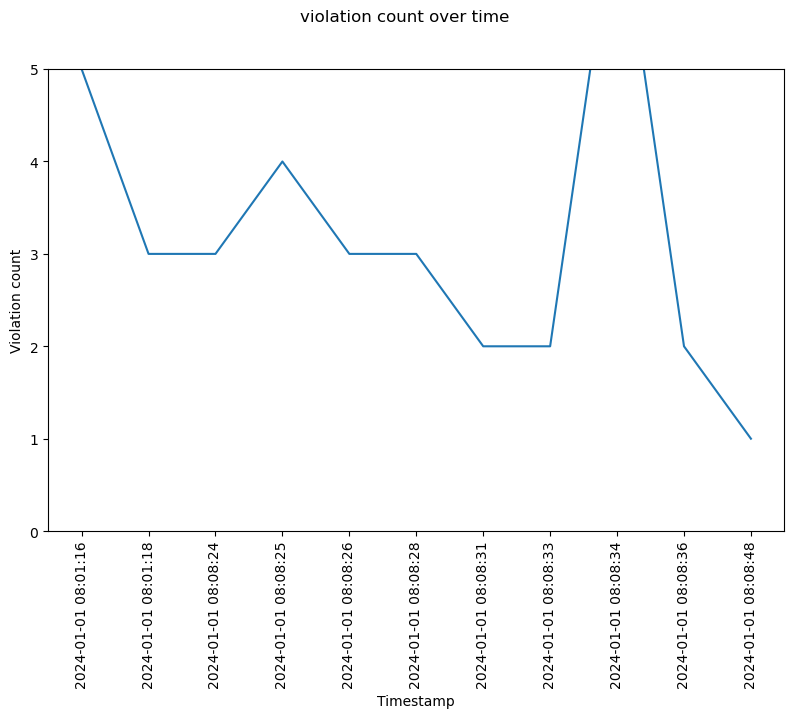

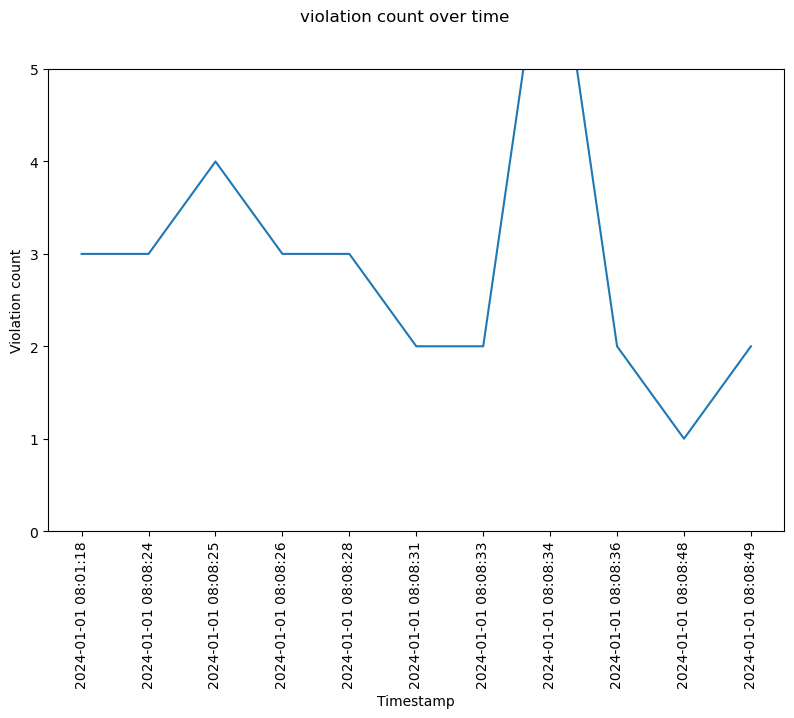

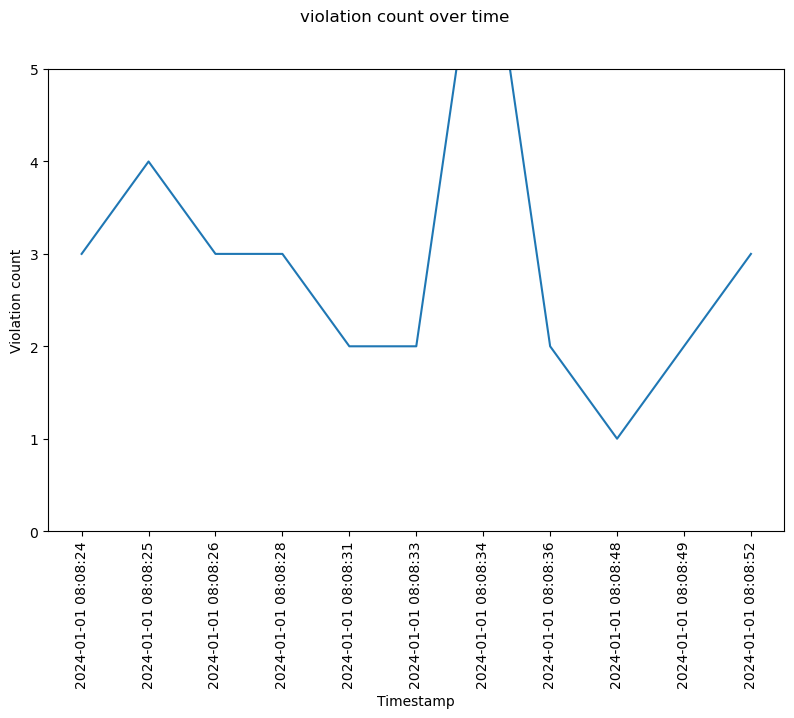

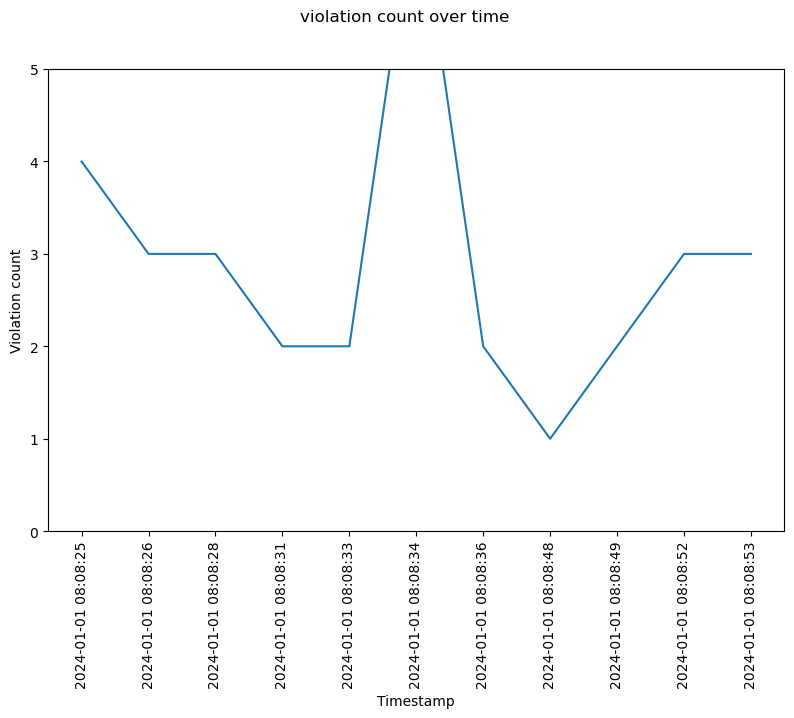

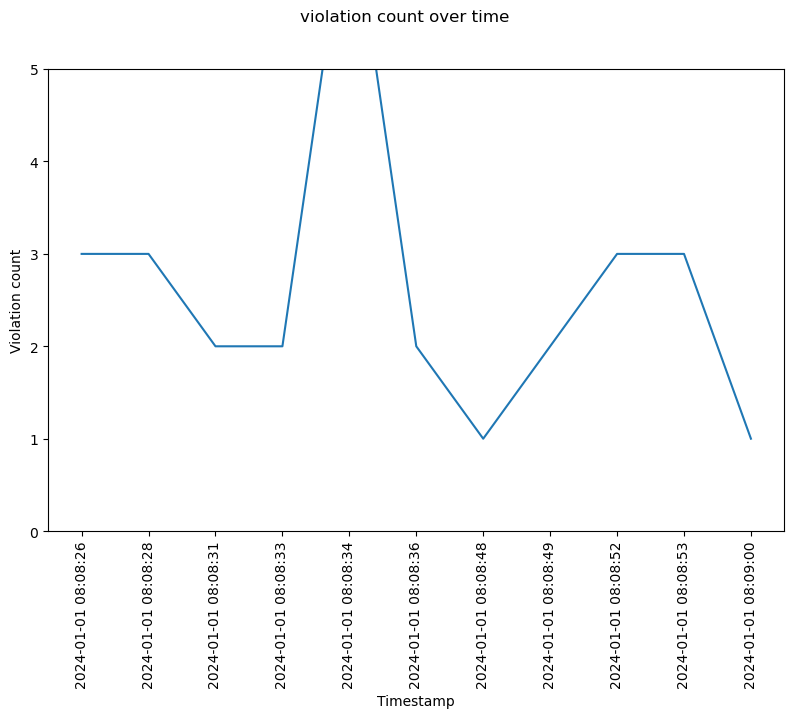

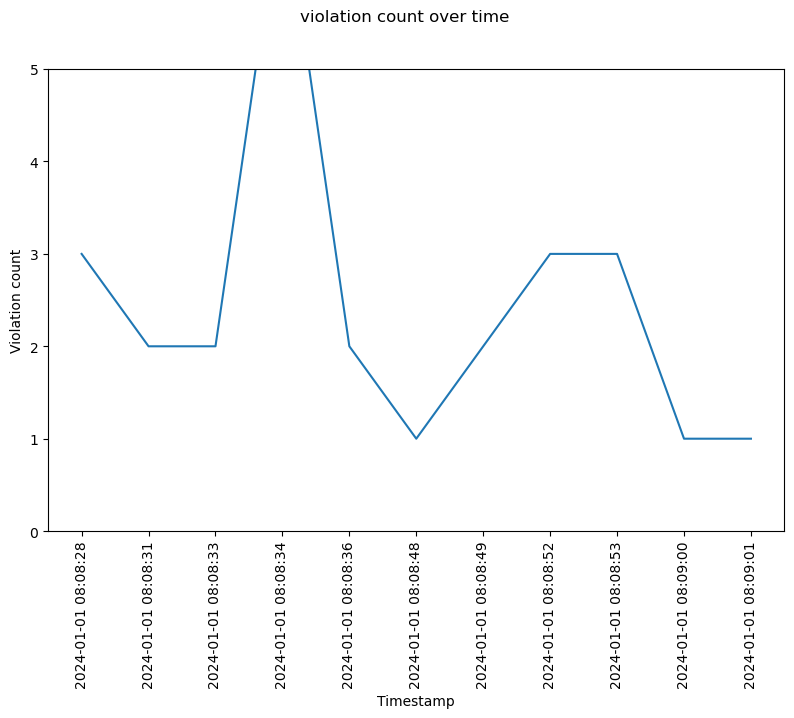

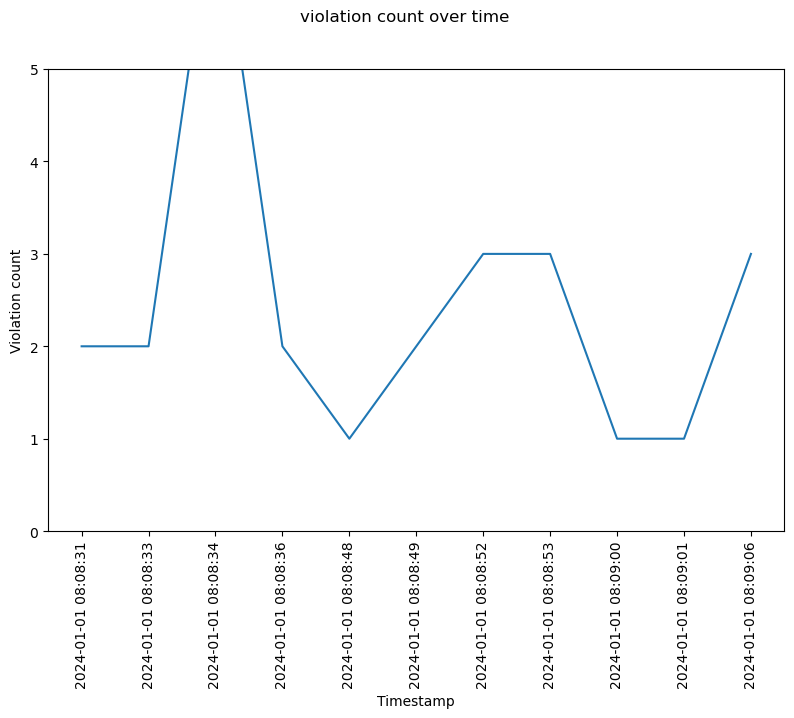

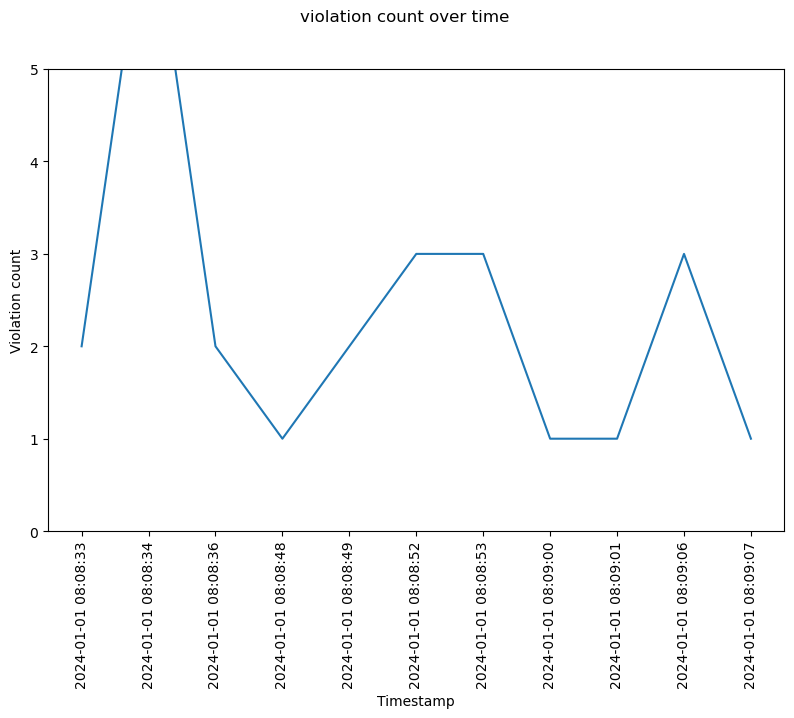

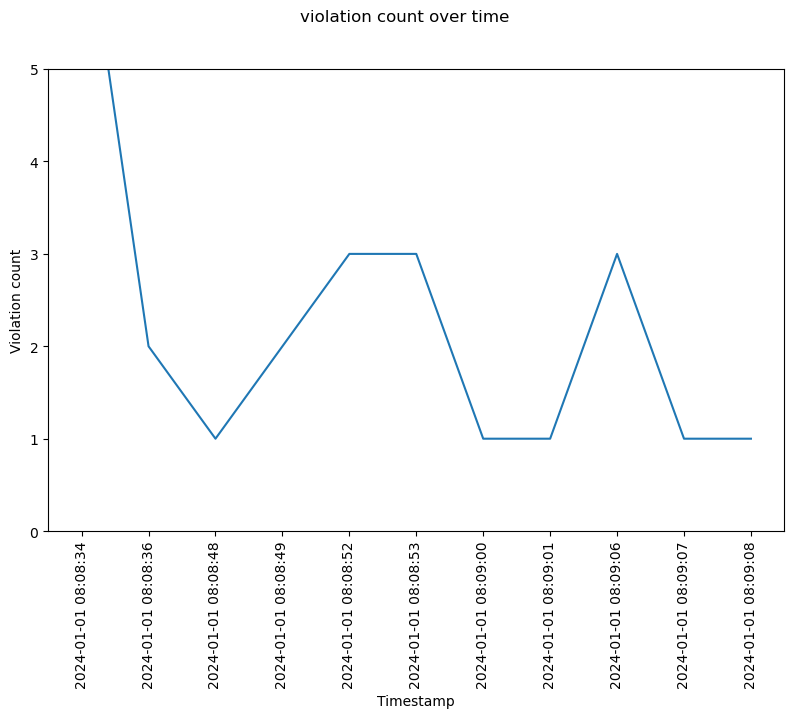

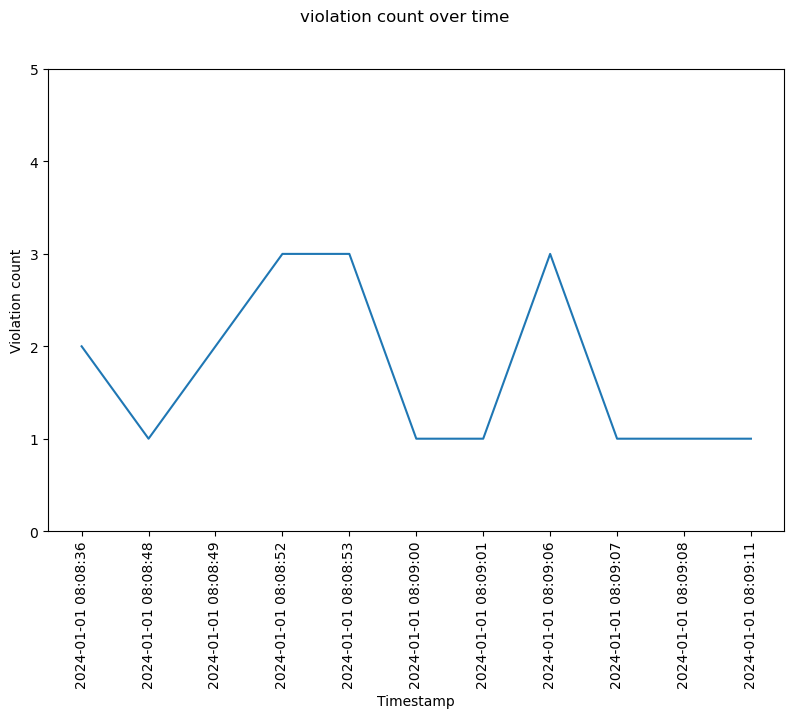

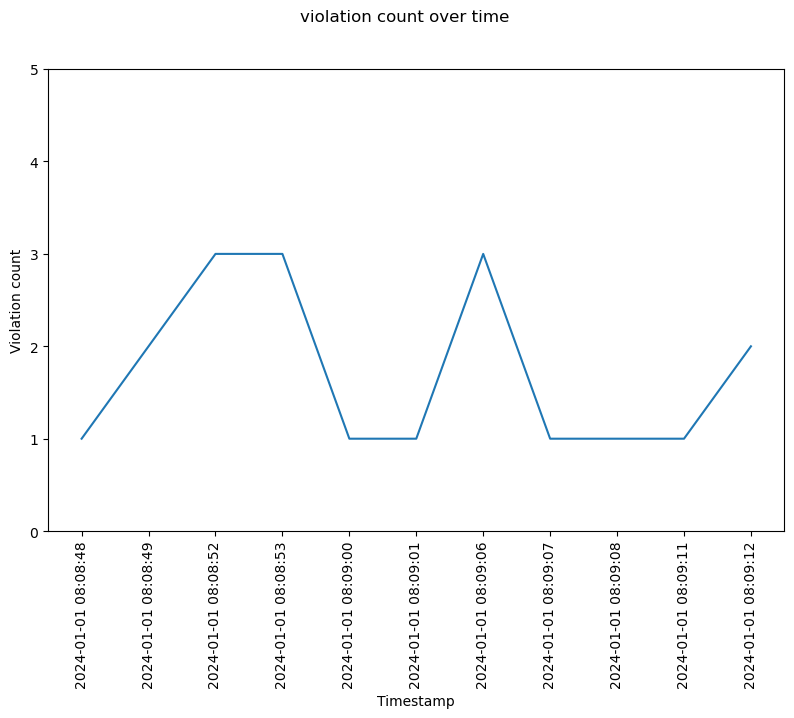

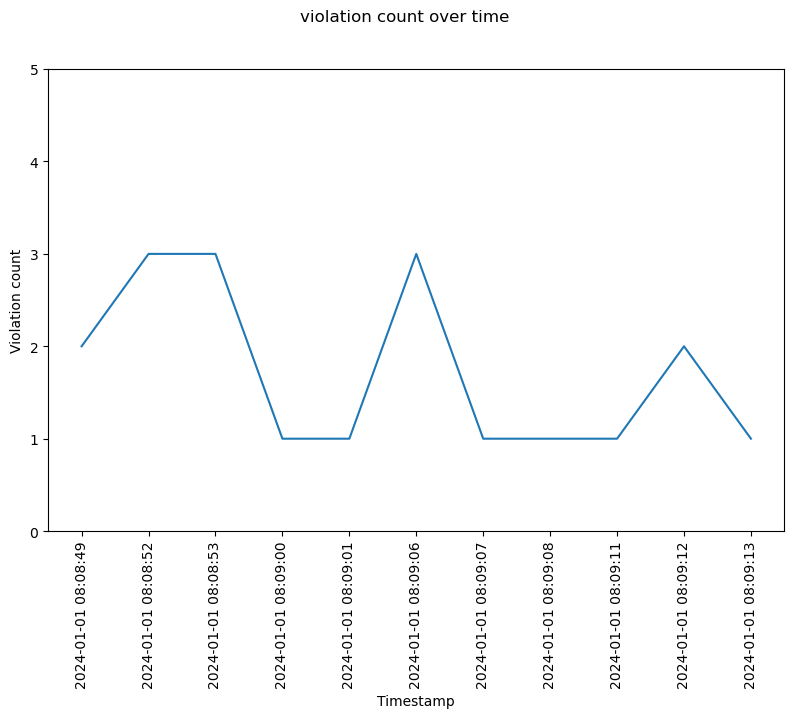

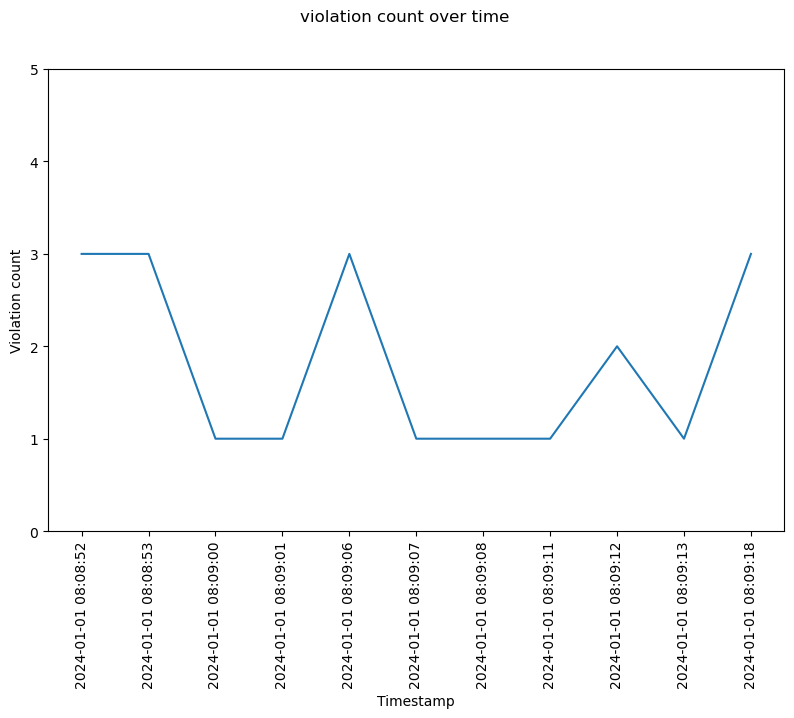

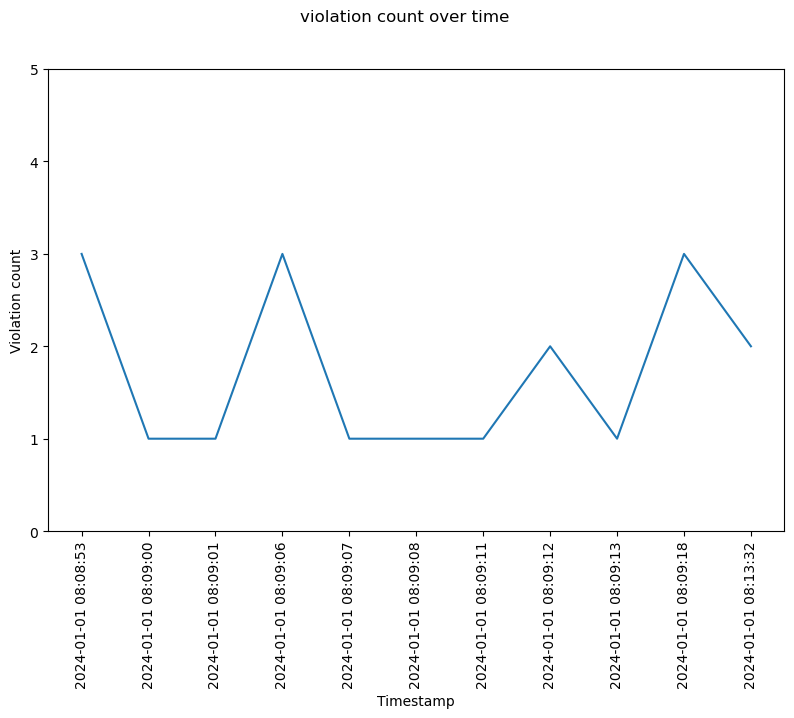

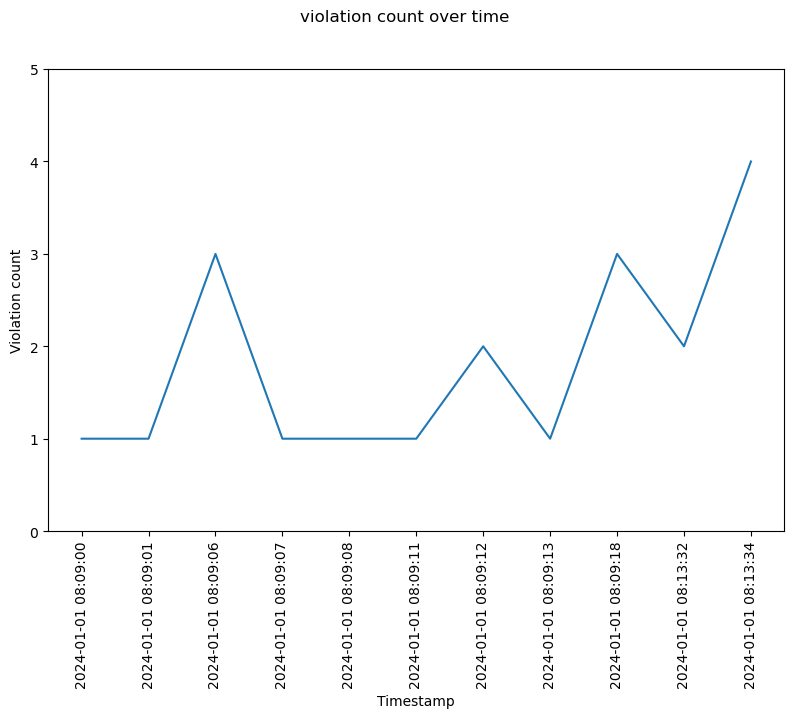

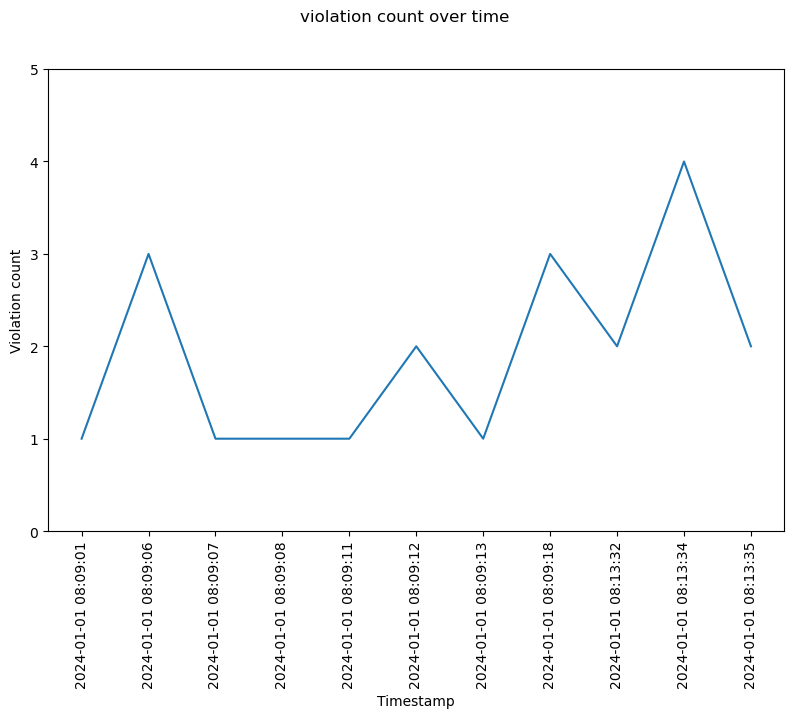

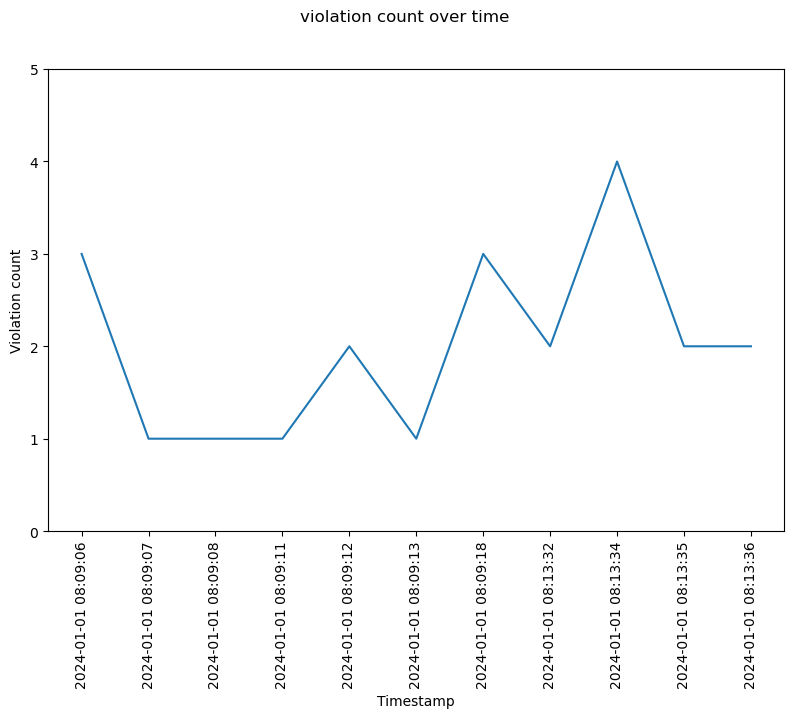

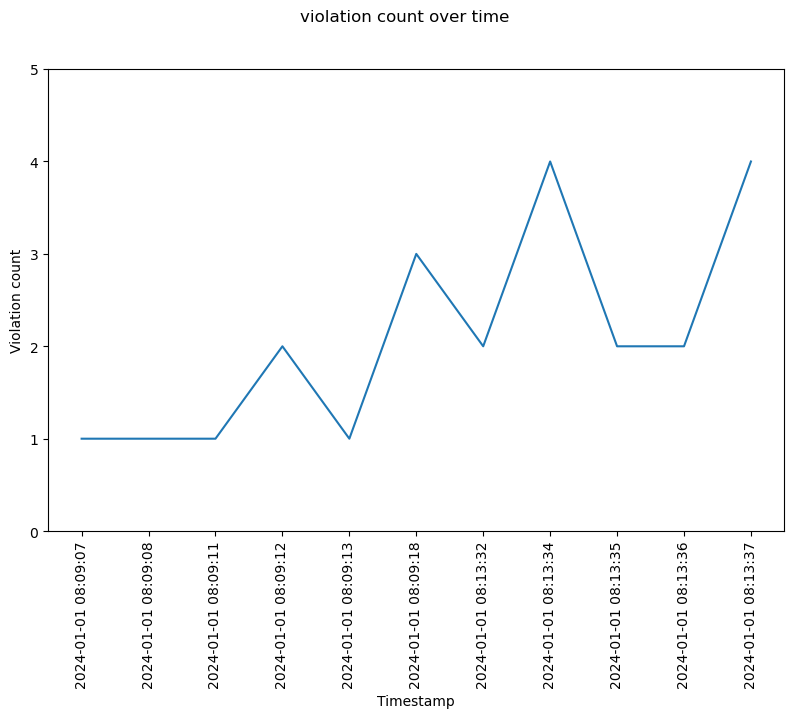

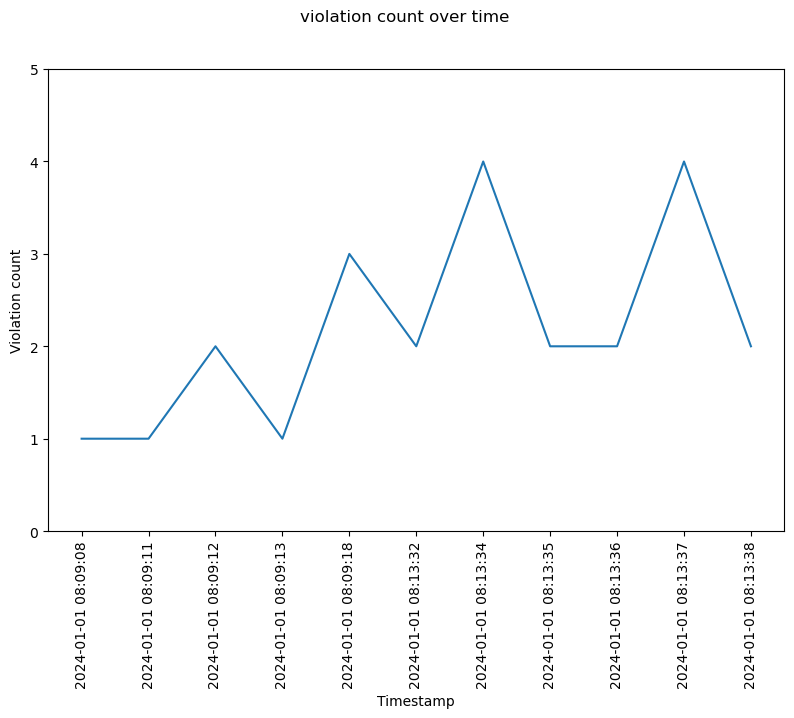

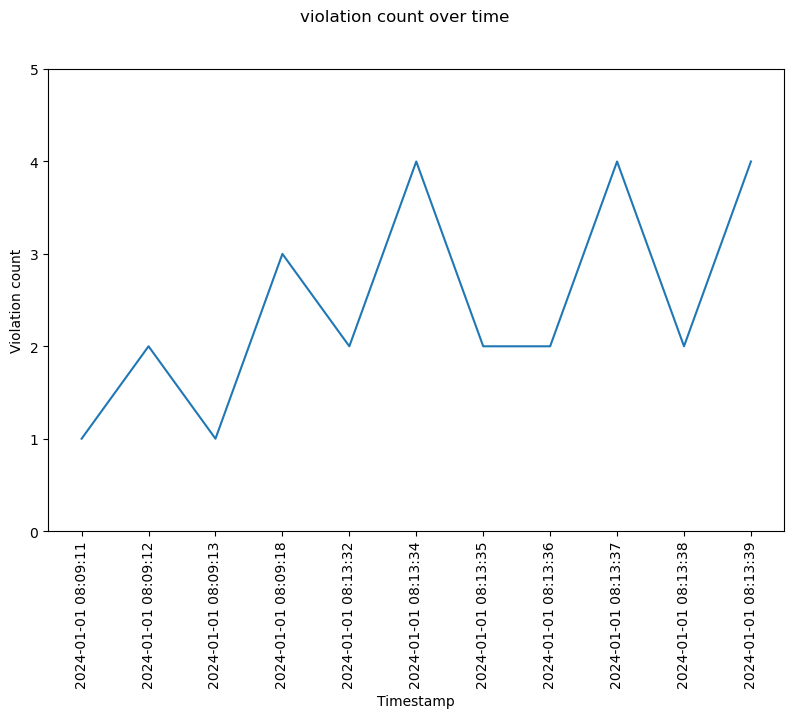

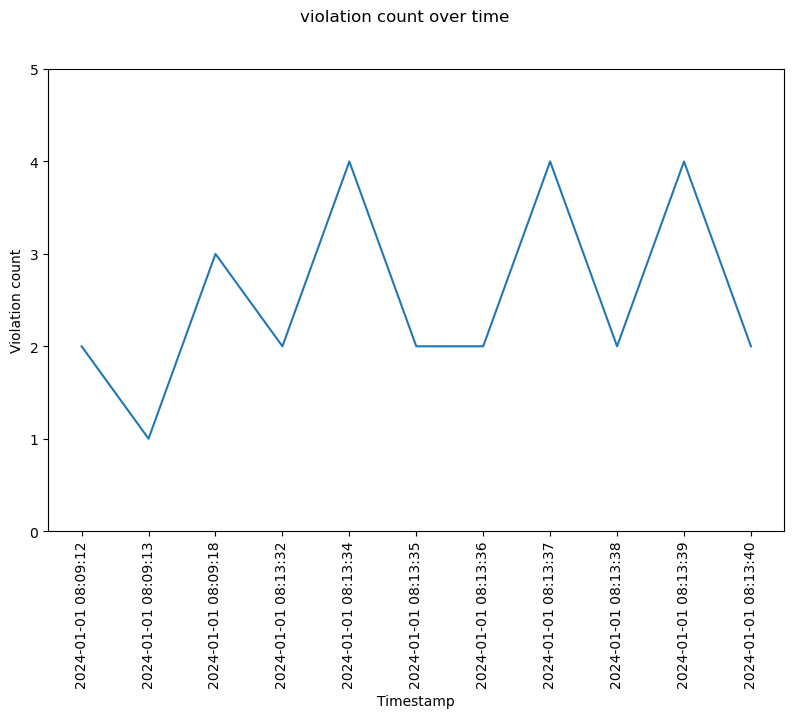

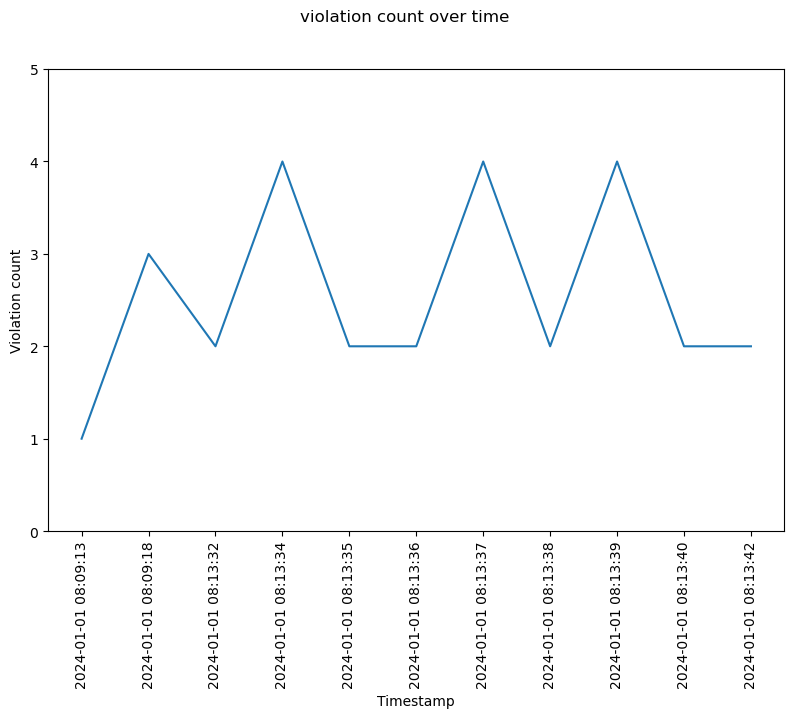

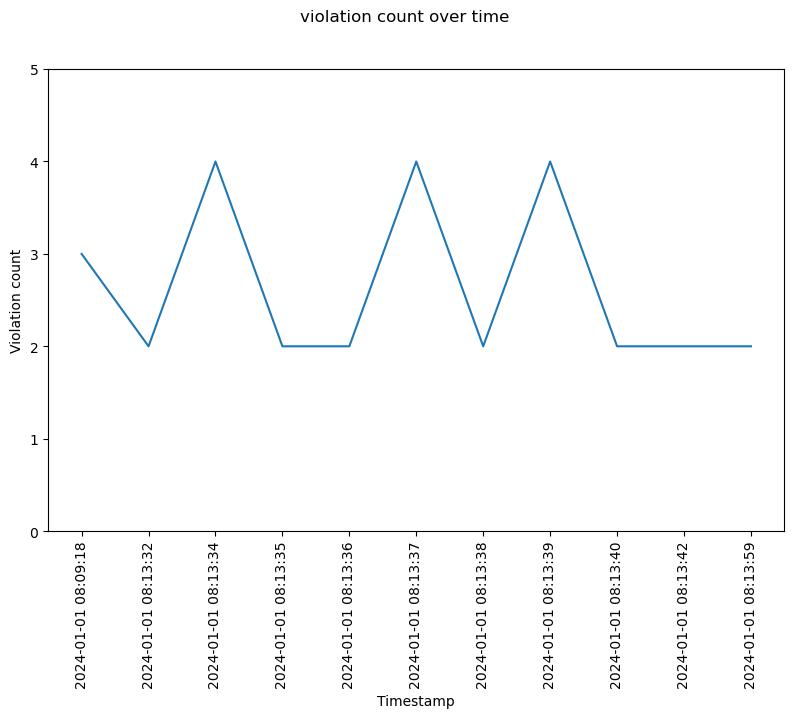

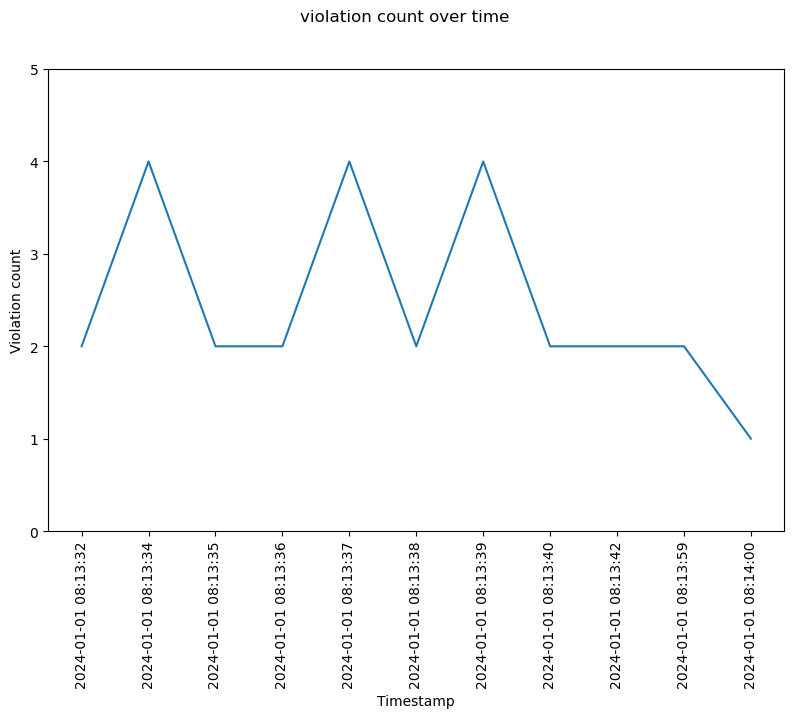

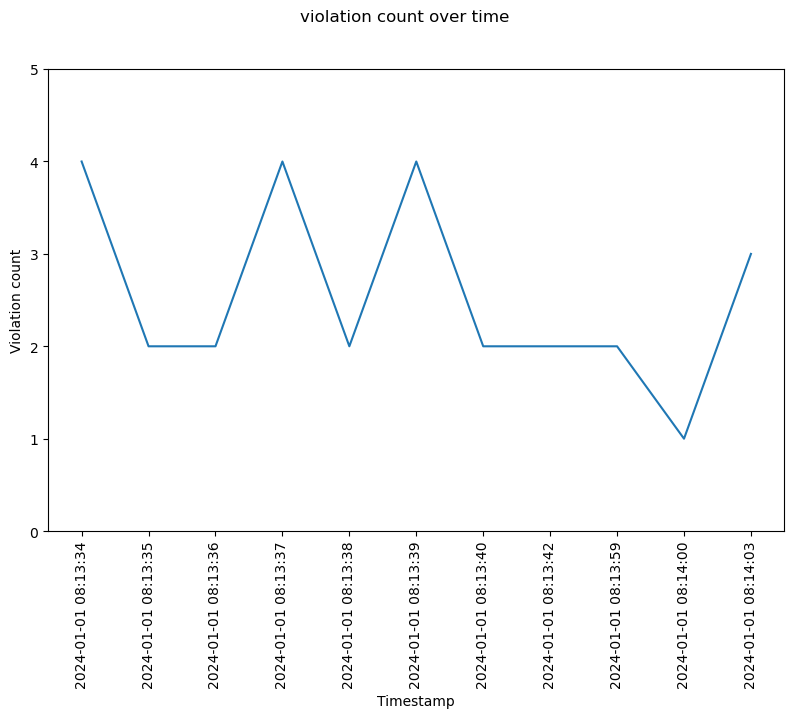

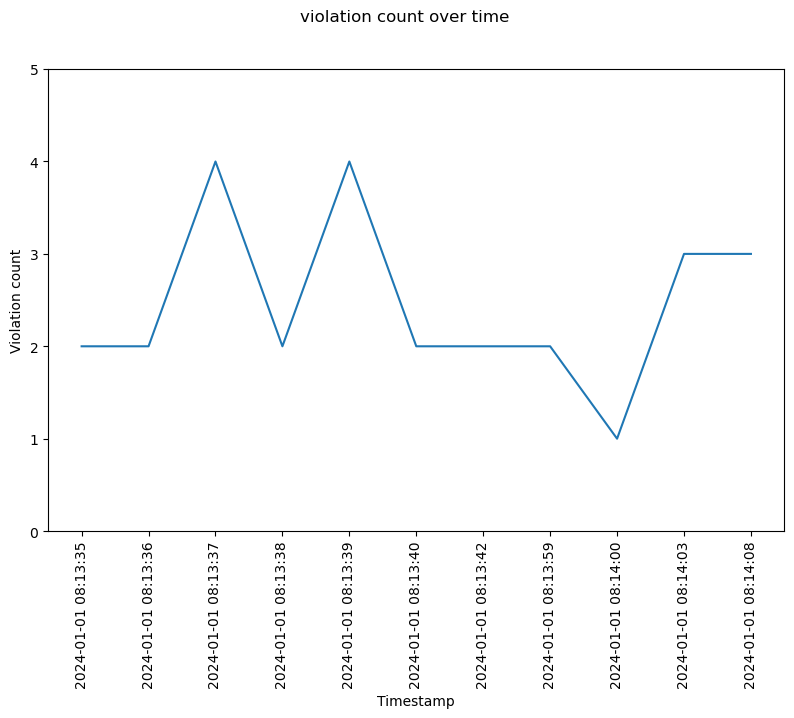

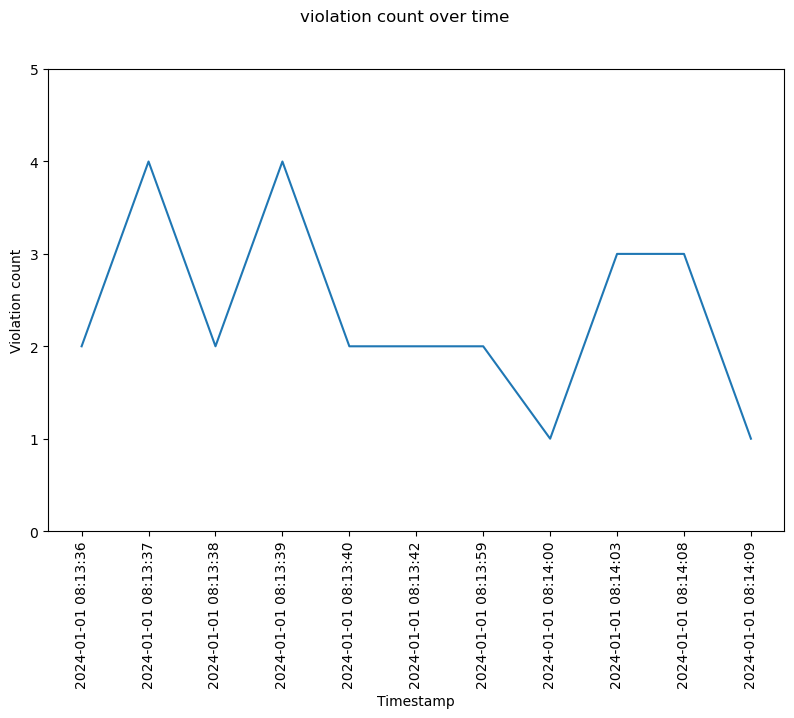

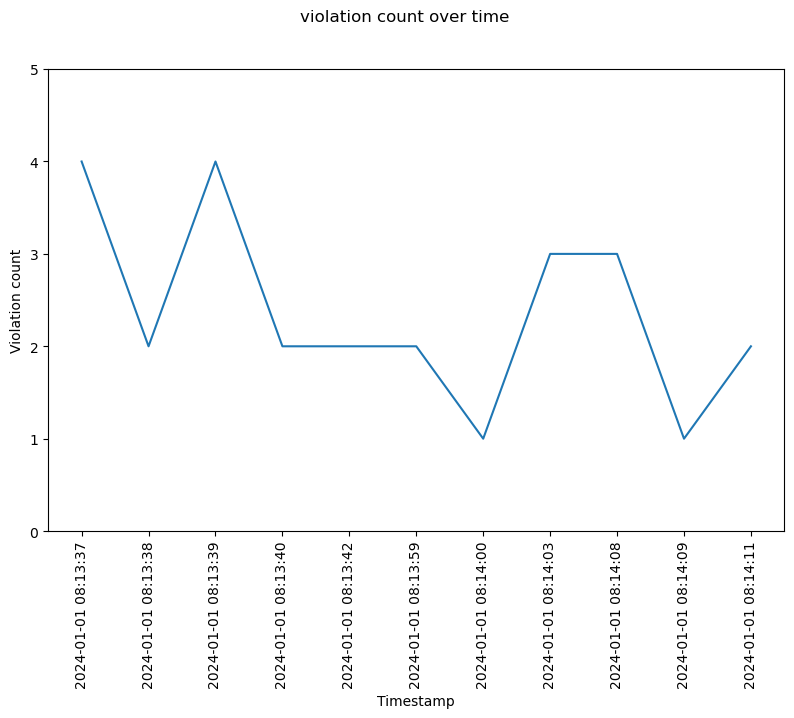

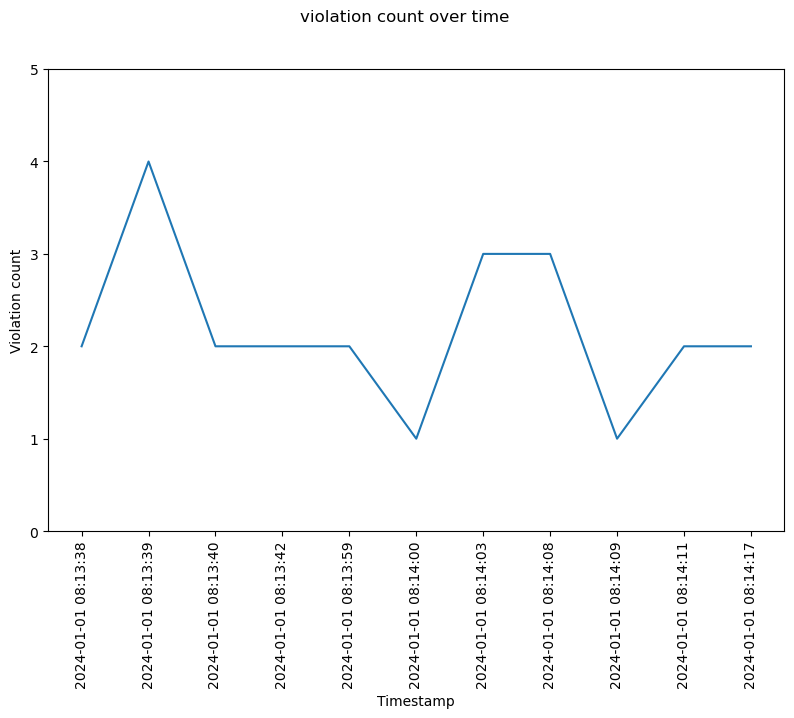

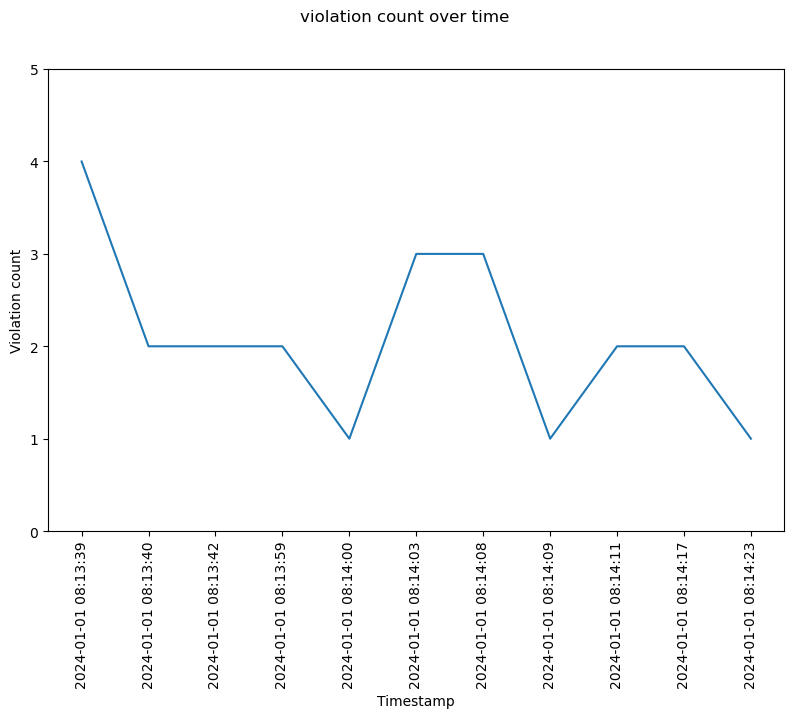

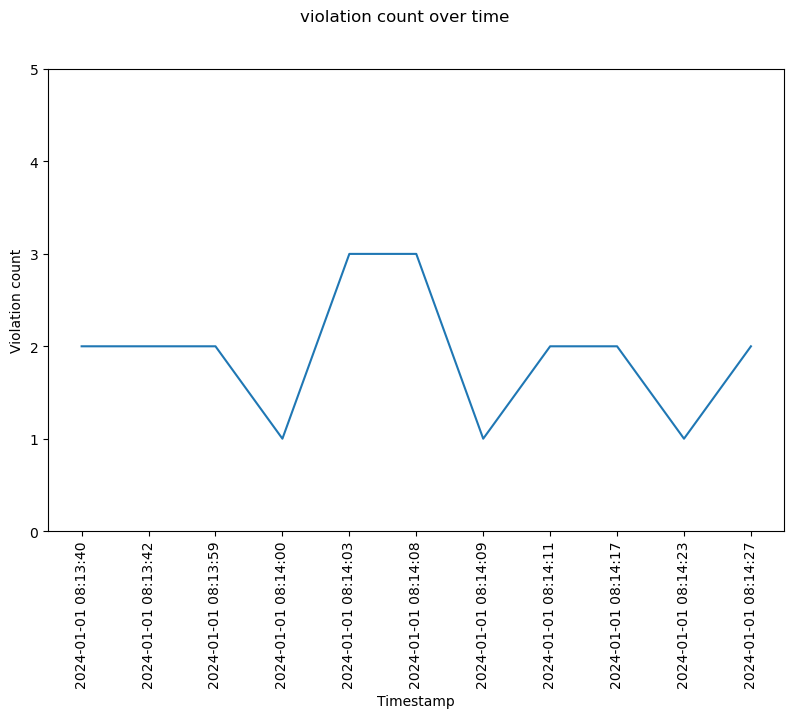

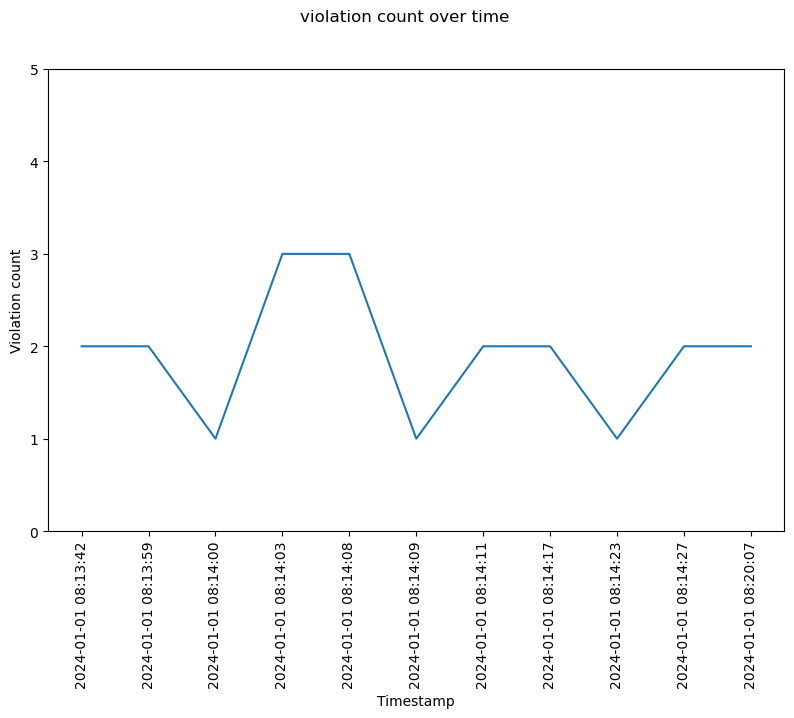

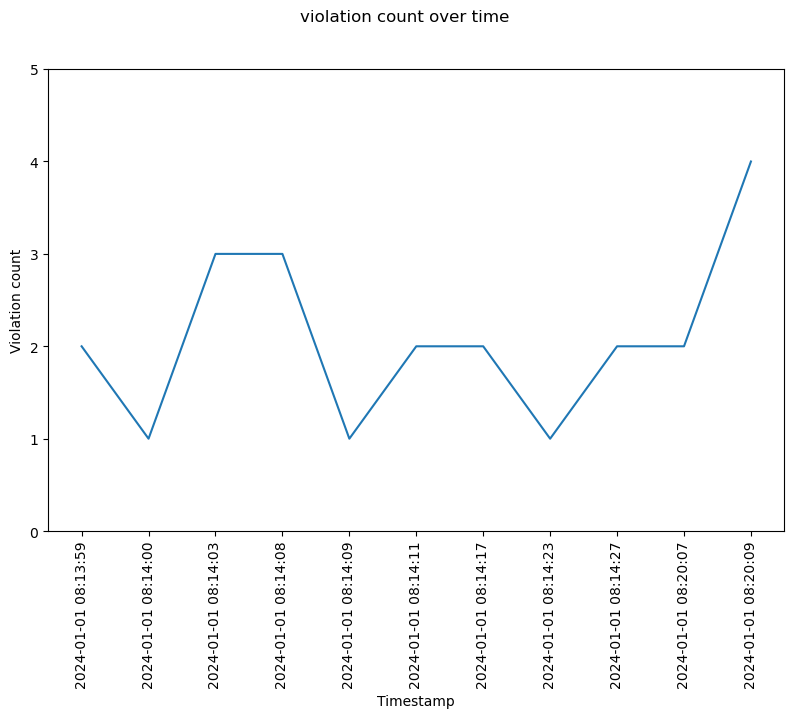

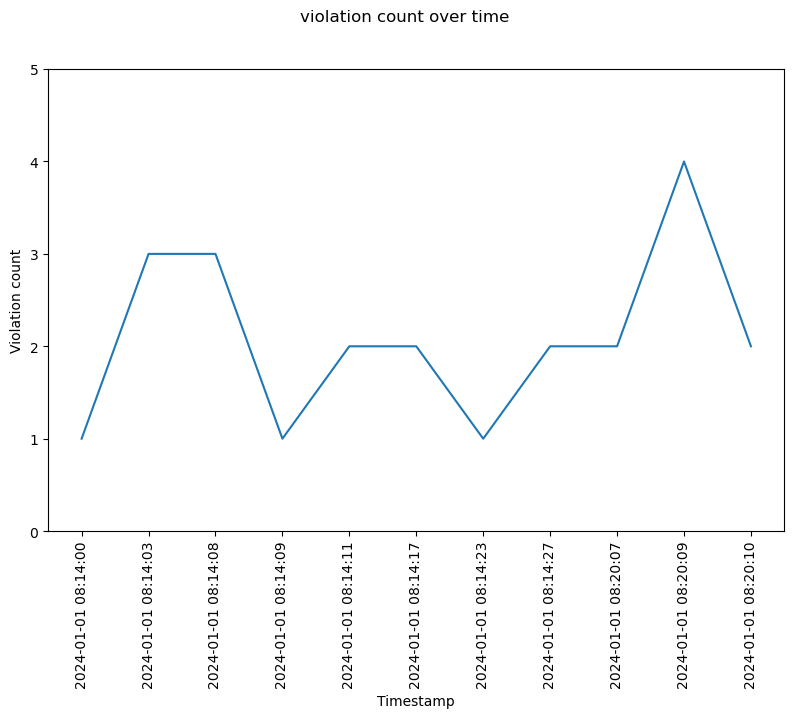

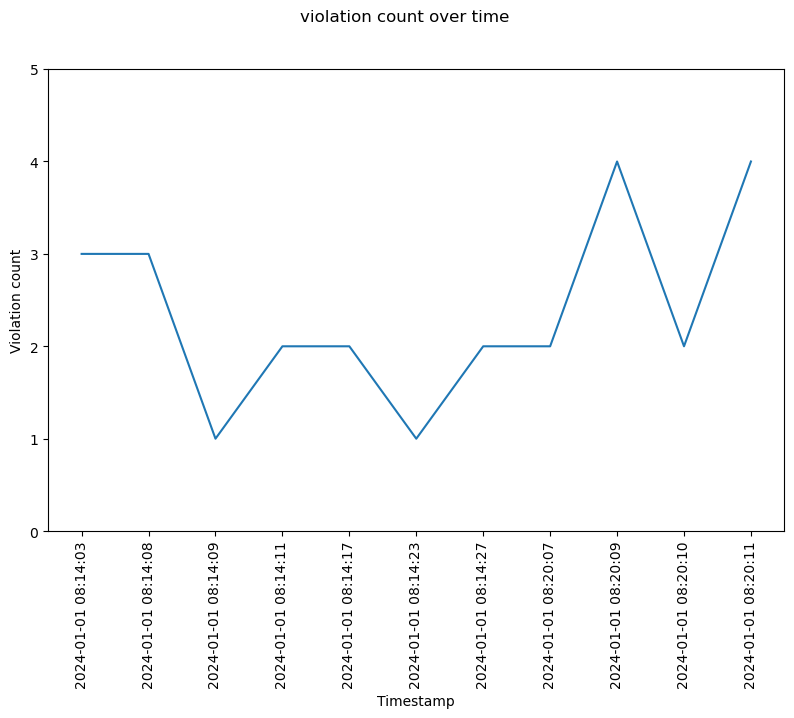

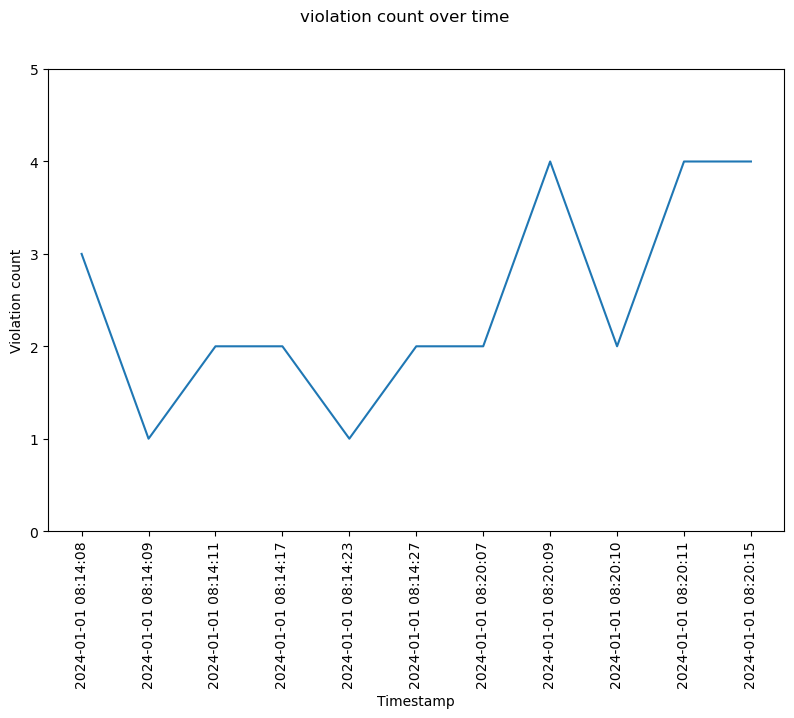

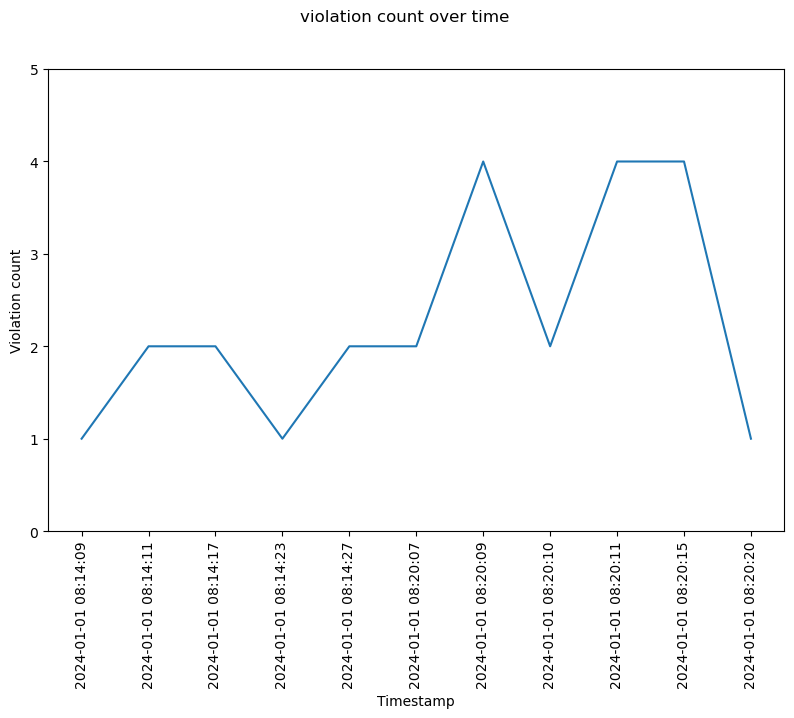

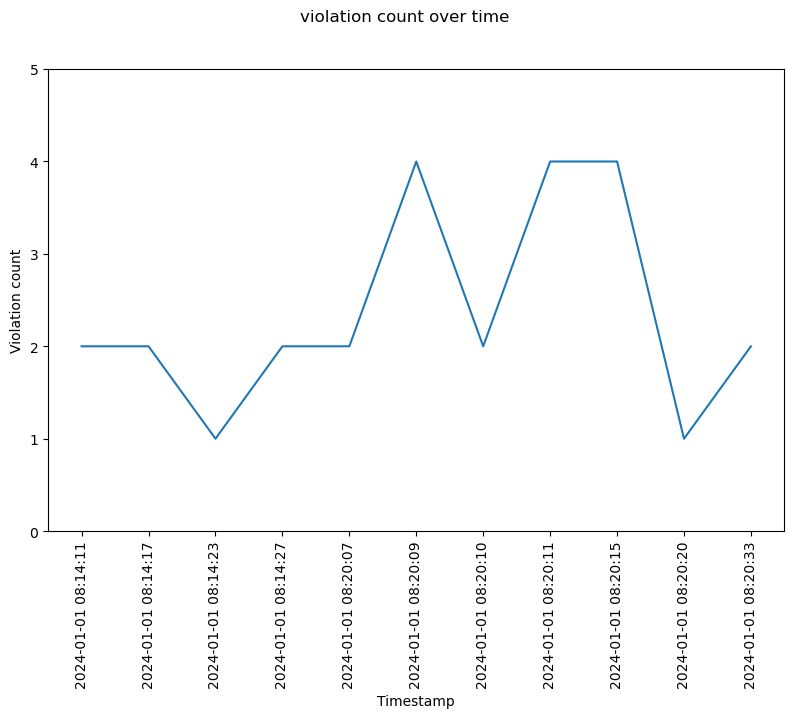

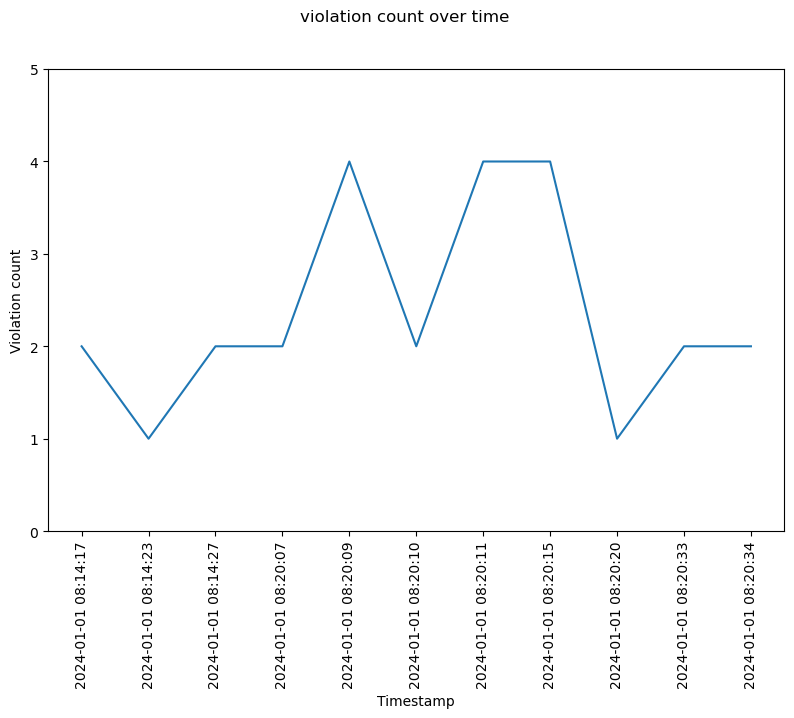

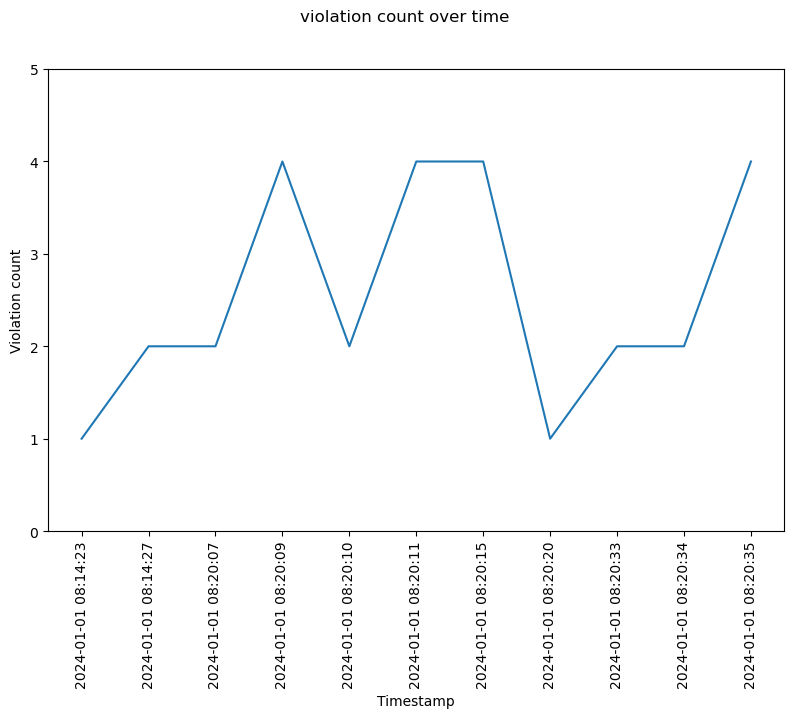

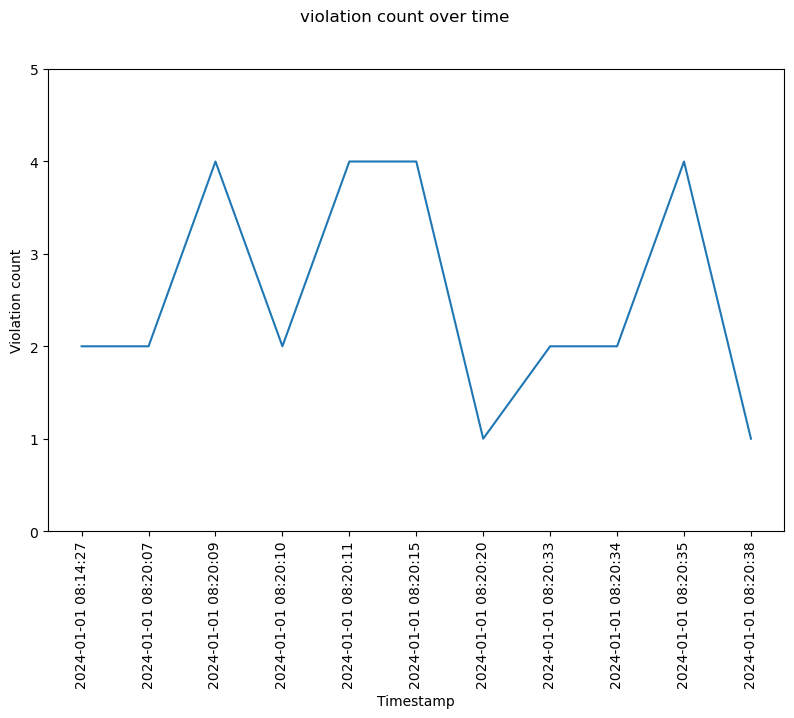

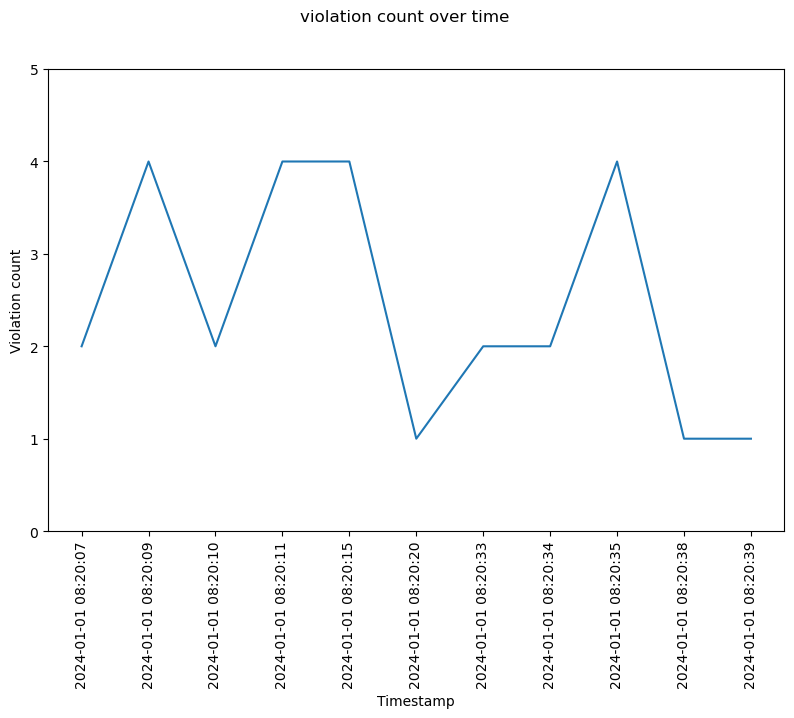

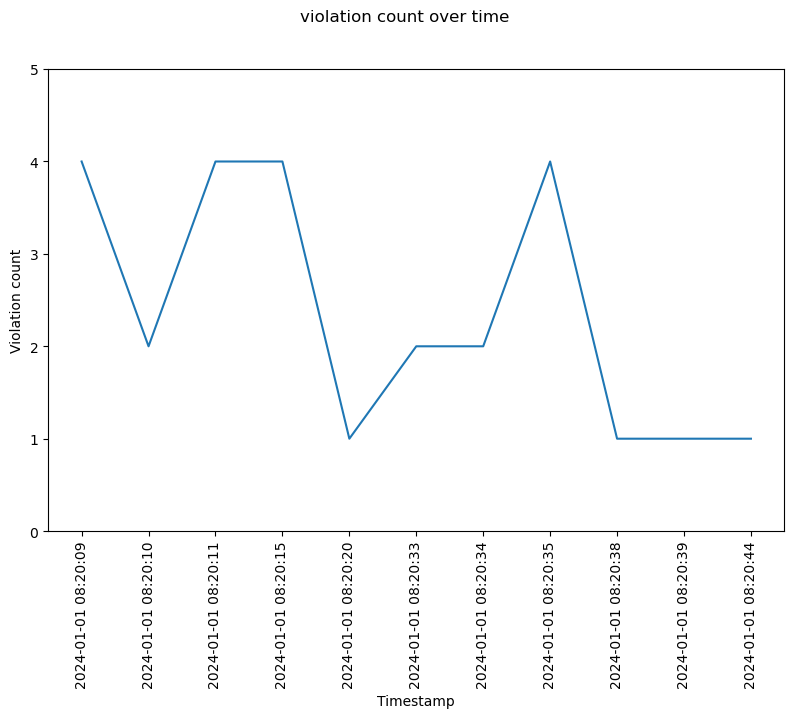

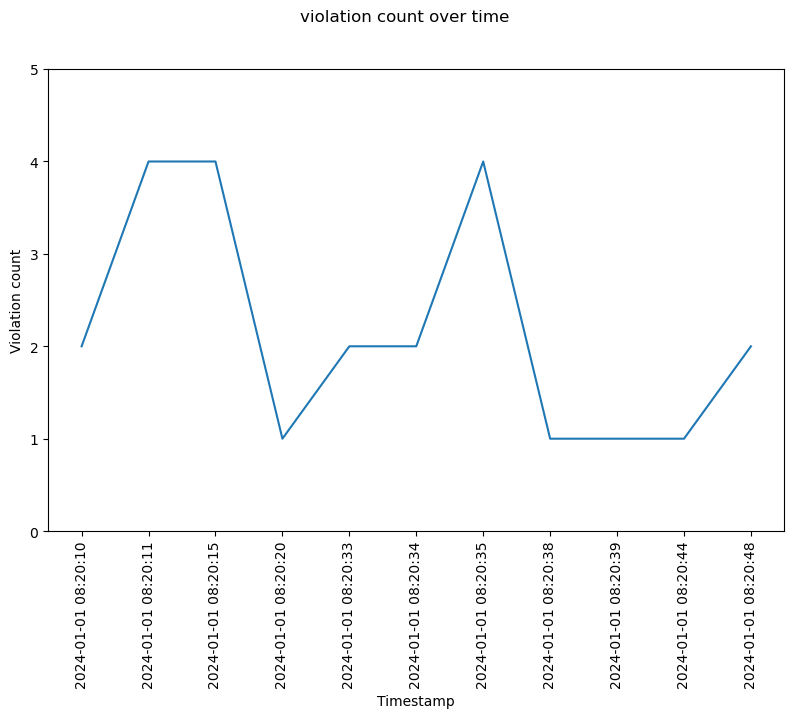

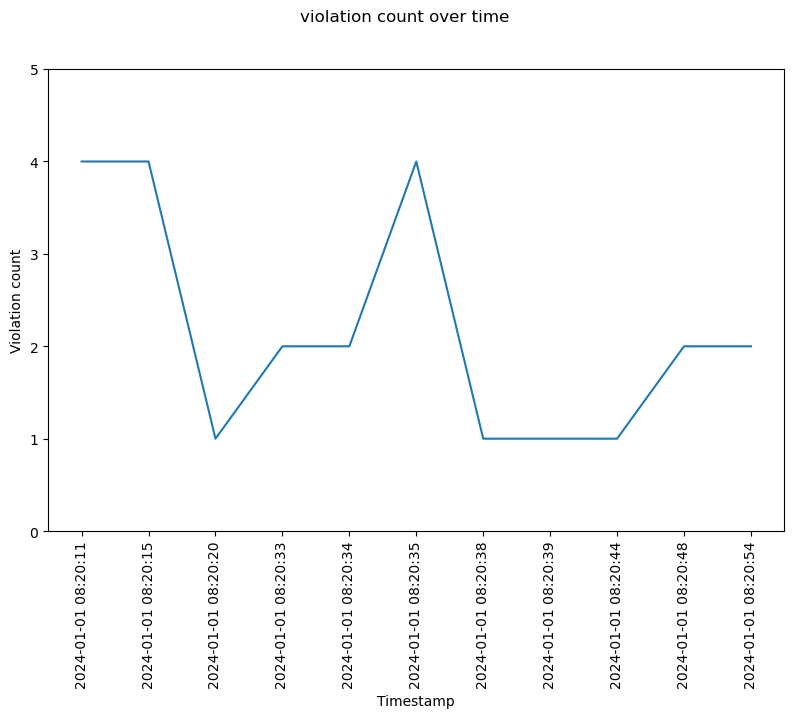

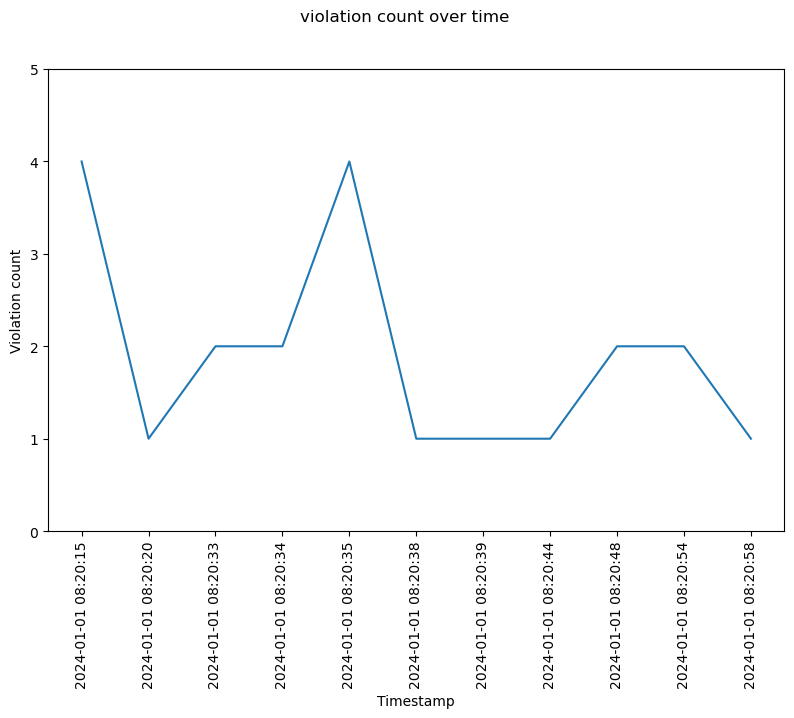

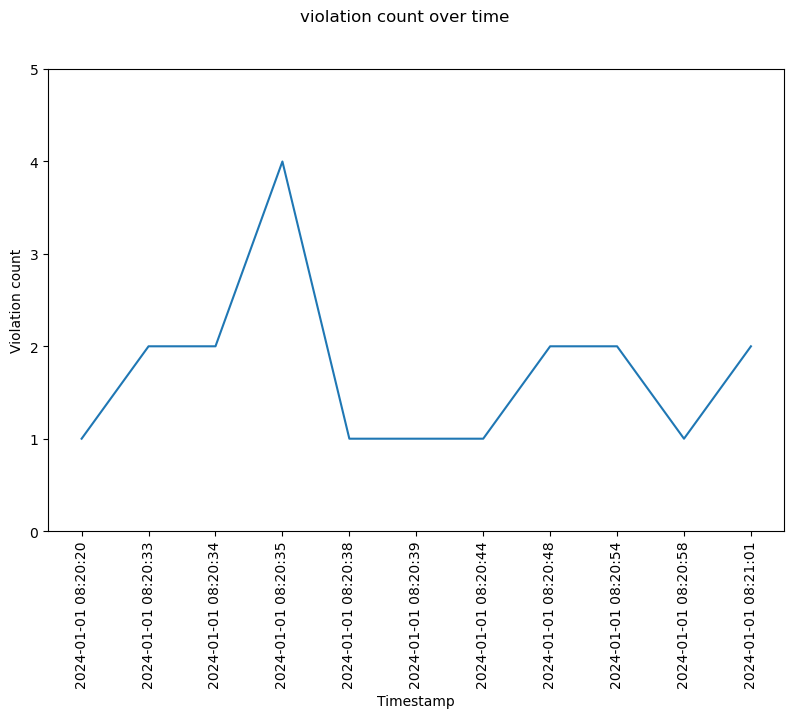

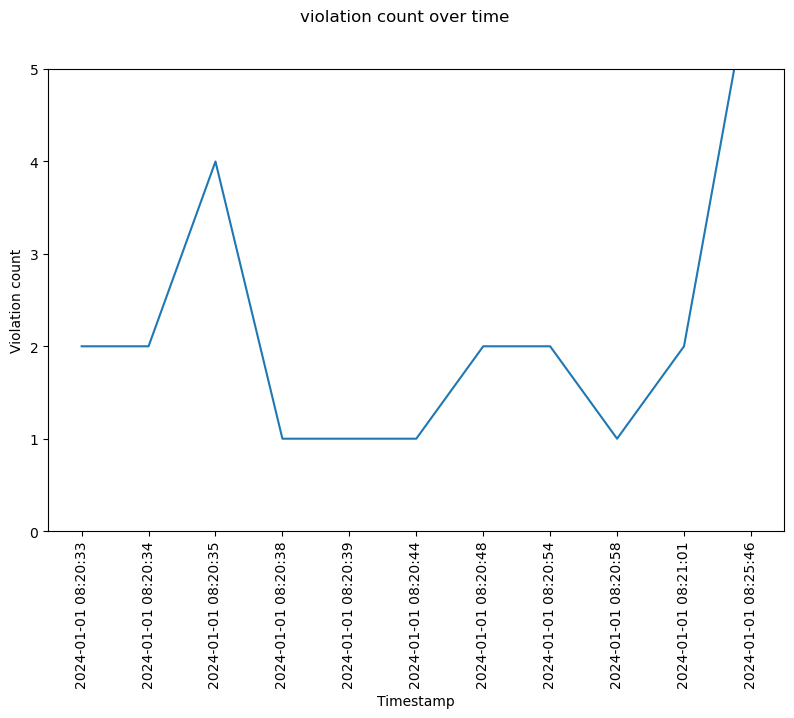

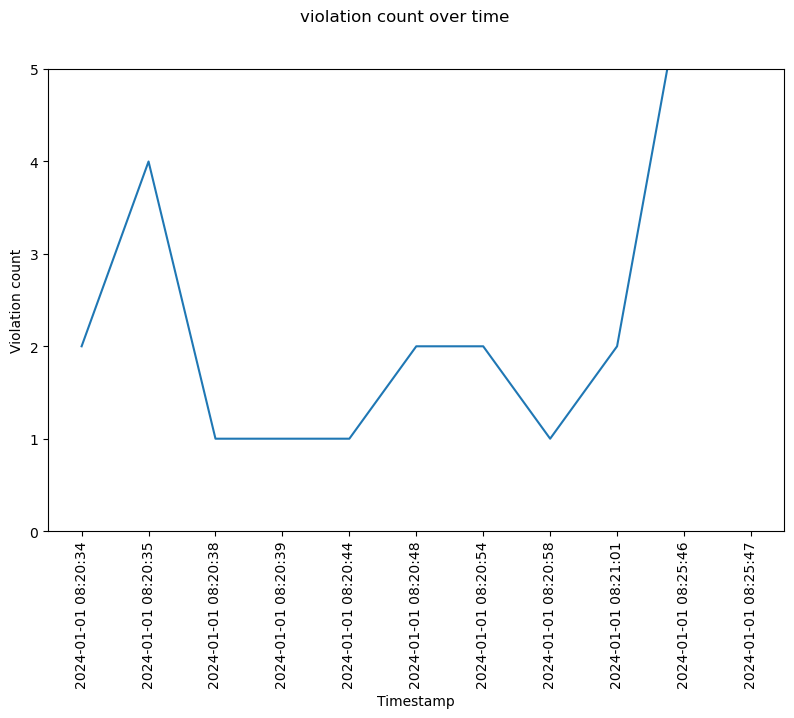

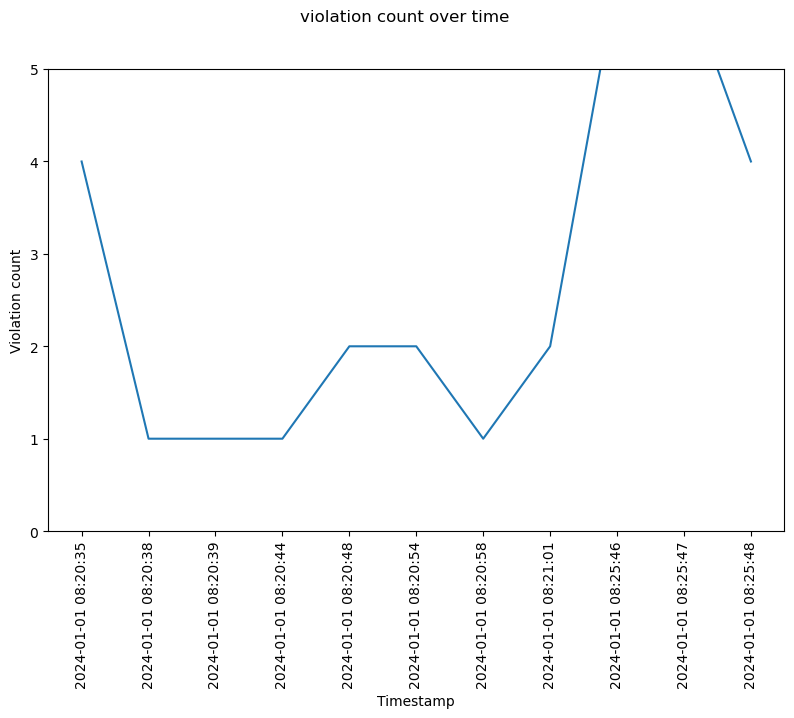

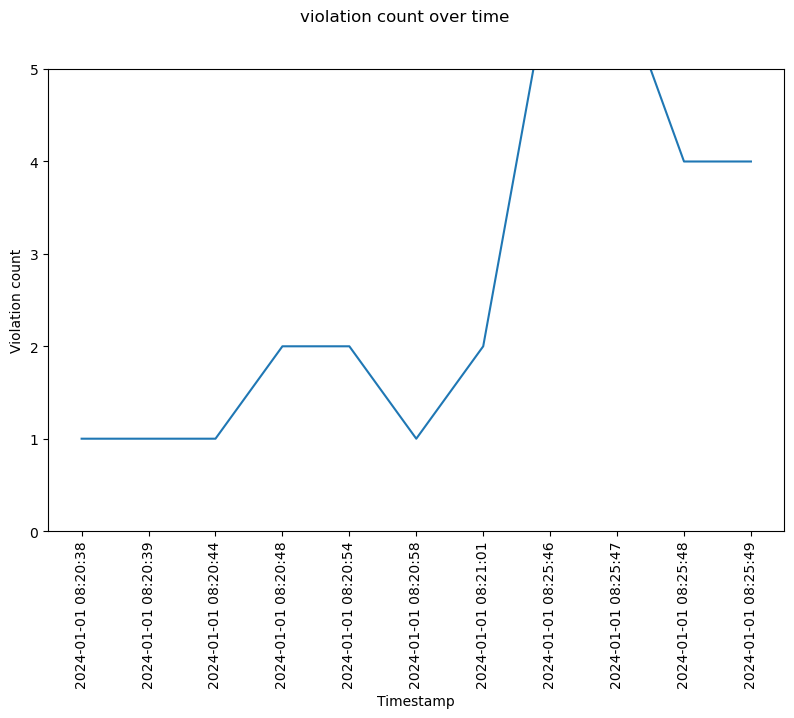

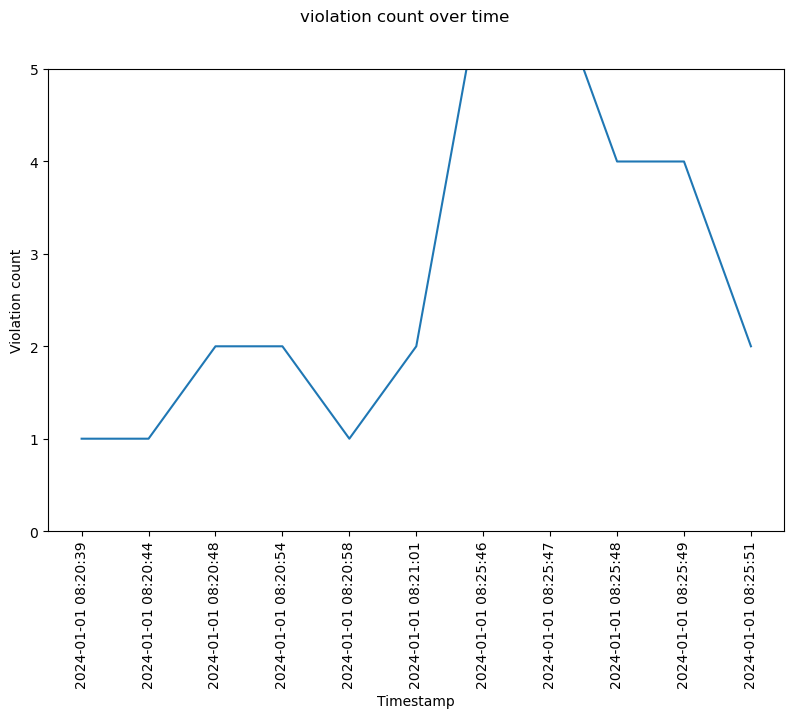

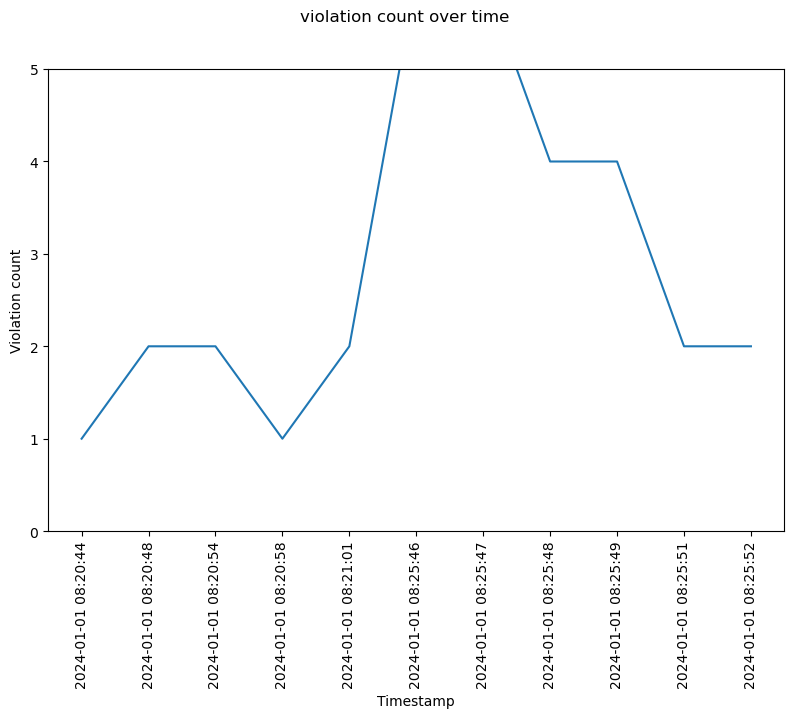

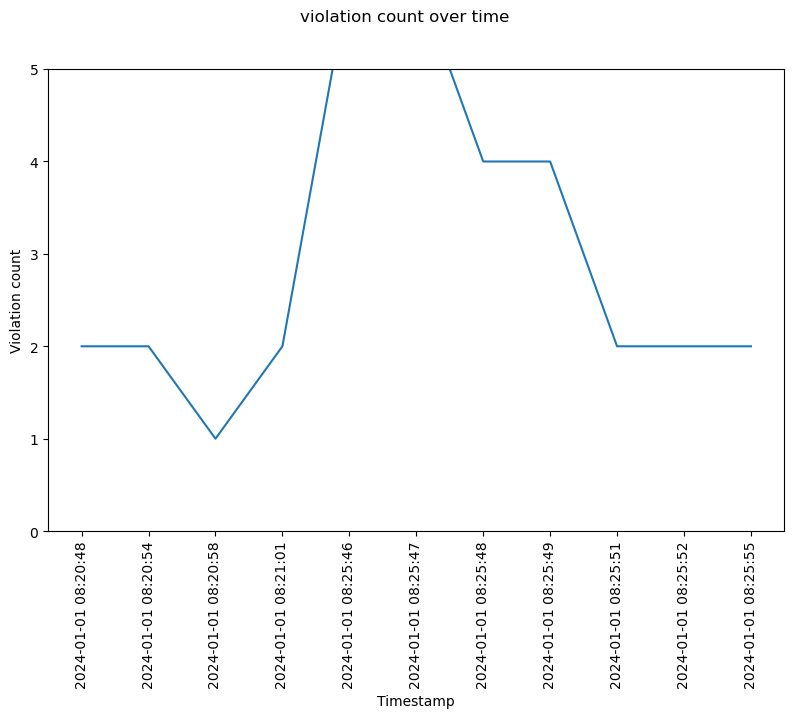

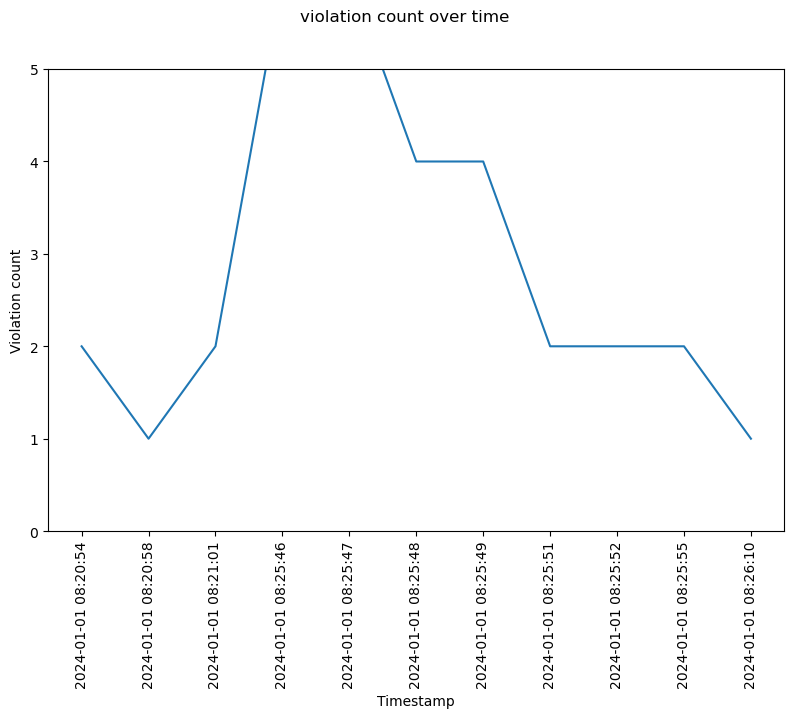

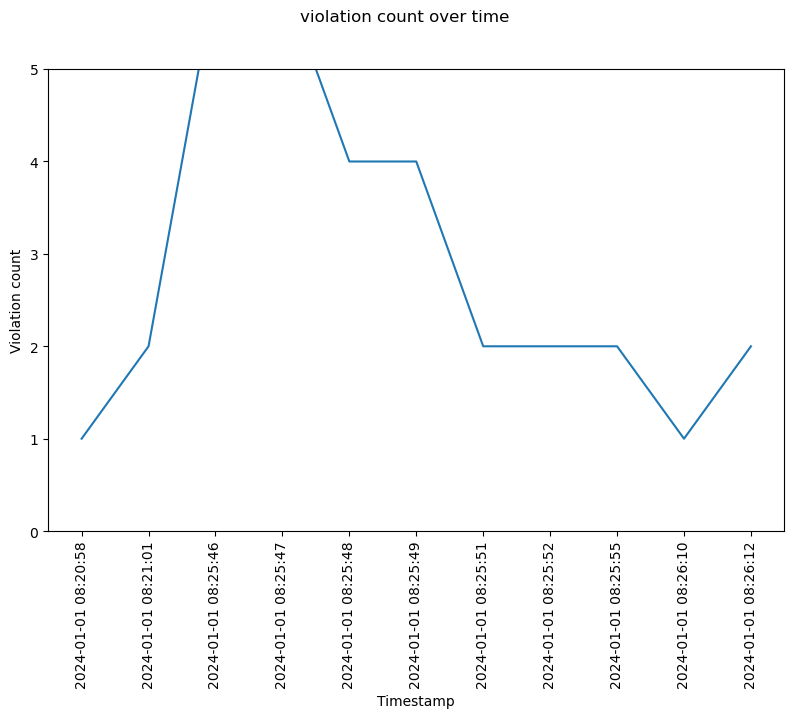

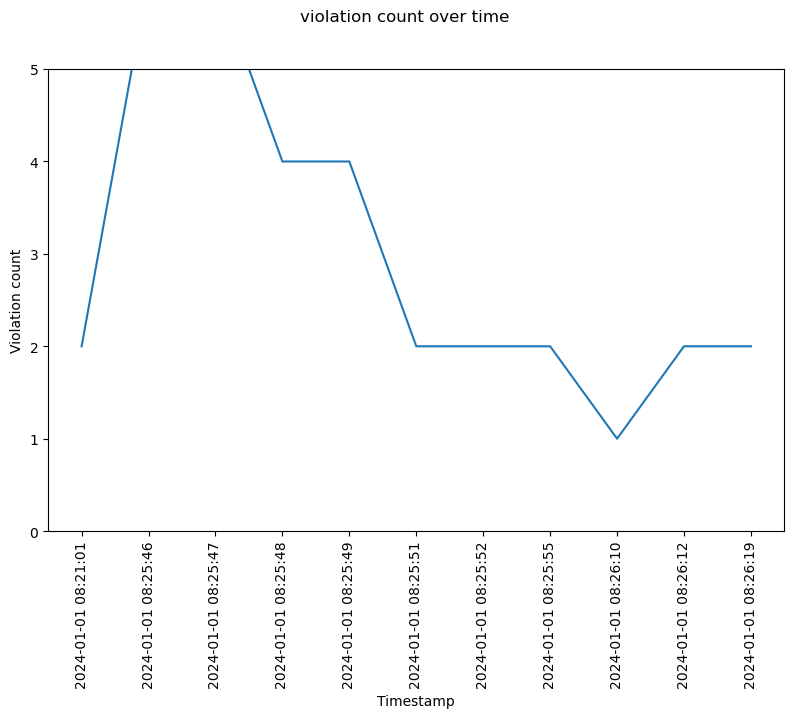

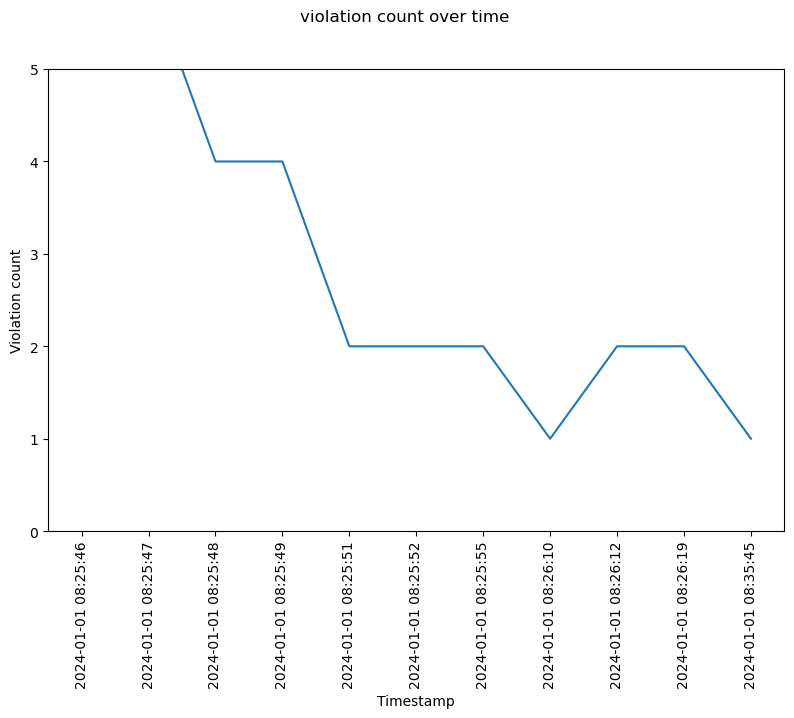

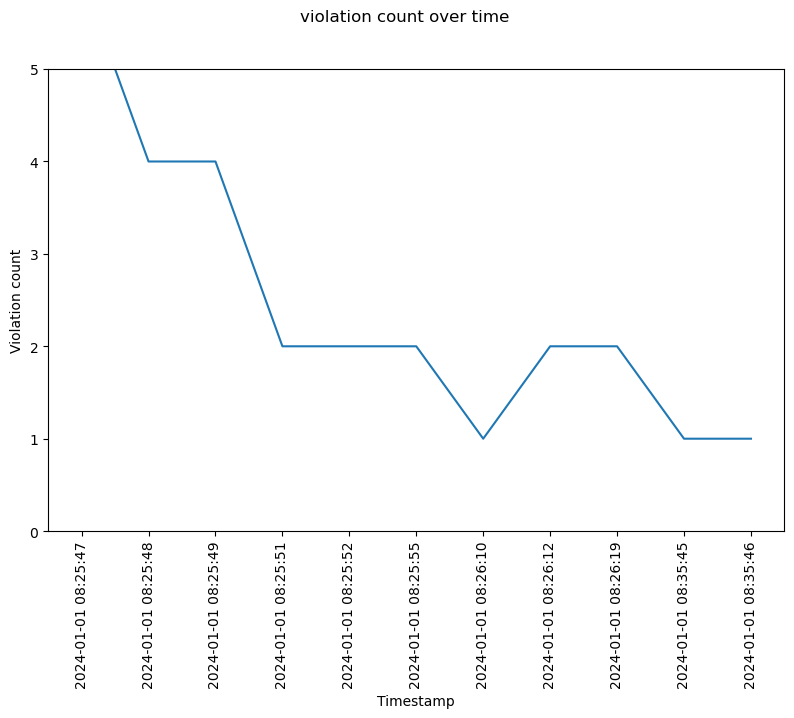

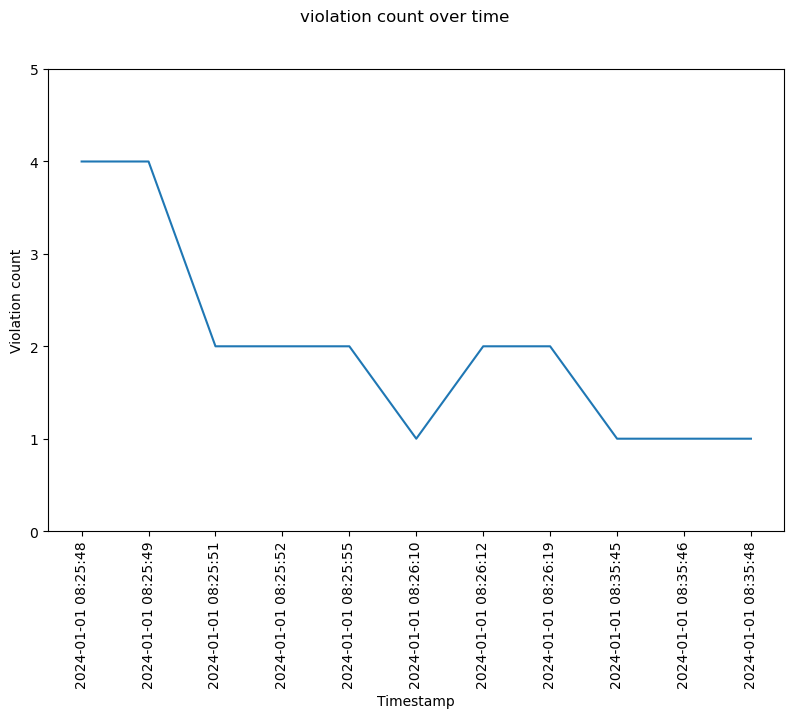

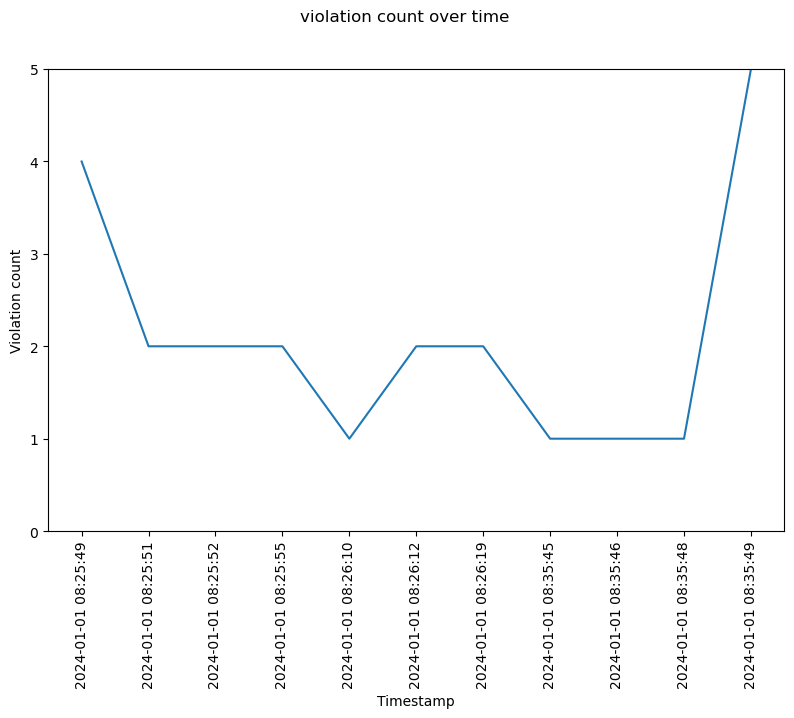

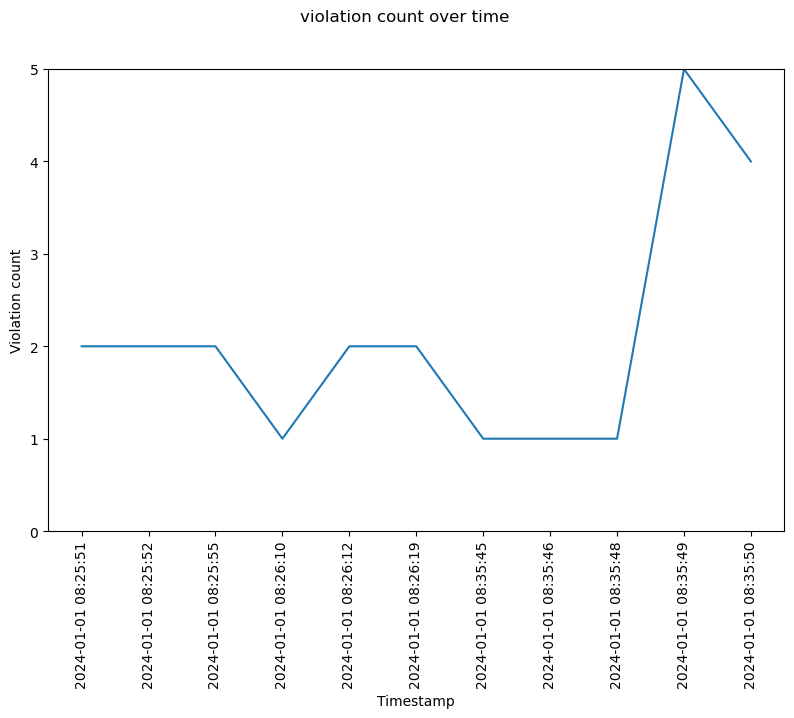

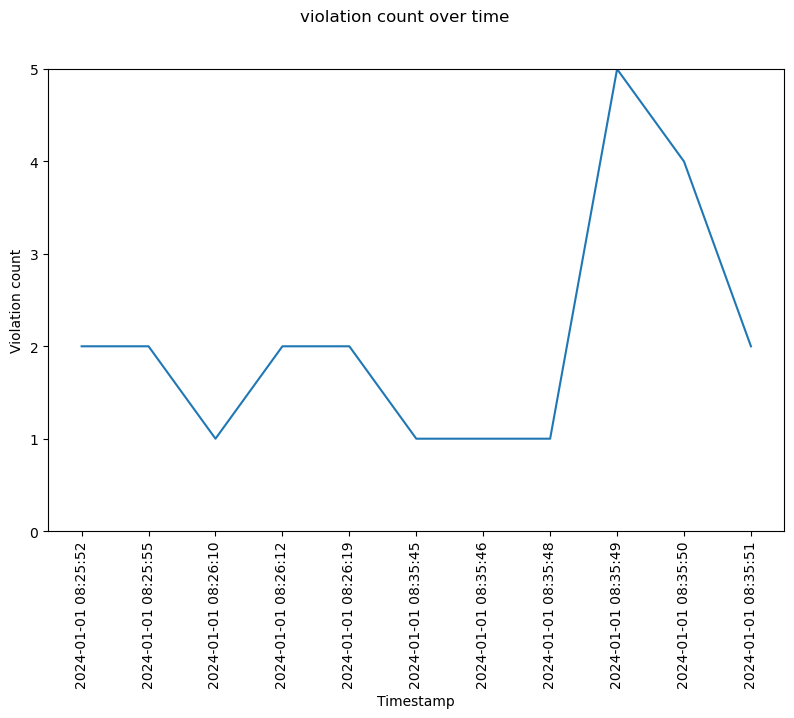

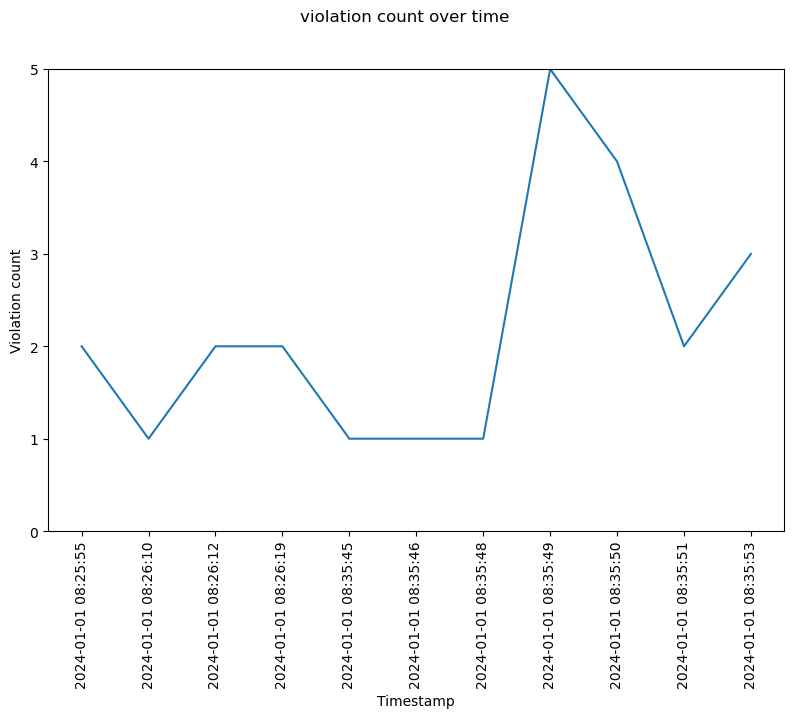

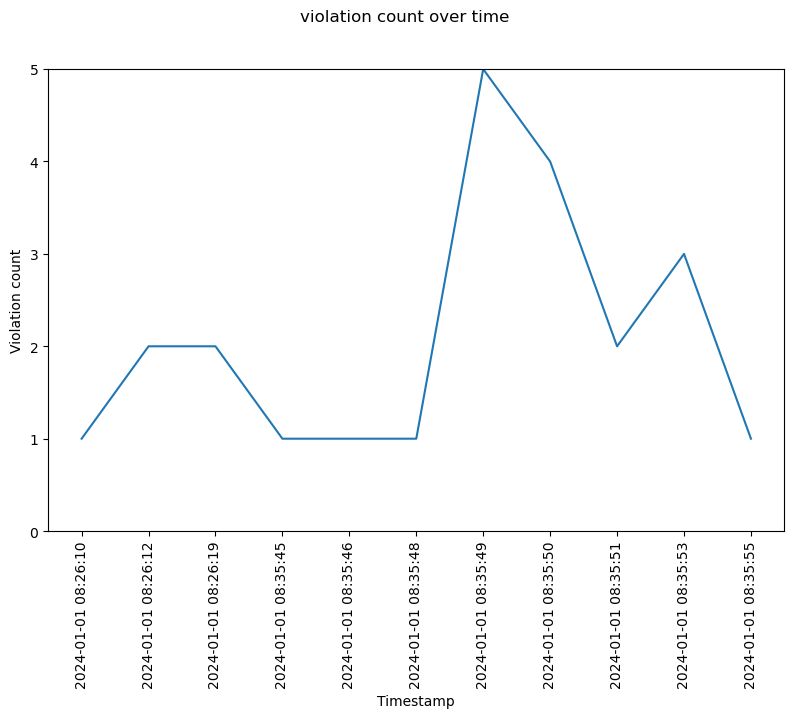

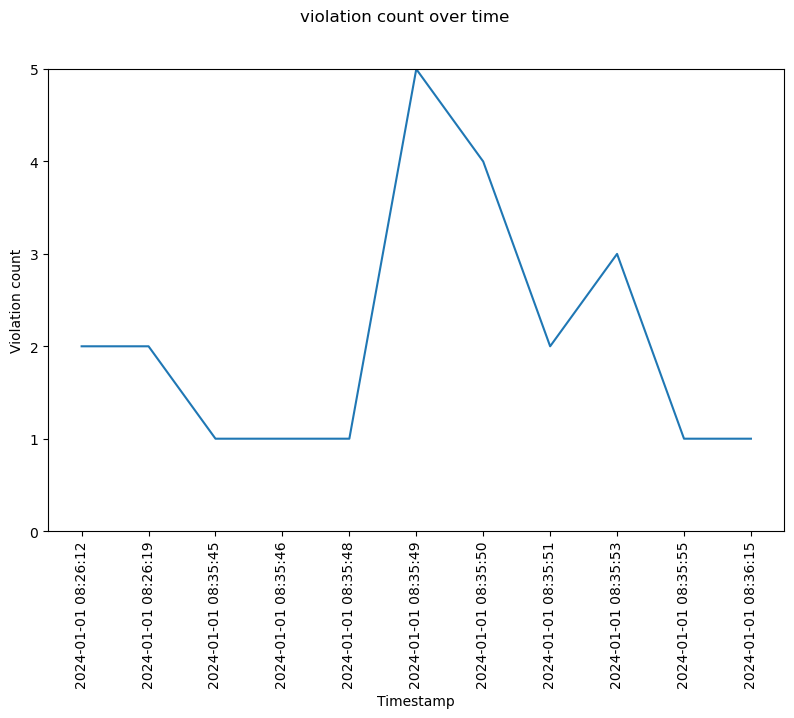

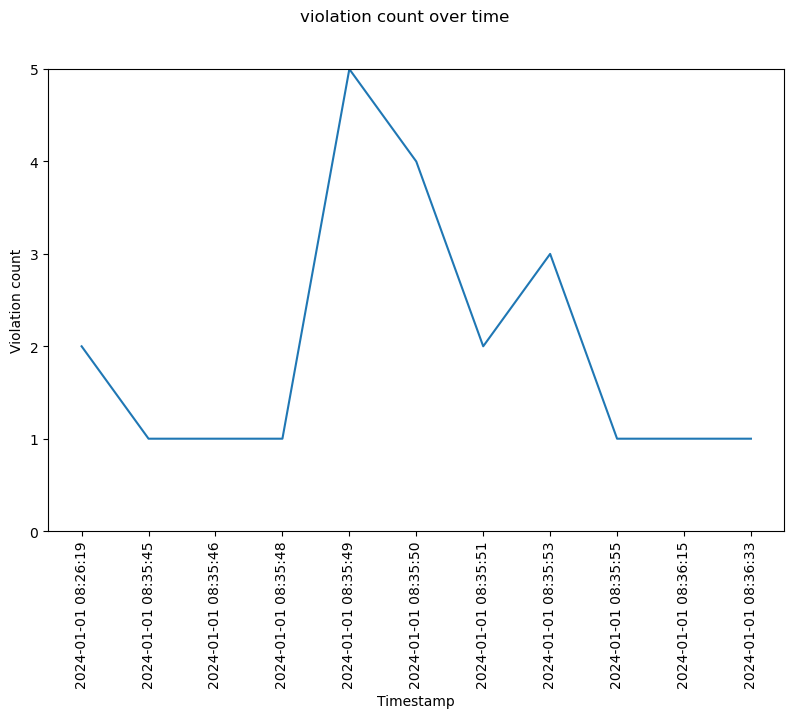

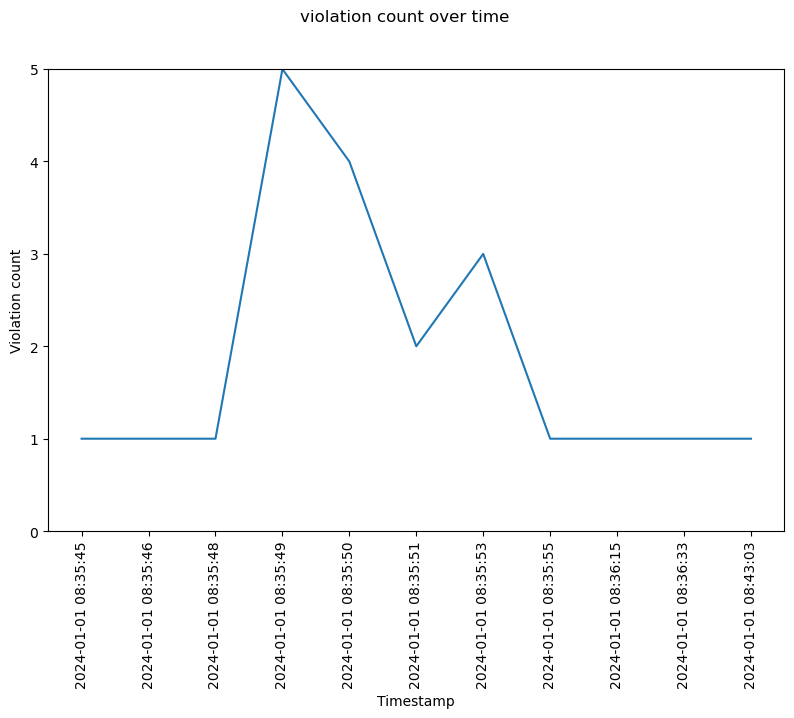

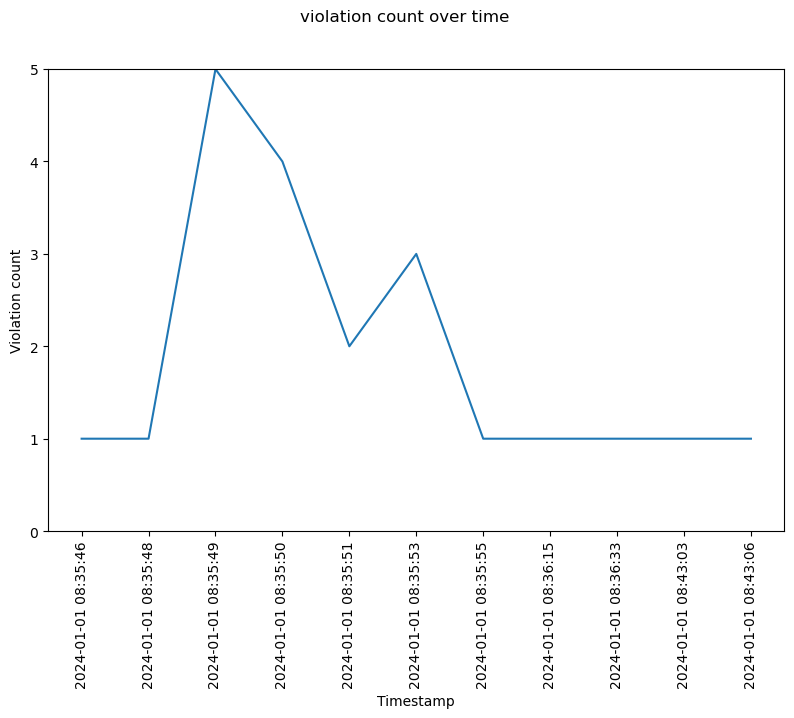

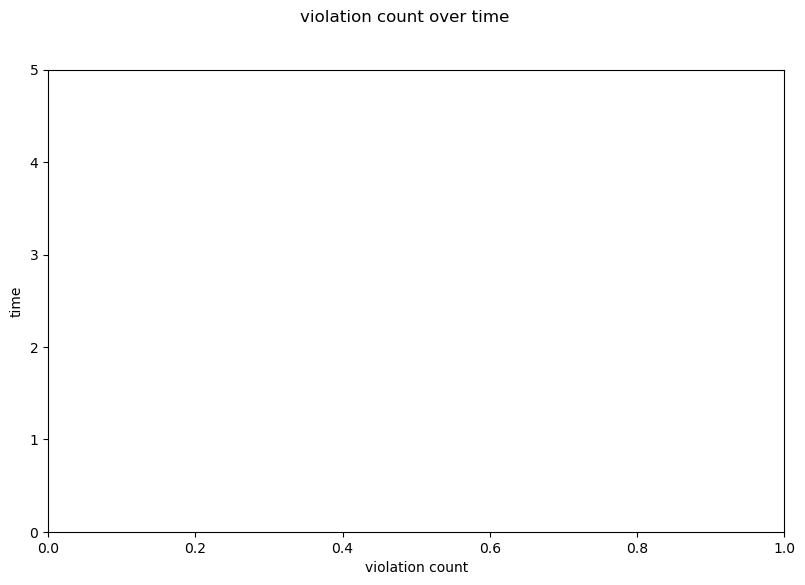

In [2]:
# Preparing the data for plotting
violations_list = list(violations.aggregate([{"$unwind":"$violations_today"},
                                             {"$group":{"_id":{"$dateToString":{"format":"%Y-%m-%d %H:%M:%S", "date":"$violations_today.timestamp_end"}}, "count":{"$sum":1}}},
                                             {"$sort":{"_id":1}}]))

#derived from week 9 kafka consumer code
def init_plots():
    try:
        width = 9.5
        height = 6
        fig = plt.figure(figsize=(width,height)) # create new figure
        ax = fig.add_subplot(111) # adding the subplot axes to the given grid position
        fig.suptitle('violation count over time') # giving figure a title
        ax.set_xlabel('violation count')
        ax.set_ylabel('time')
        ax.set_ylim(0,5)
        ax.set_yticks([0,1,2,3,4,5])
        #fig.show() # displaying the figure
        fig.canvas.draw() # drawing on the canvas
        return fig, ax
    except Exception as ex:
        print(str(ex))

def annotate_max(x, y, ax = None):
    ymax = max(y)
    xpos = y.index(ymax)
    xmax = x[xpos]
    text = 'Max: Time={}, Value={}'.format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    ax.annotate(text, xy=(xmax, ymax), xytext=(xmax, ymax+5), arrowprops=dict(facecolor='red', shrink=0.05),)
    
def annotate_min(x, y, ax = None):
    ymin = min(y)
    xpos = y.index(ymin)
    xmin = x[xpos]
    text = 'Min: Time={}, Value={}'.format(xmin, ymin)
    if not ax:
        ax=plt.gca()
    ax.annotate(text, xy=(xmin, ymin), xytext=(xmin, ymin+5), arrowprops=dict(facecolor='orange', shrink=0.05),)
    
def process_violations_count_by_time(violations, fig, ax):
    try:
        # container for x and y values
        x, y = [], []
        # print('Waiting for messages')
        
        for violation in violations:
            y.append(int(violation["count"]))
            x.append(violation["_id"])
            
            # we start plotting only when we have 10 data points
            if len(y) > 10:  
                ax.clear()
                ax.set_xlabel('Timestamp')
                ax.set_ylabel('Violation count')
                ax.set_ylim(0, 5)
                ax.set_yticks([0,1,2,3,4,5])
                ax.plot(x, y)
                plt.xticks(rotation=90)
                fig.canvas.draw()
                plt.pause(0.01)#render the plots without maxing out memory
                x.pop(0)
                y.pop(0)
                fig,ax = init_plots() #initialize new plot so changes can be seen
    except Exception as ex:
        print(str(ex))
            
            
fig,ax = init_plots()
process_violations_count_by_time(violations_list, fig, ax)

This plots the violations count against time. It starts by aggregating the violations based on timestamp_end and finding the average of the speed reading for each timestamp_end. The data is then sorted by ascending order of timestamp_end and saved in violations_list

Then, using matplotlib, it plots the data from violations_list into individual plots, with the first plot showing the first 10 data and the subsequent plots showing the previous 9 and the next 1, simulating an updating chart. Max and min annotations are added and updated accordingly to show the maximum and minimum average speed of each speeding violation.

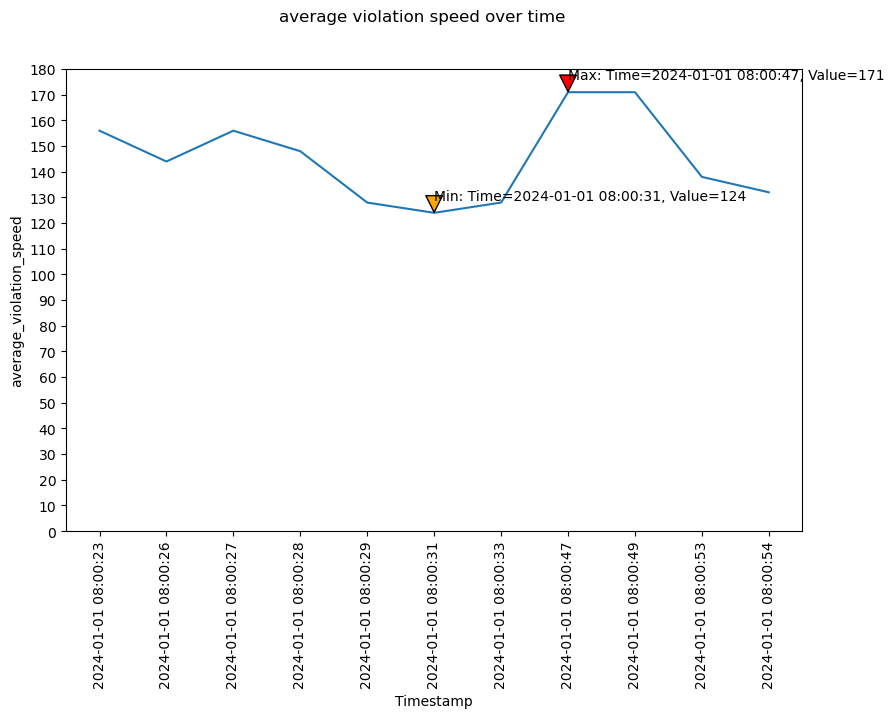

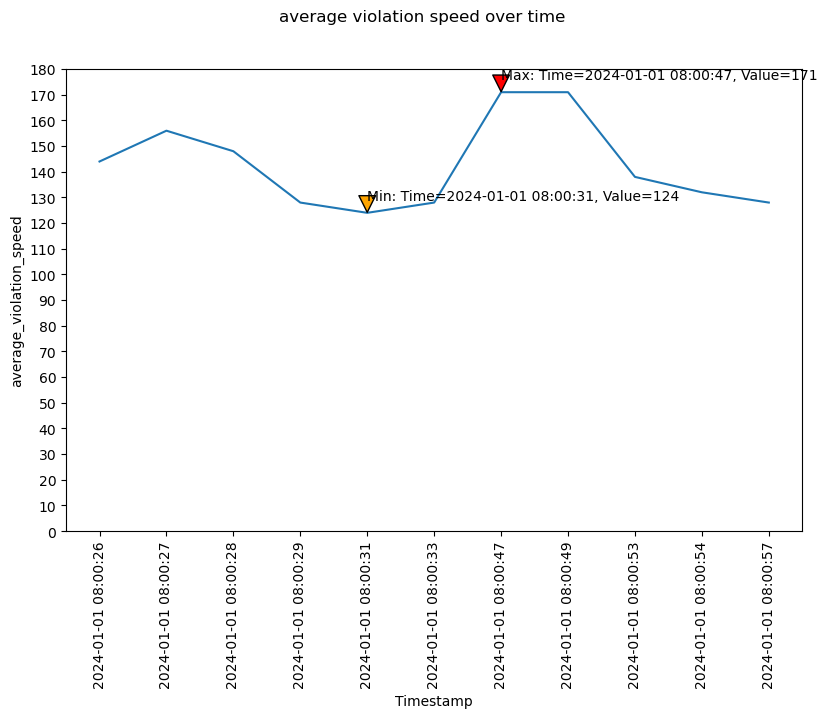

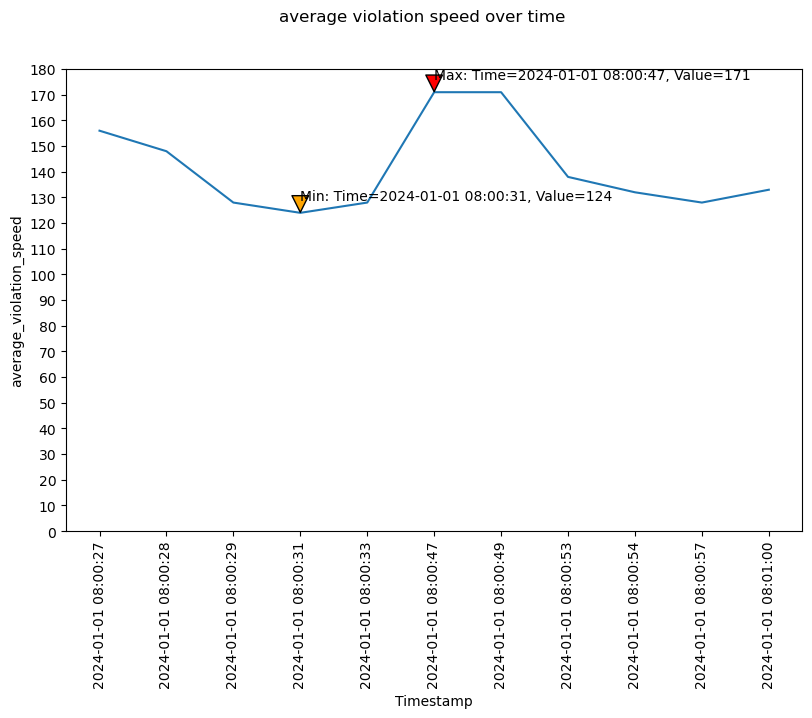

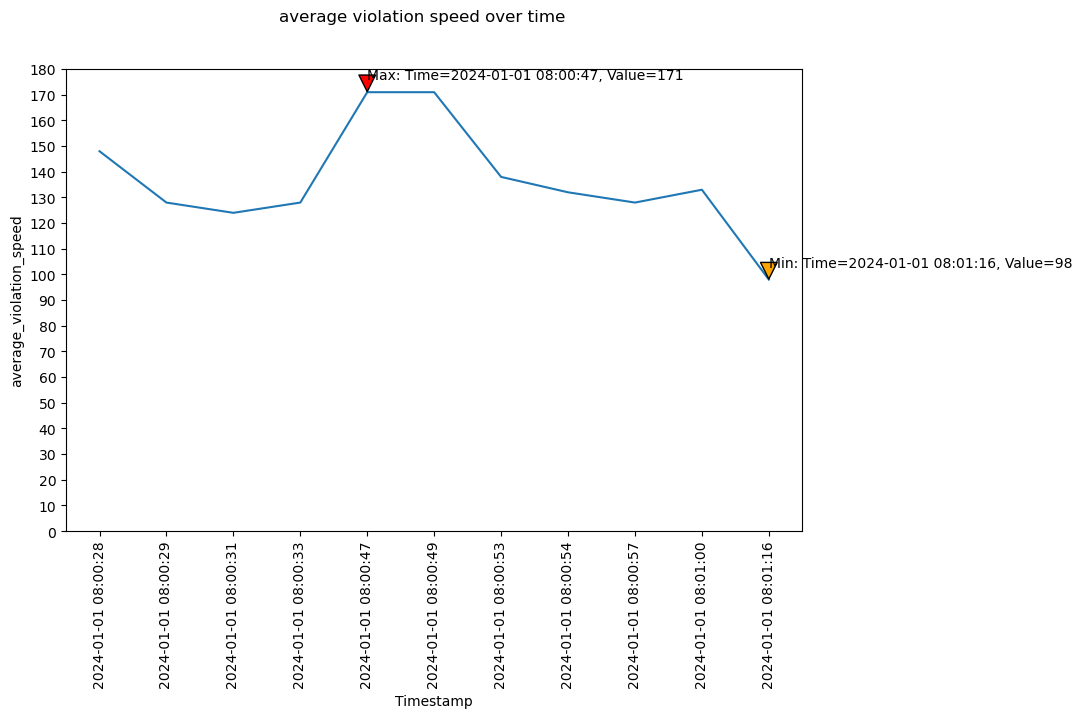

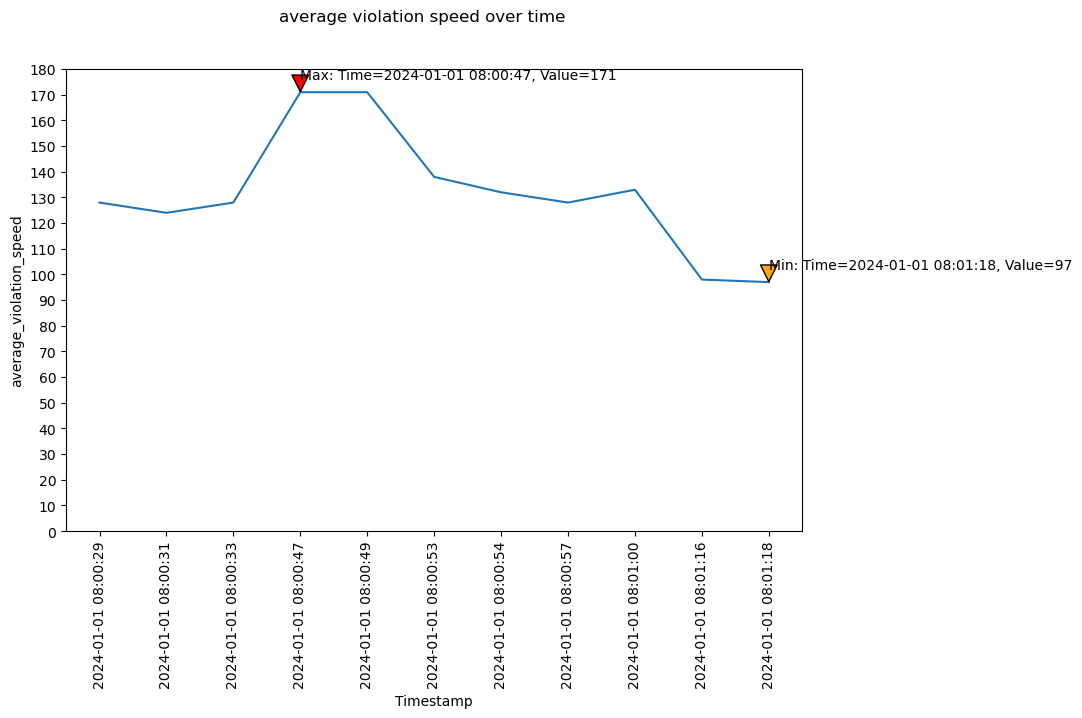

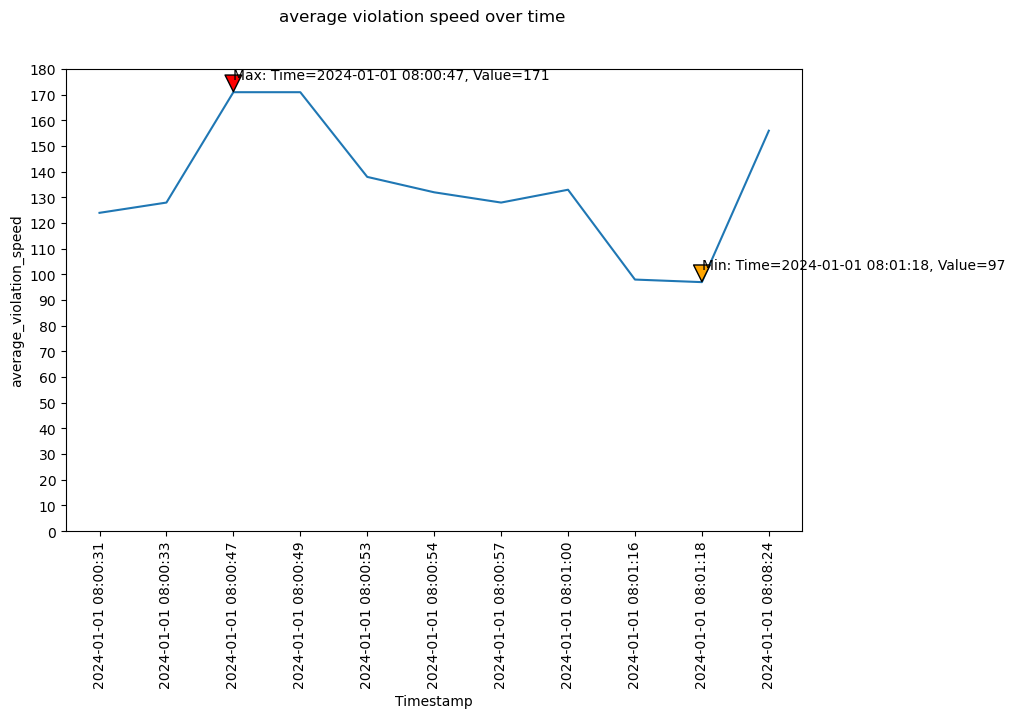

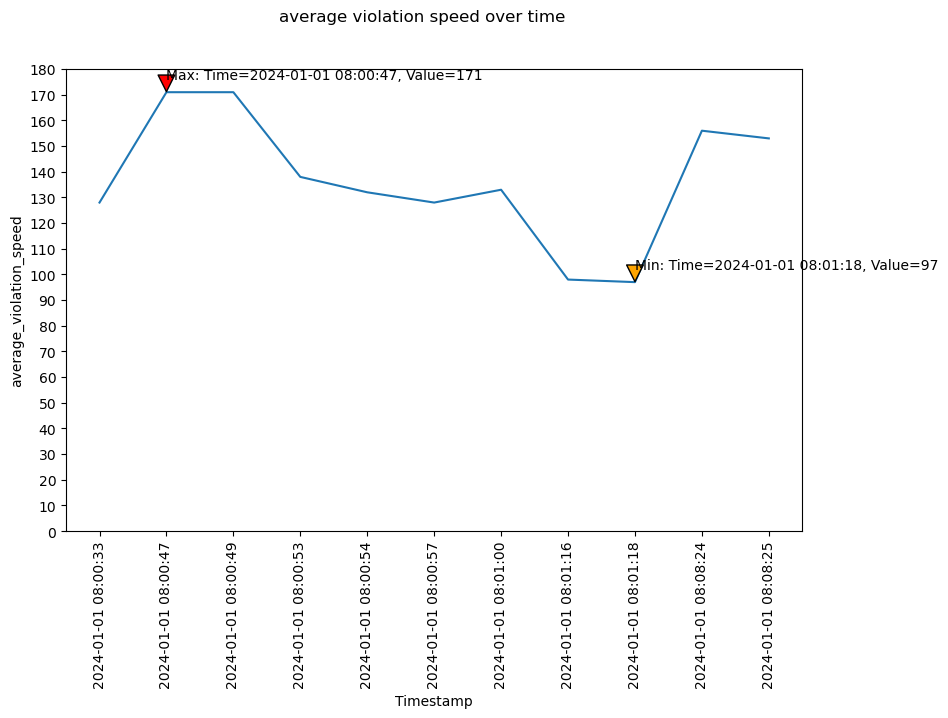

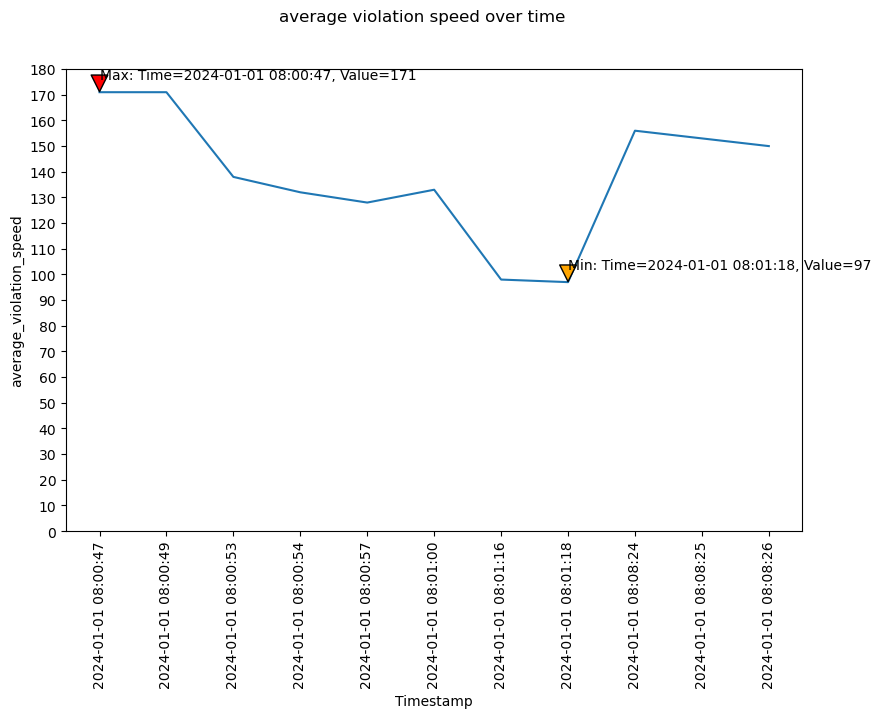

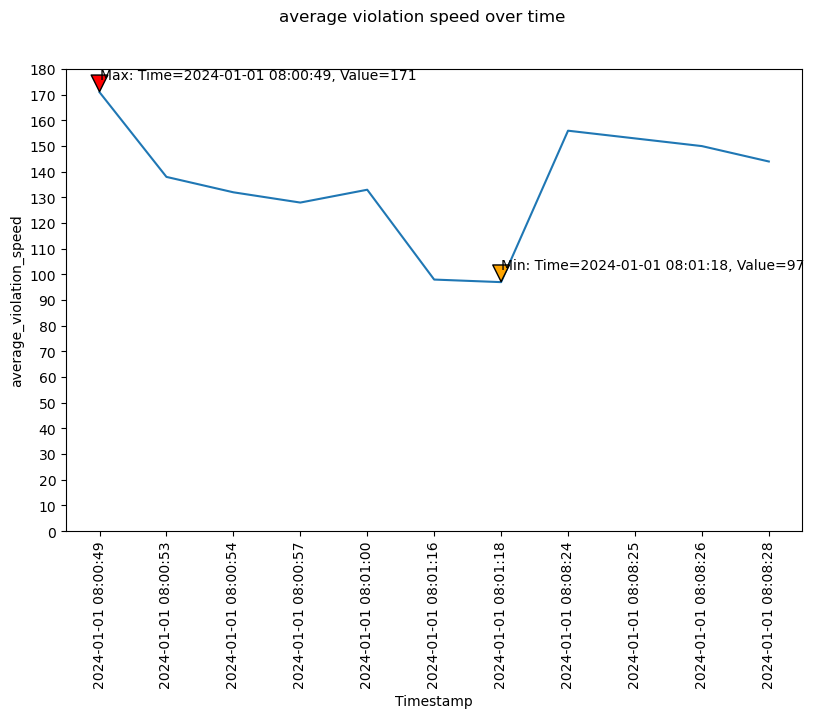

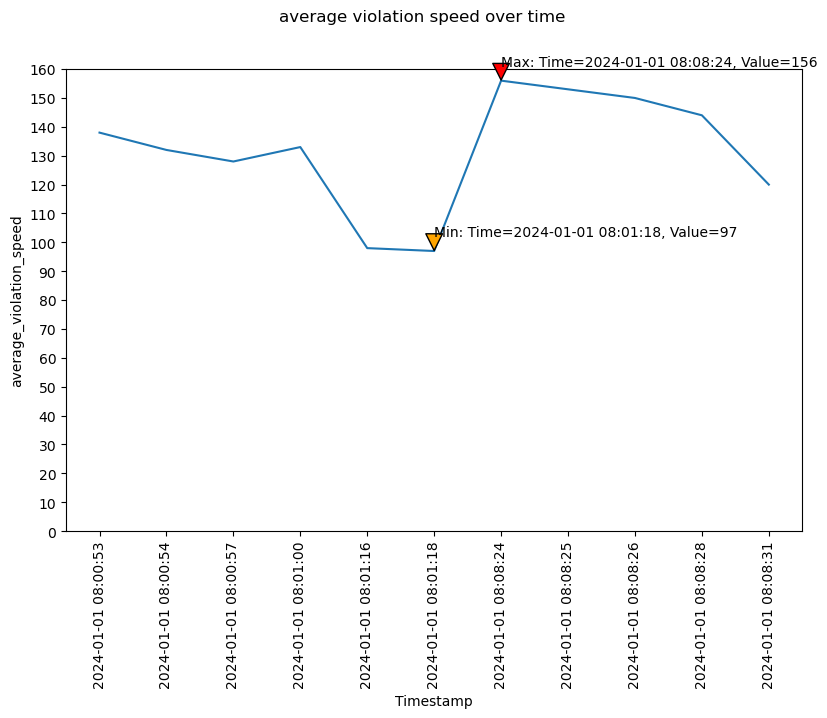

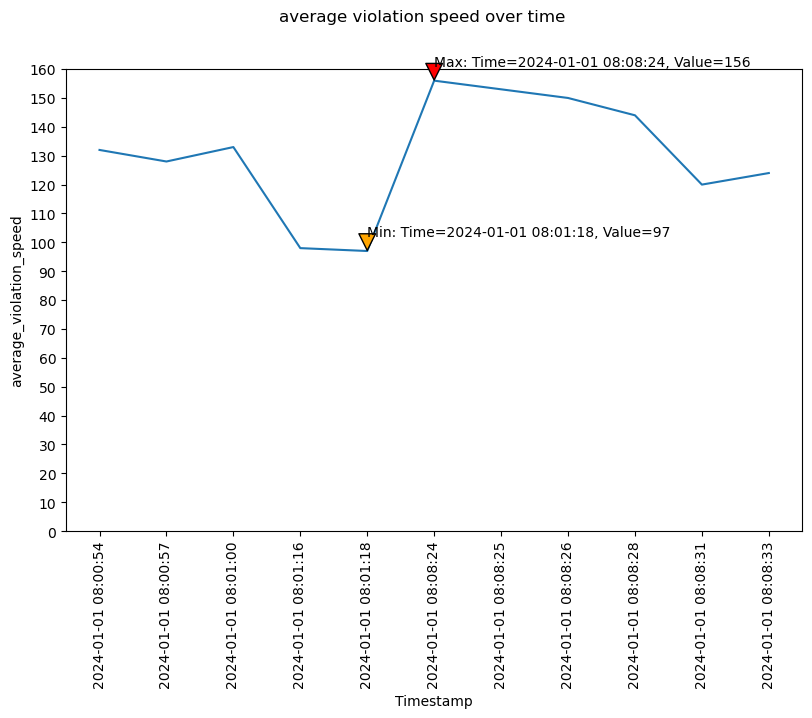

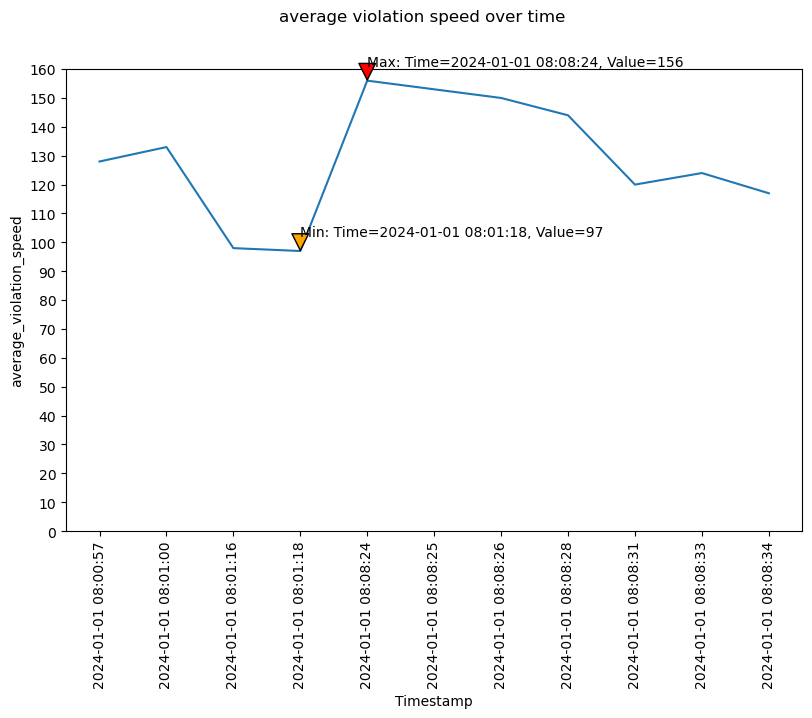

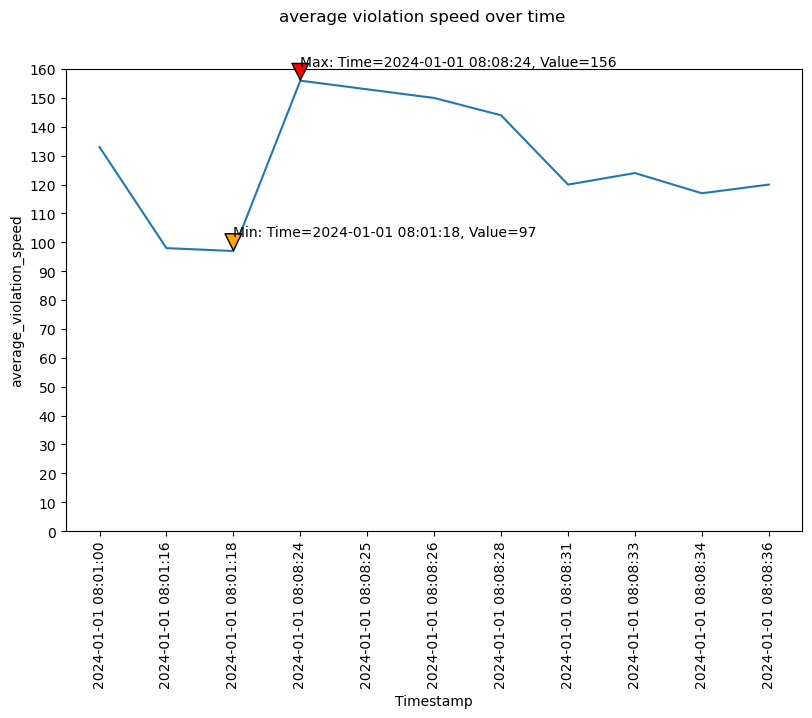

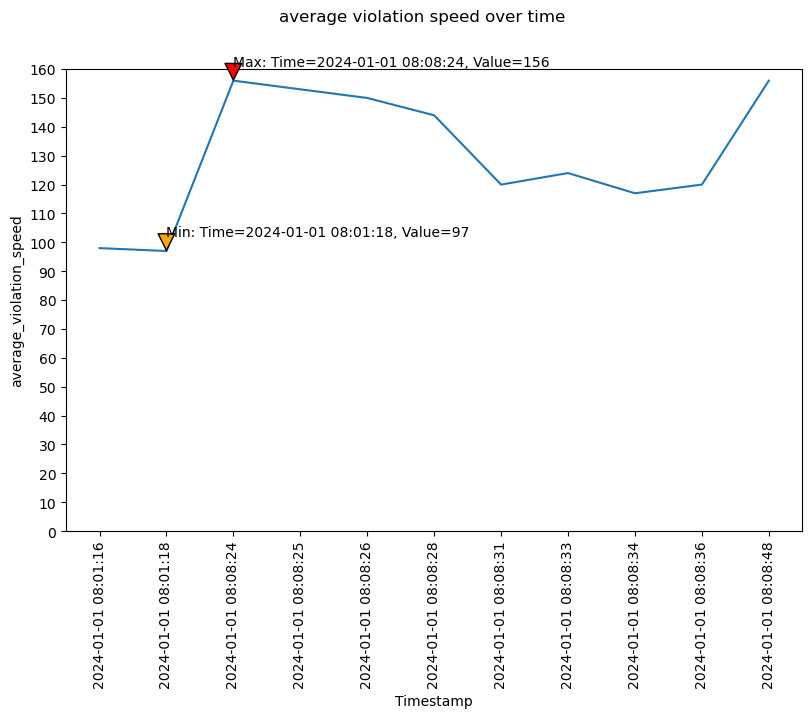

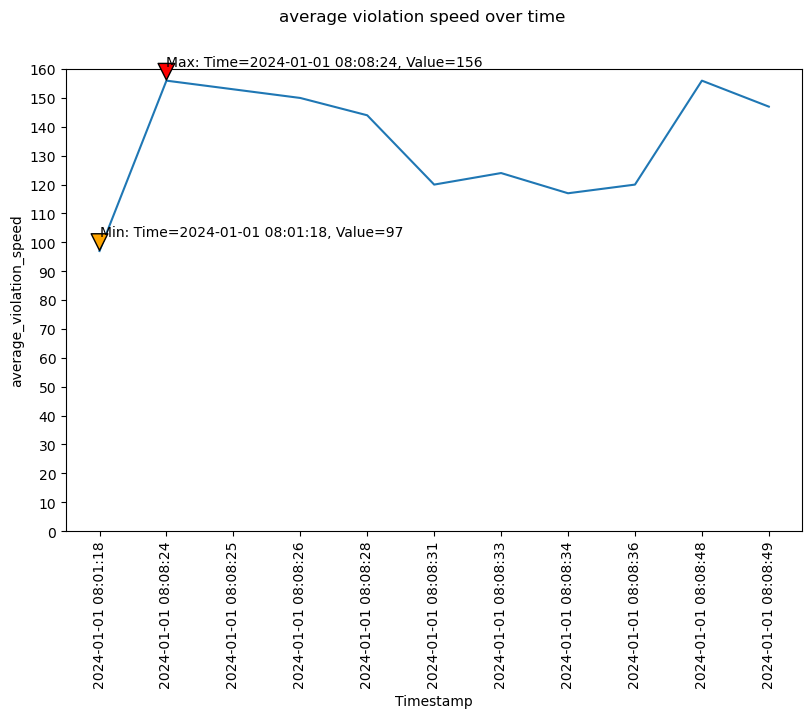

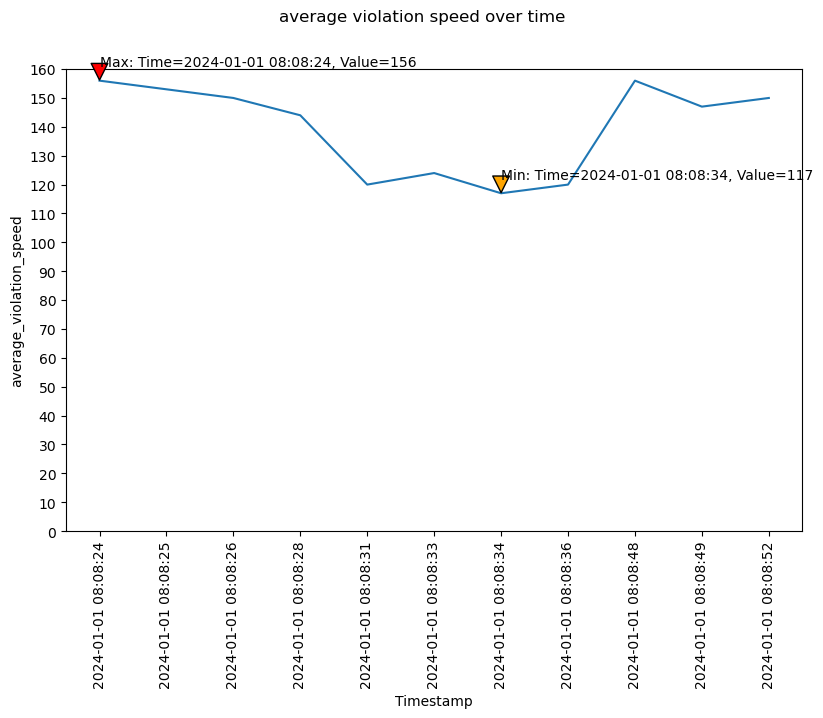

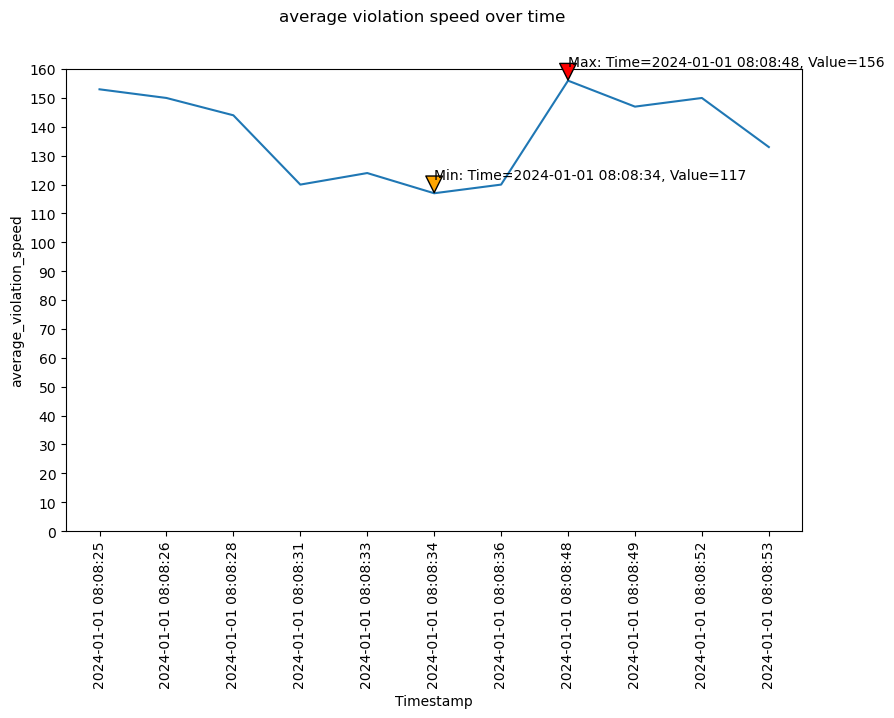

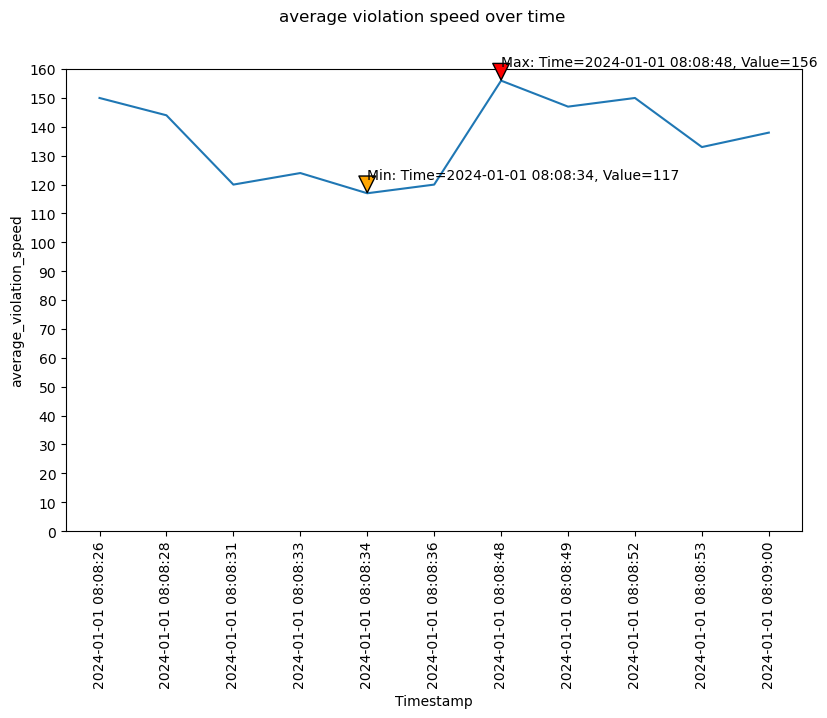

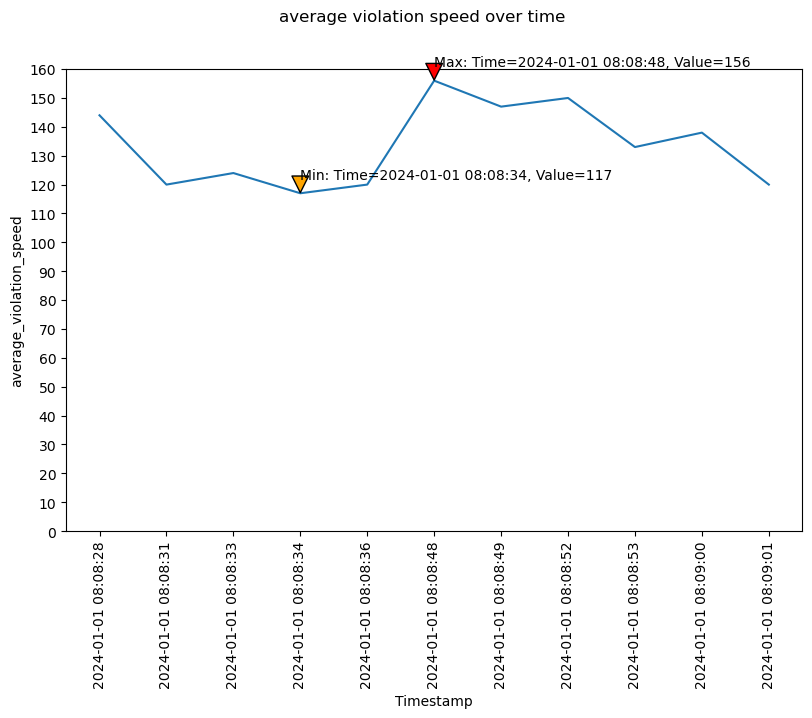

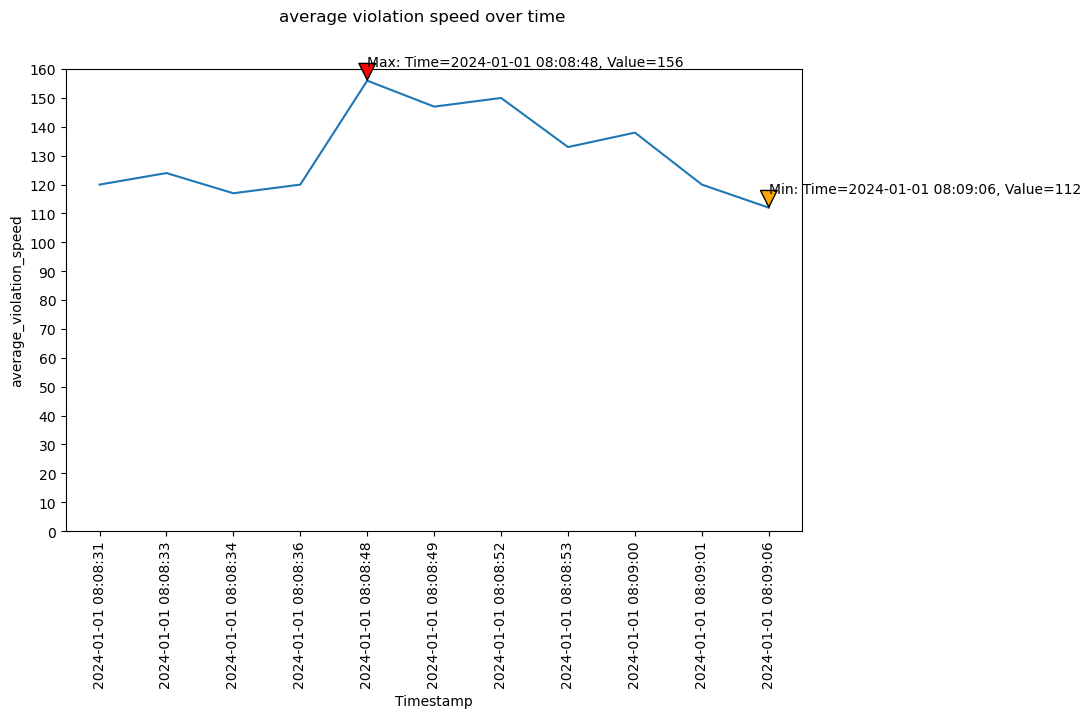

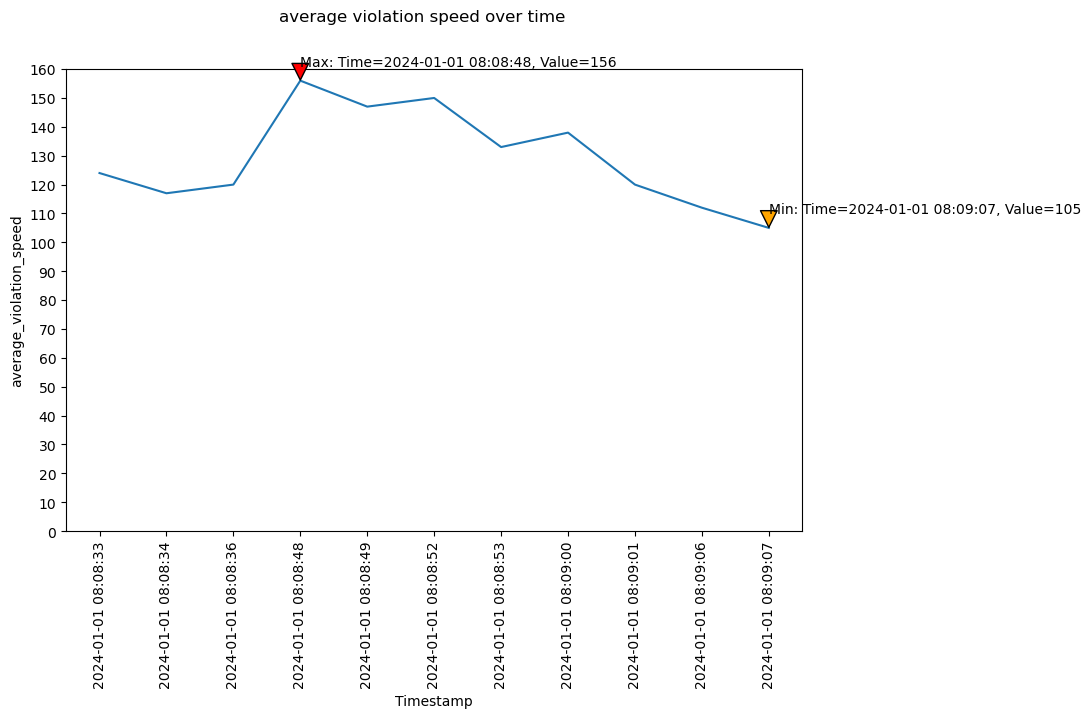

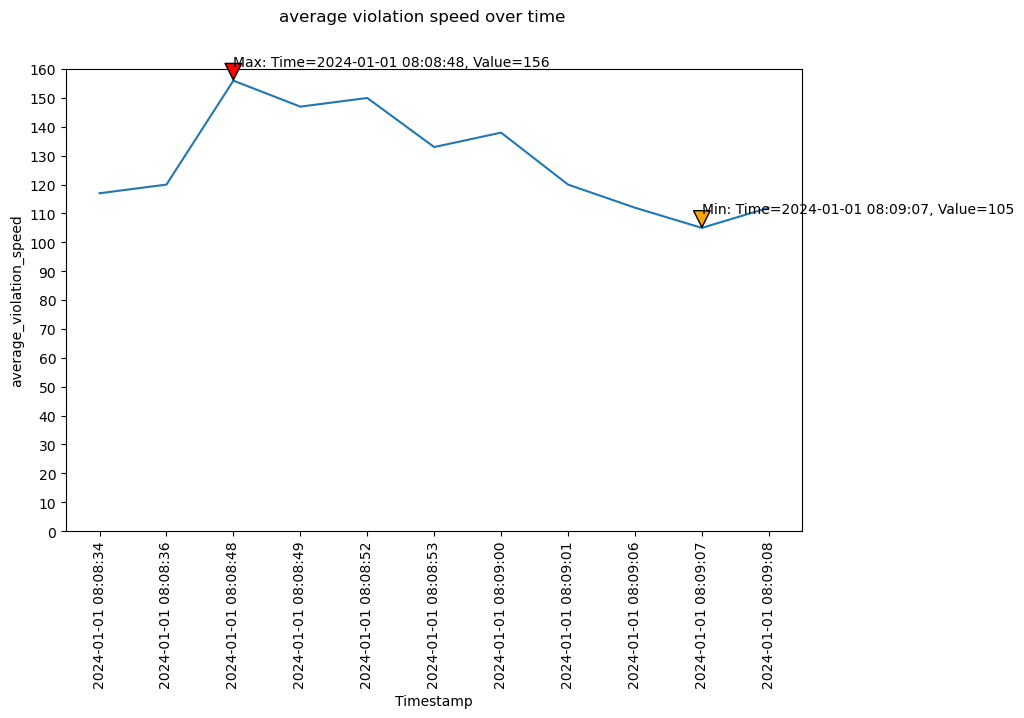

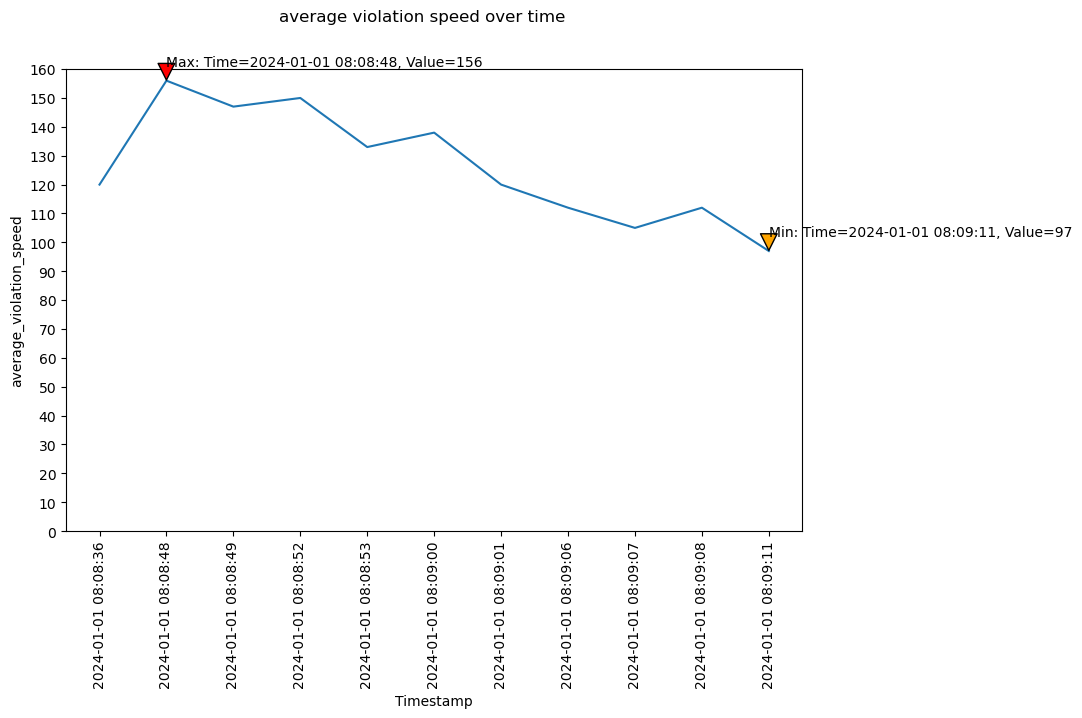

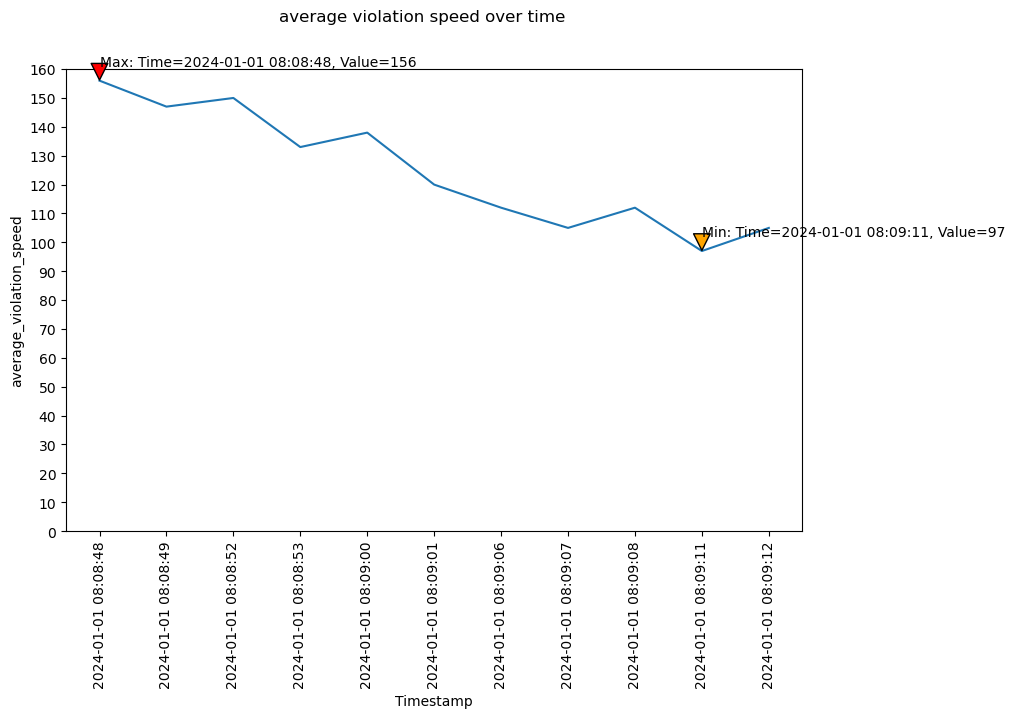

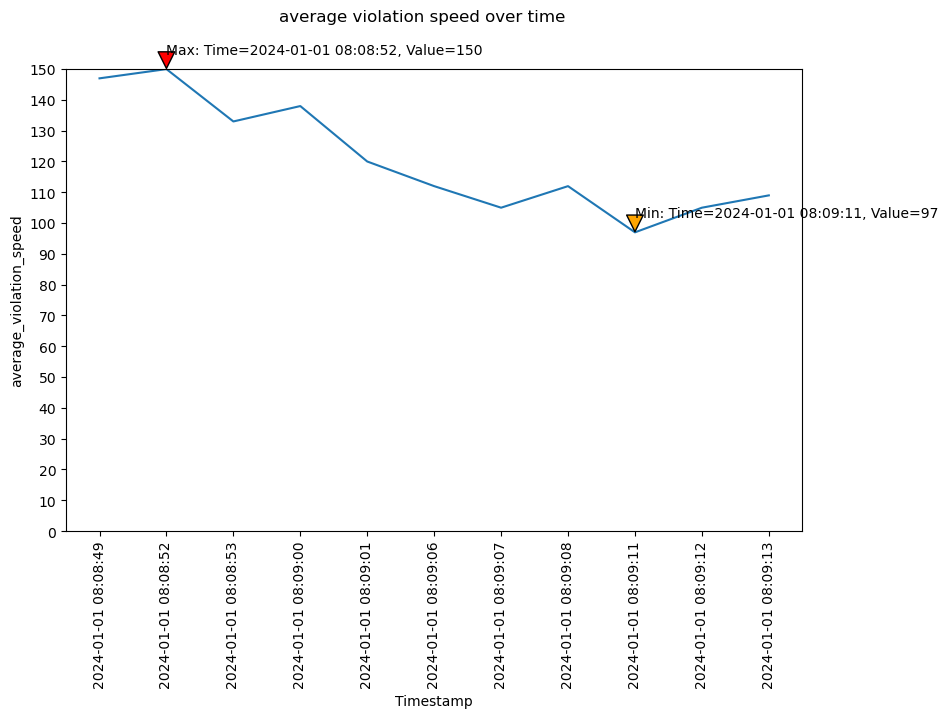

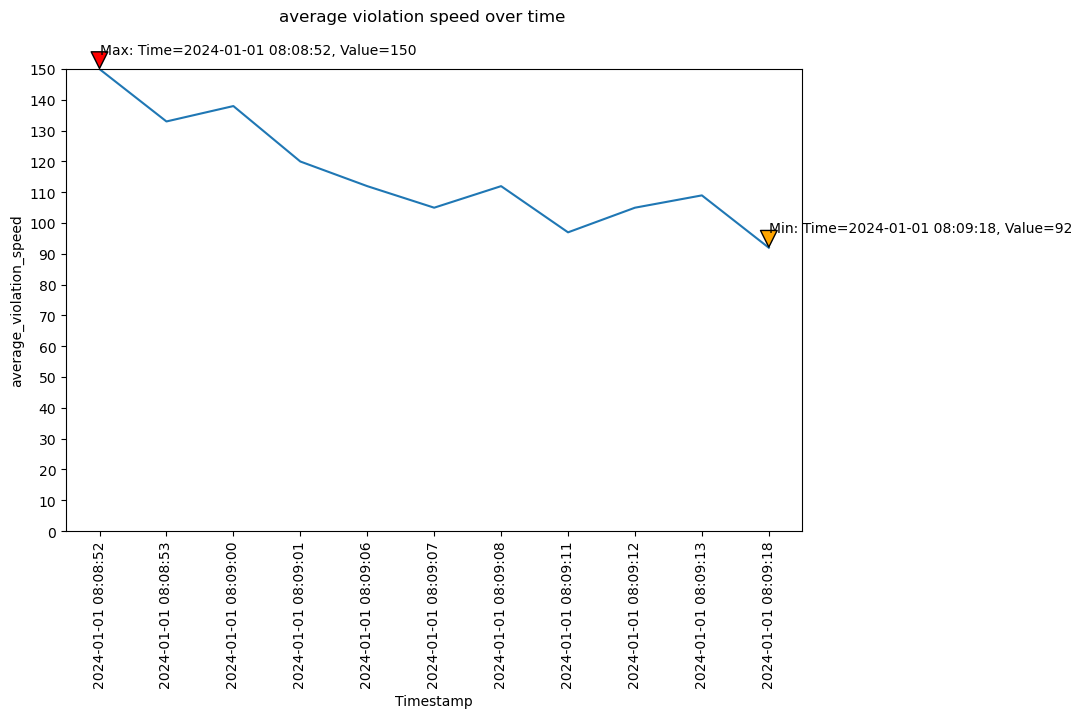

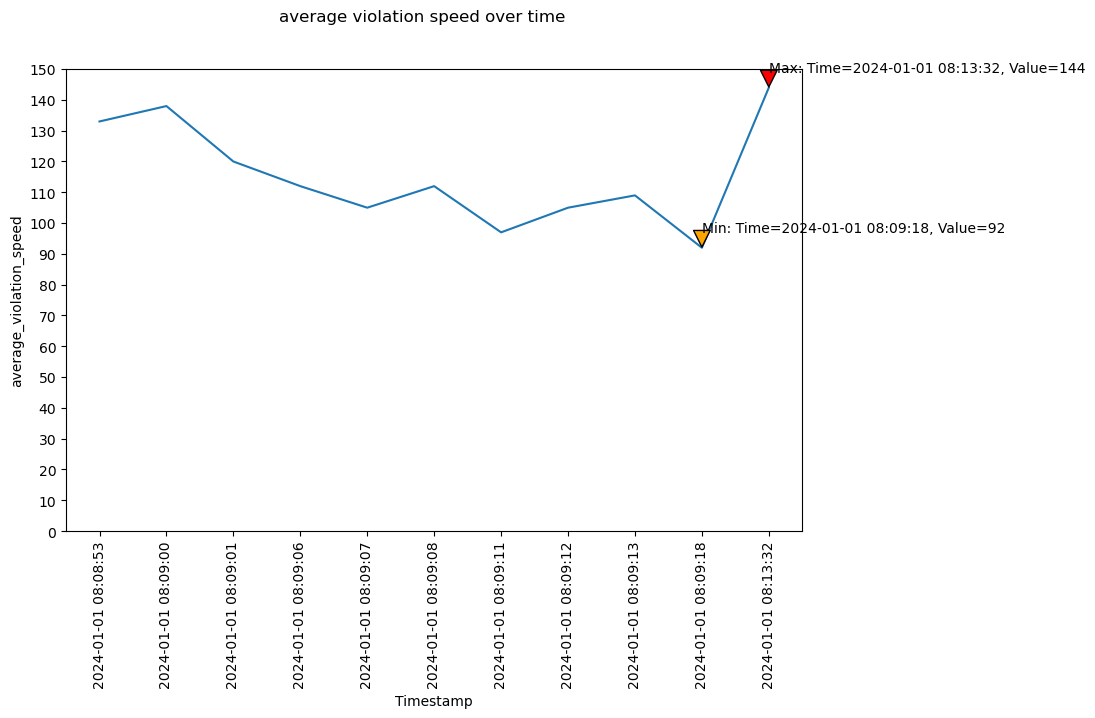

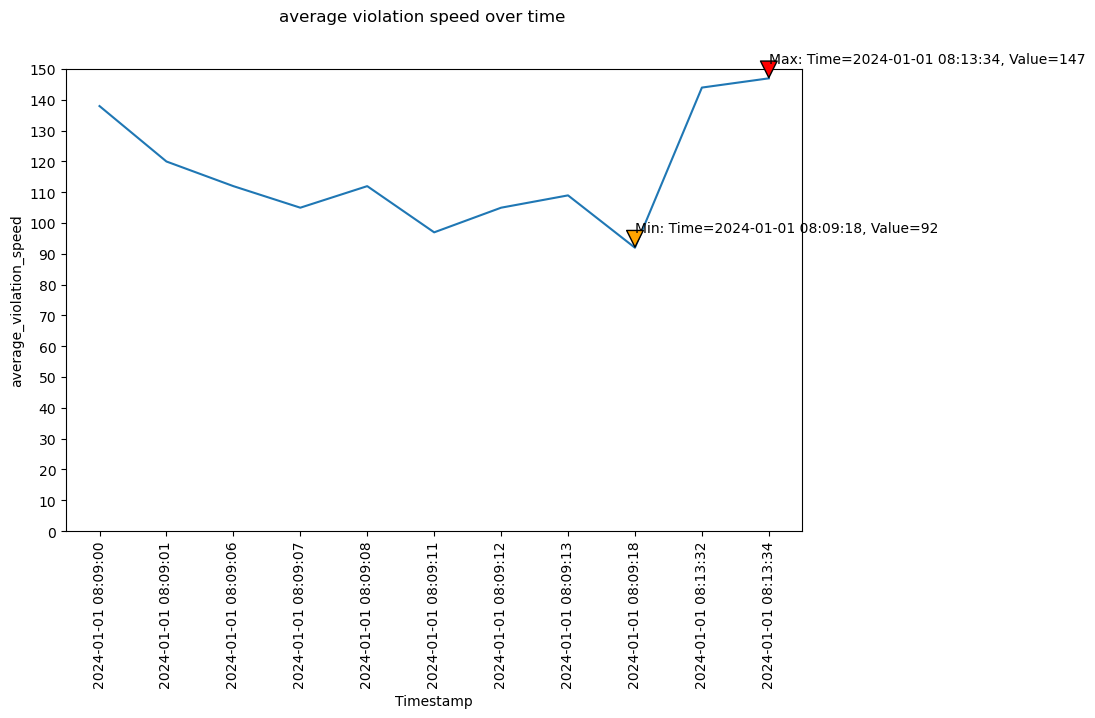

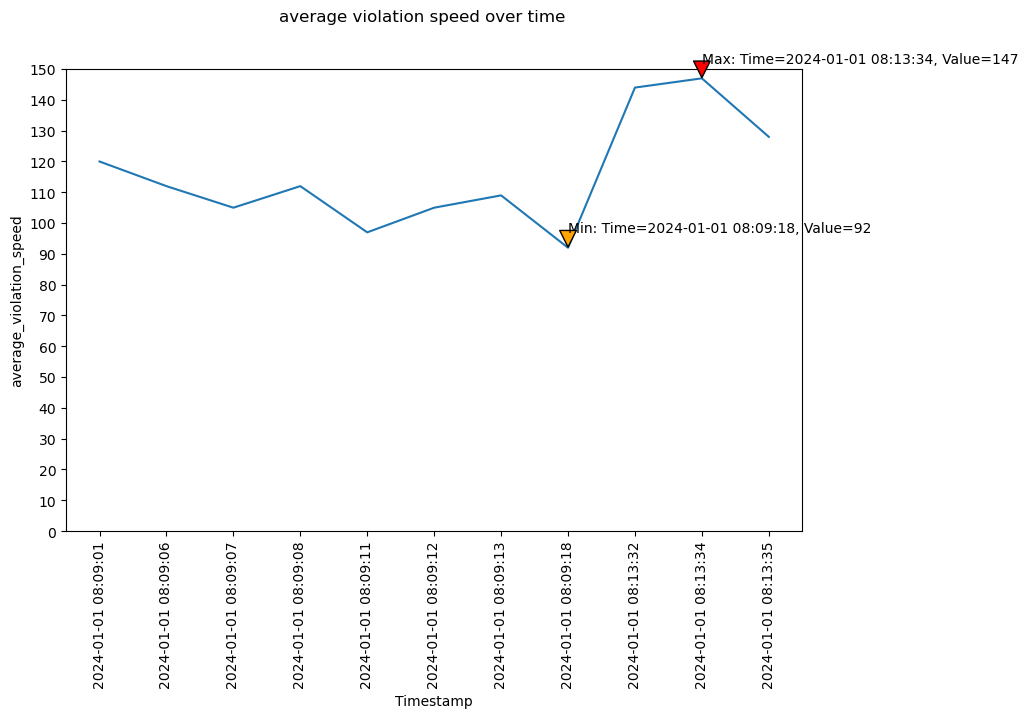

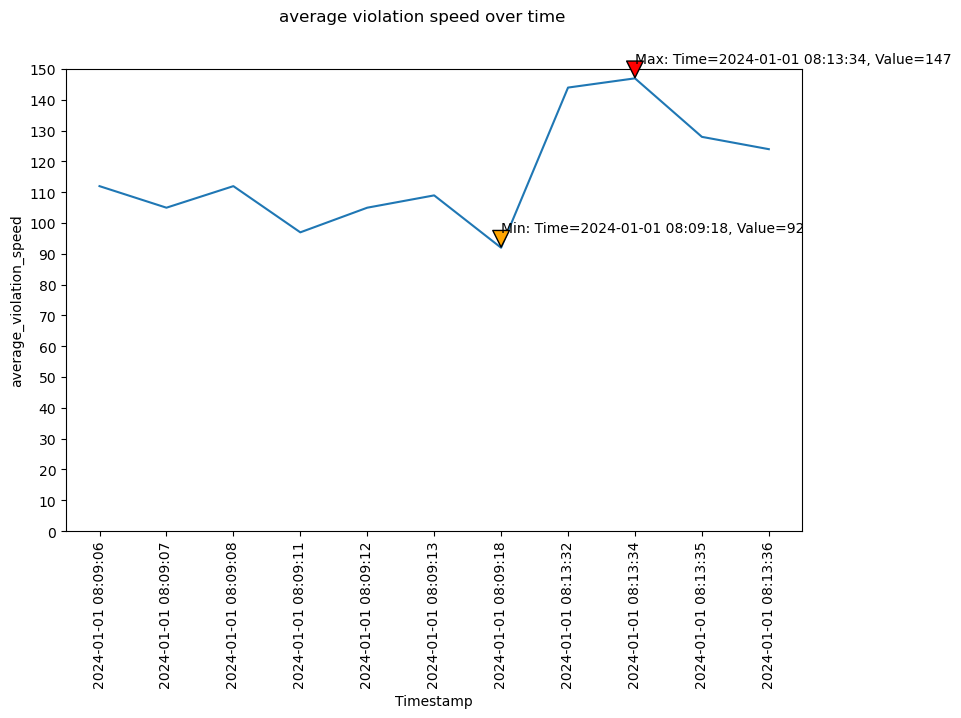

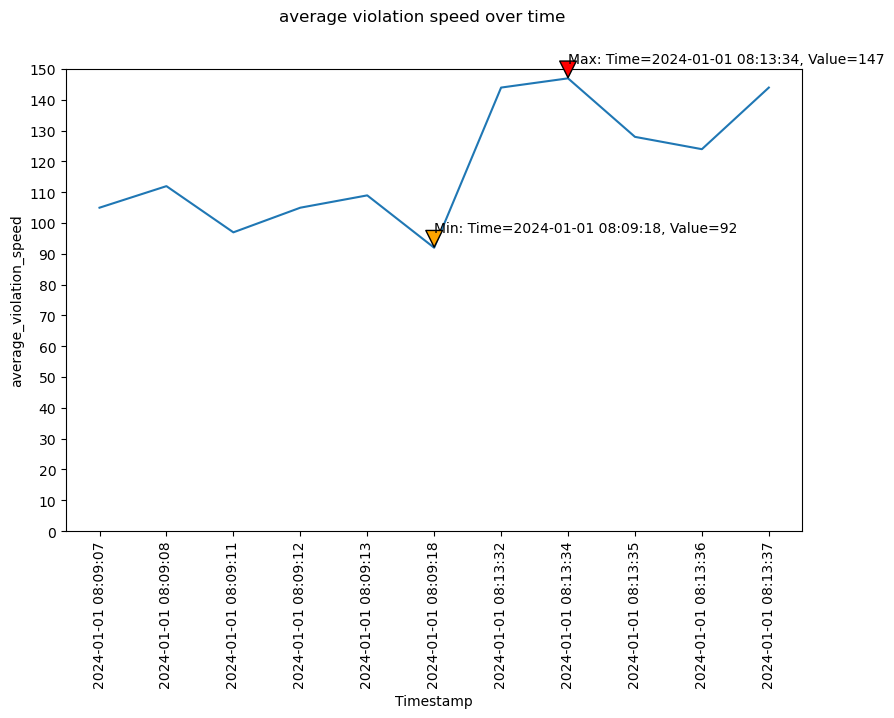

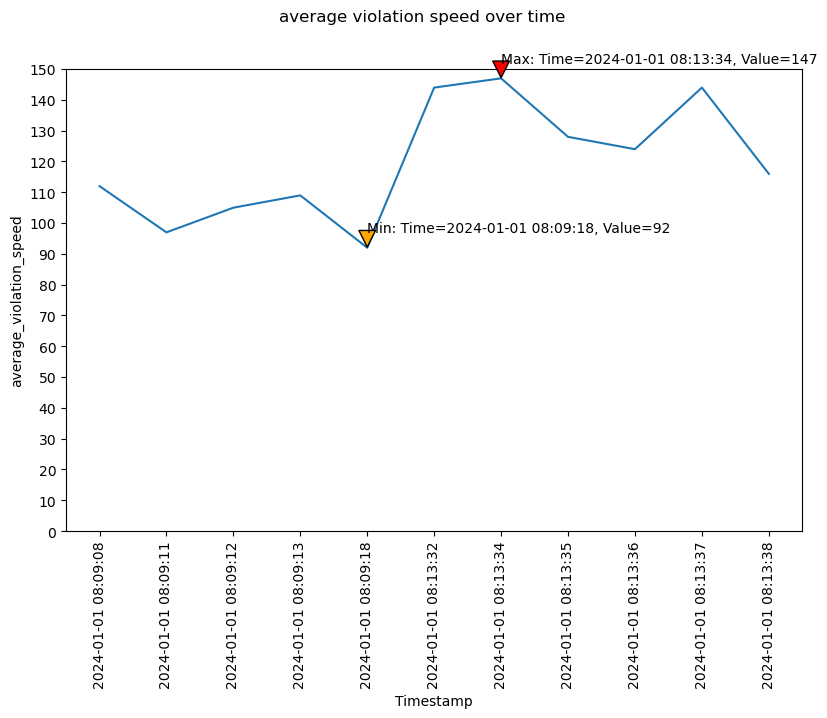

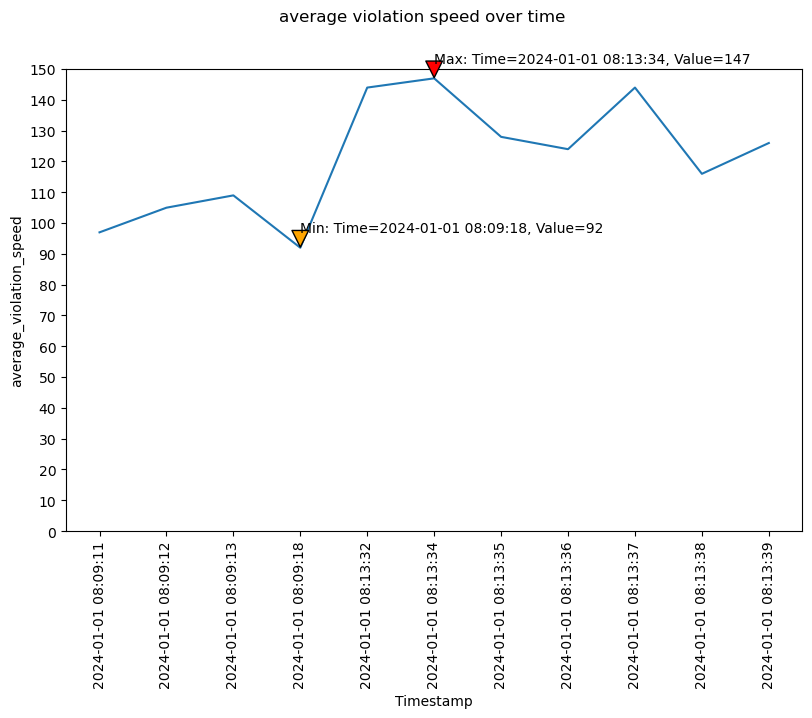

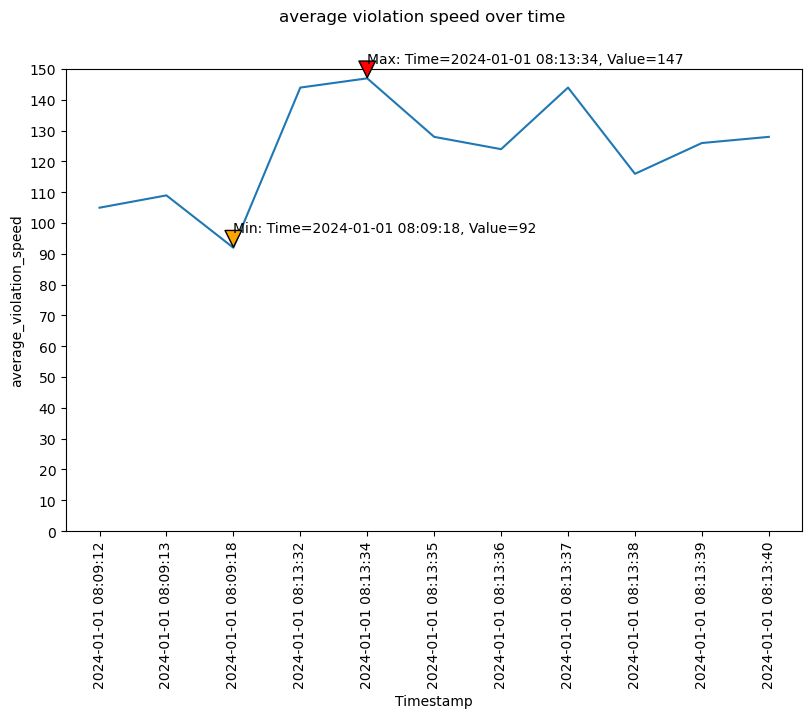

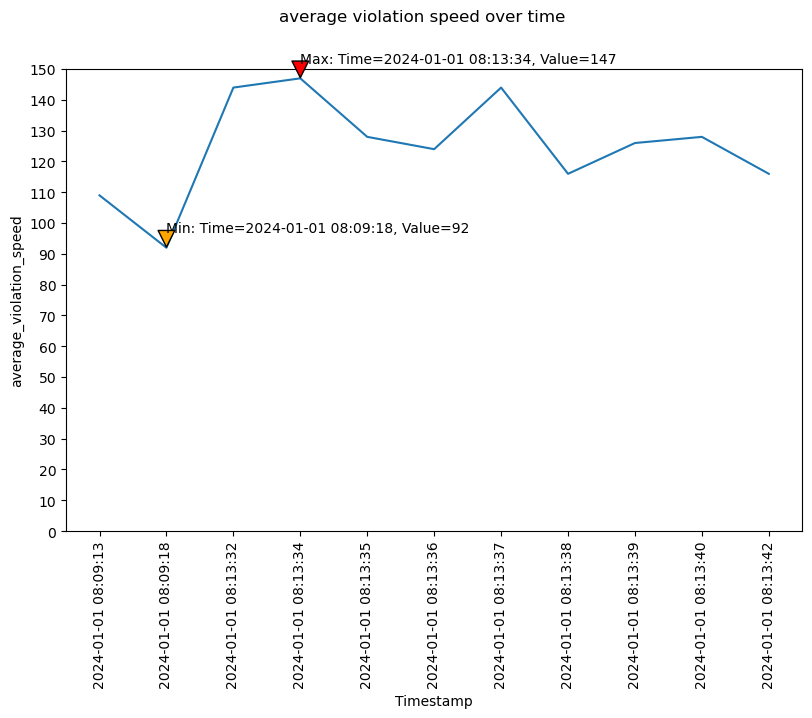

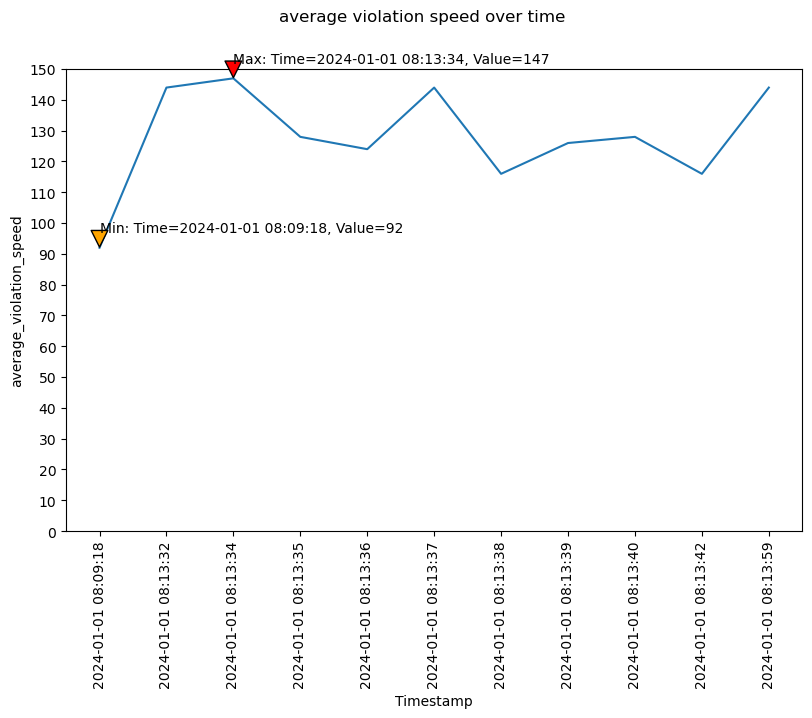

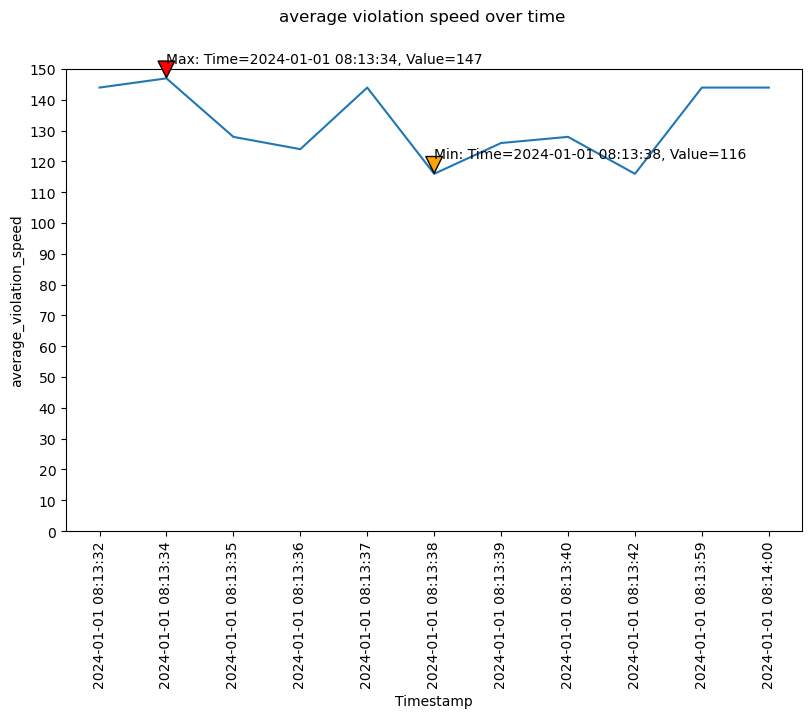

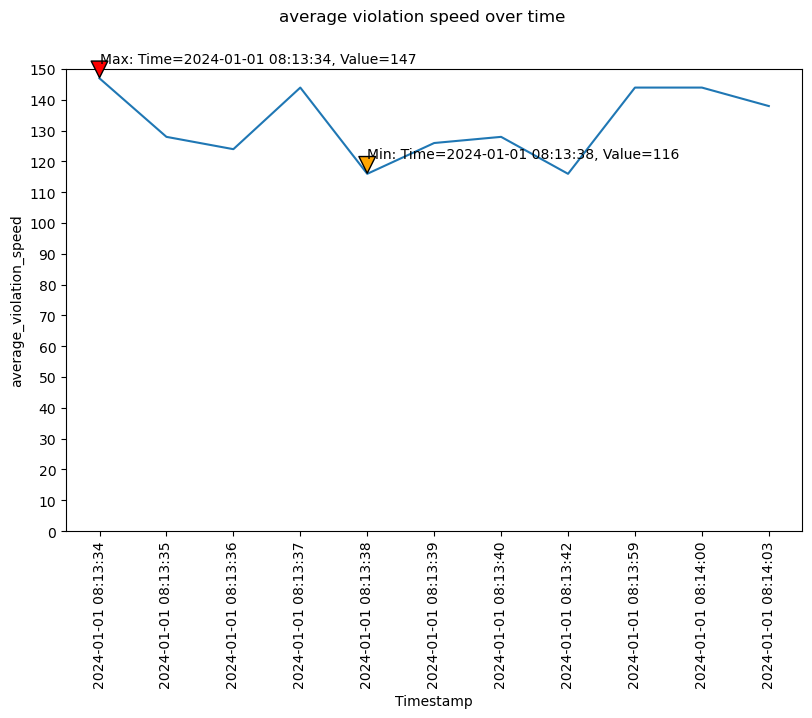

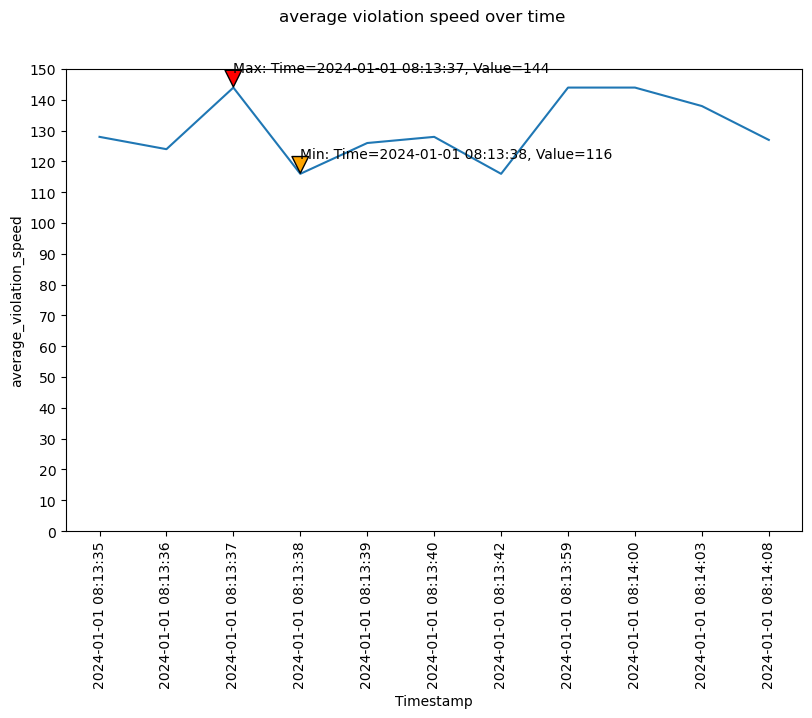

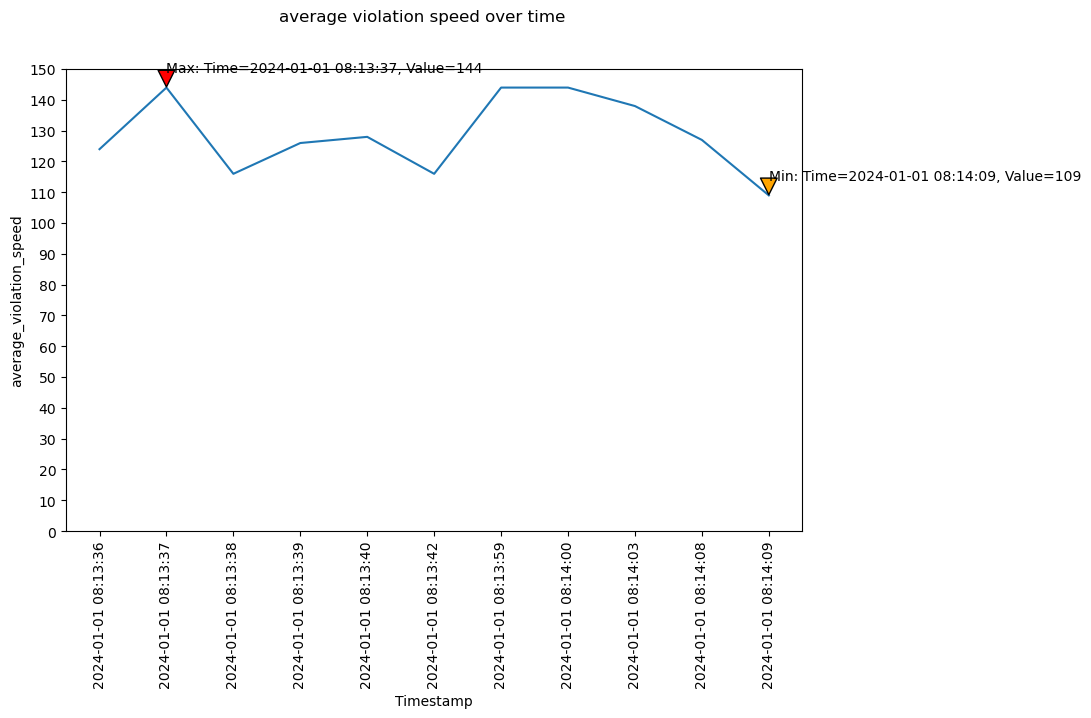

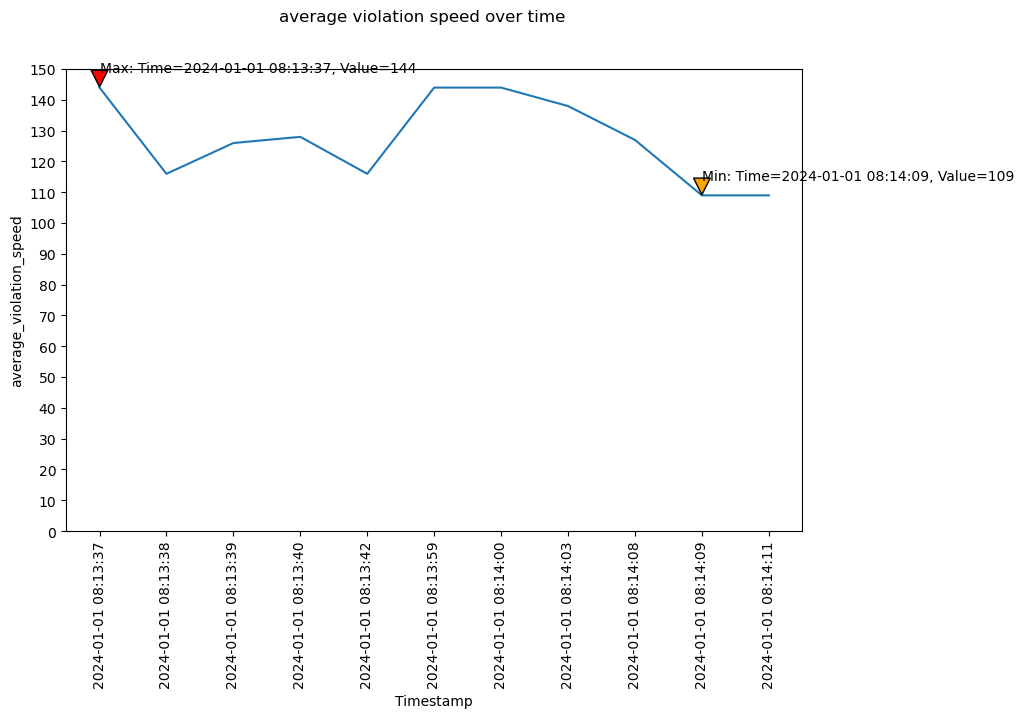

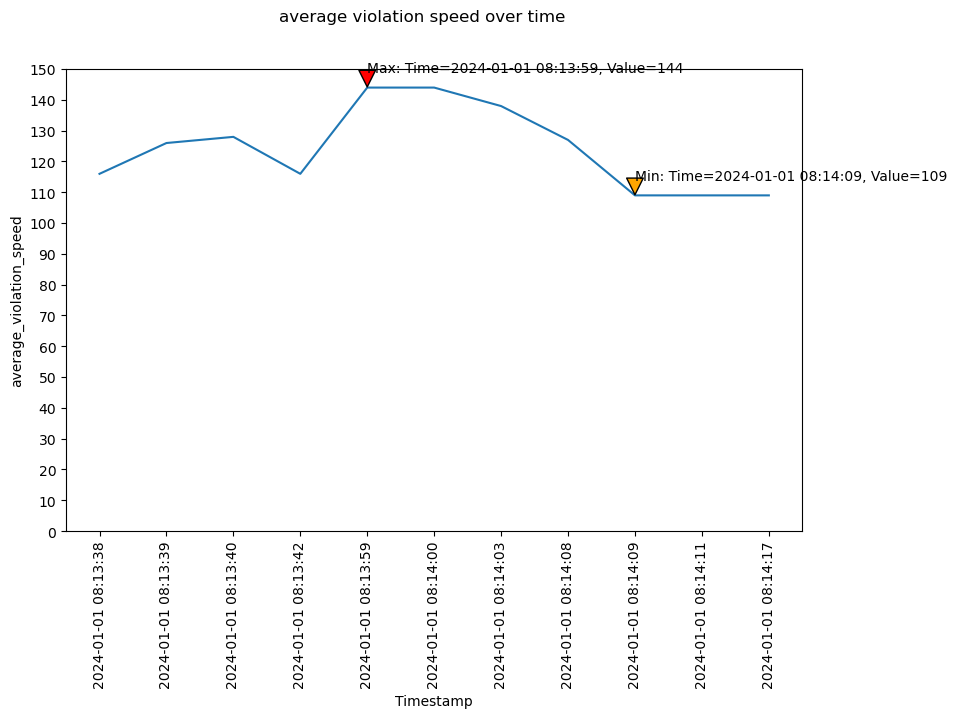

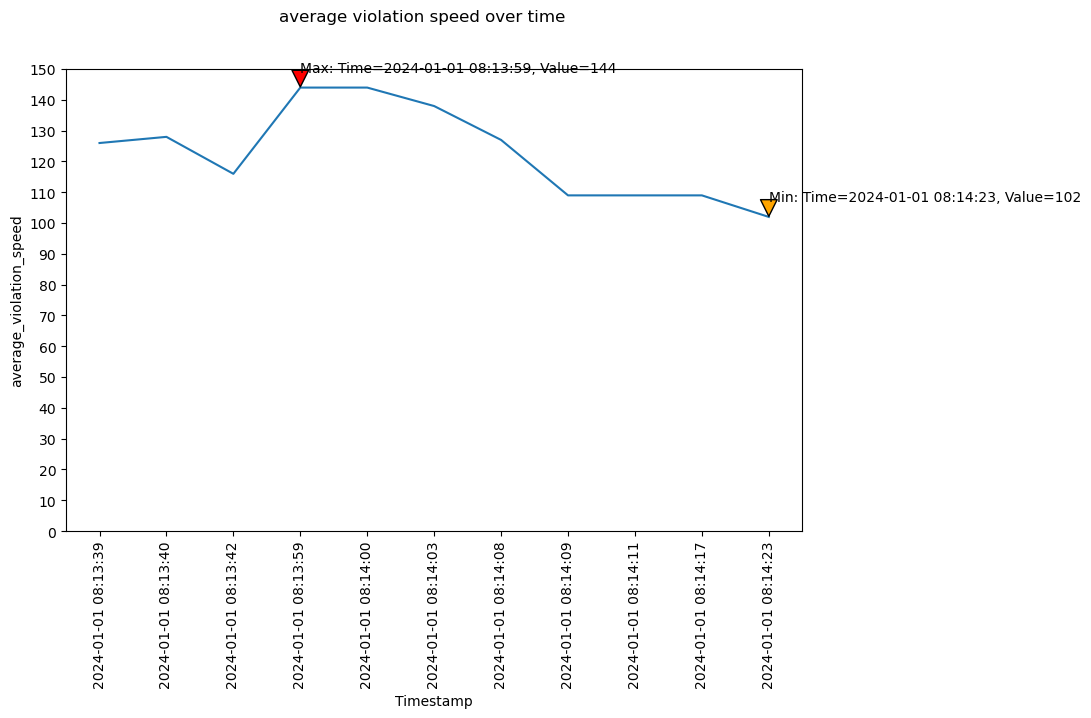

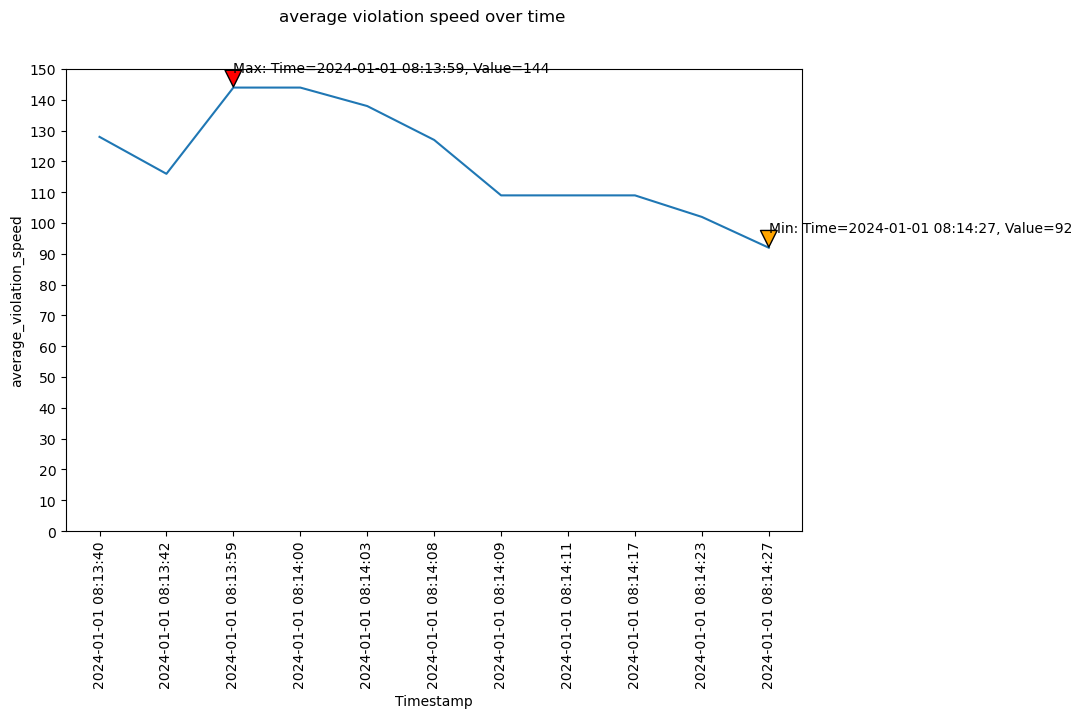

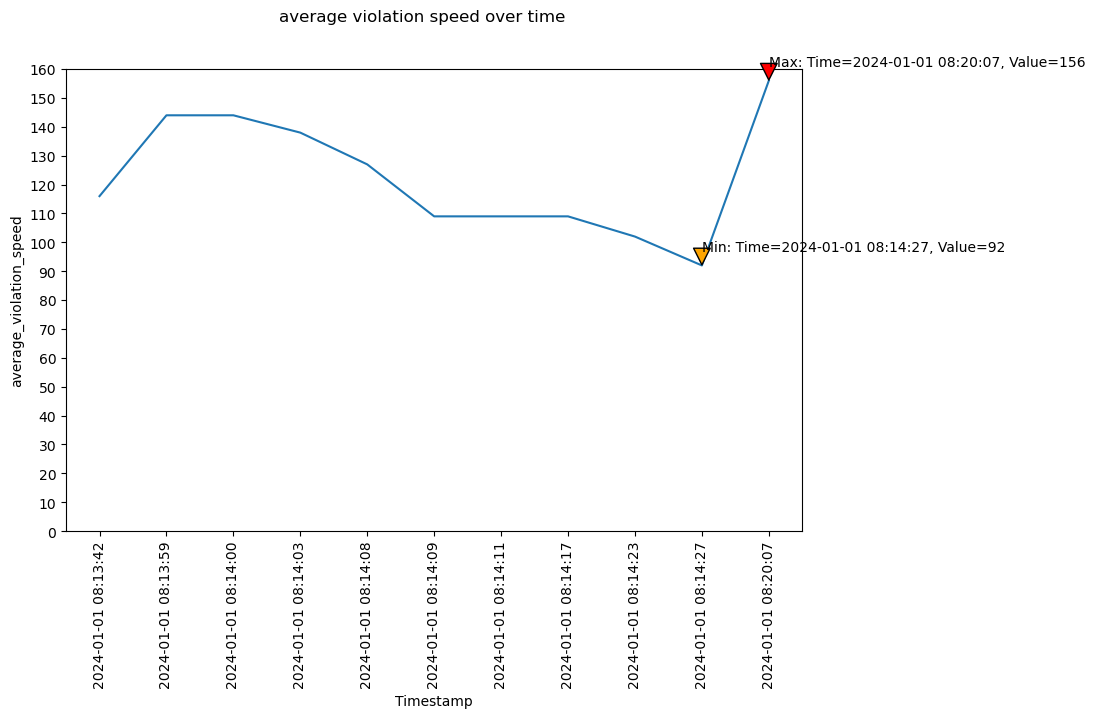

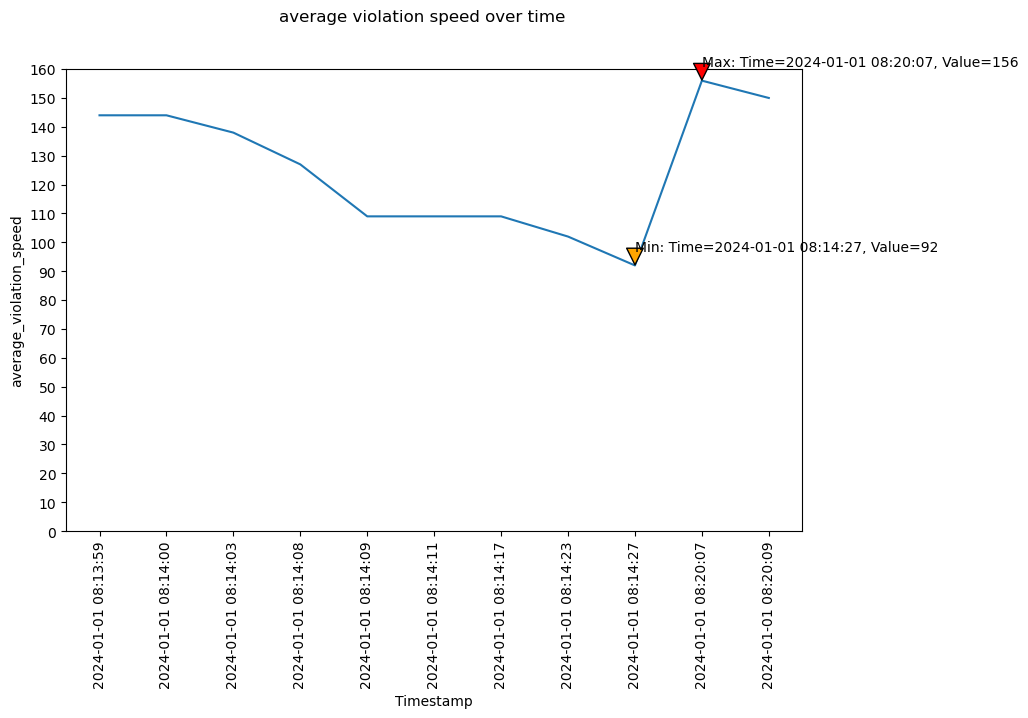

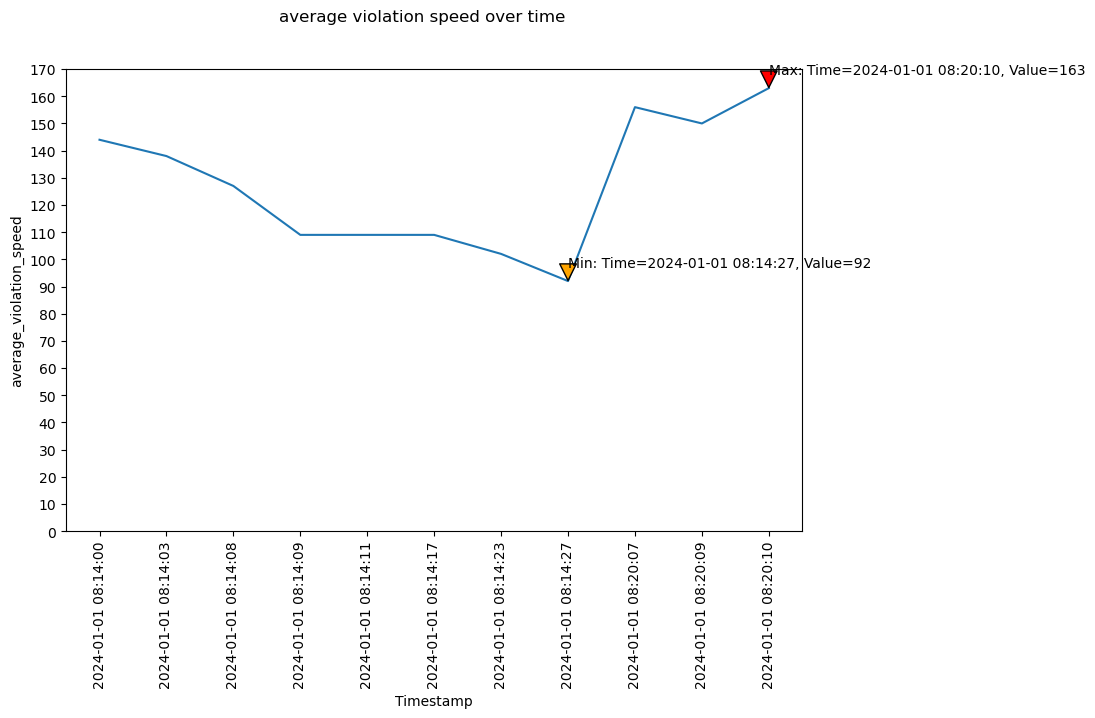

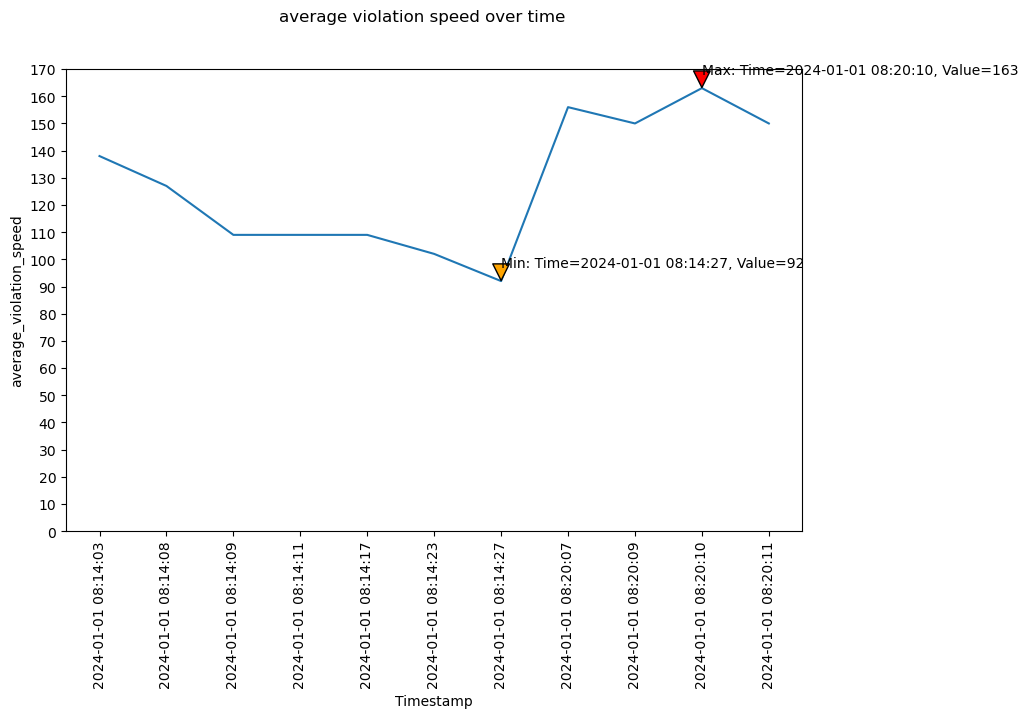

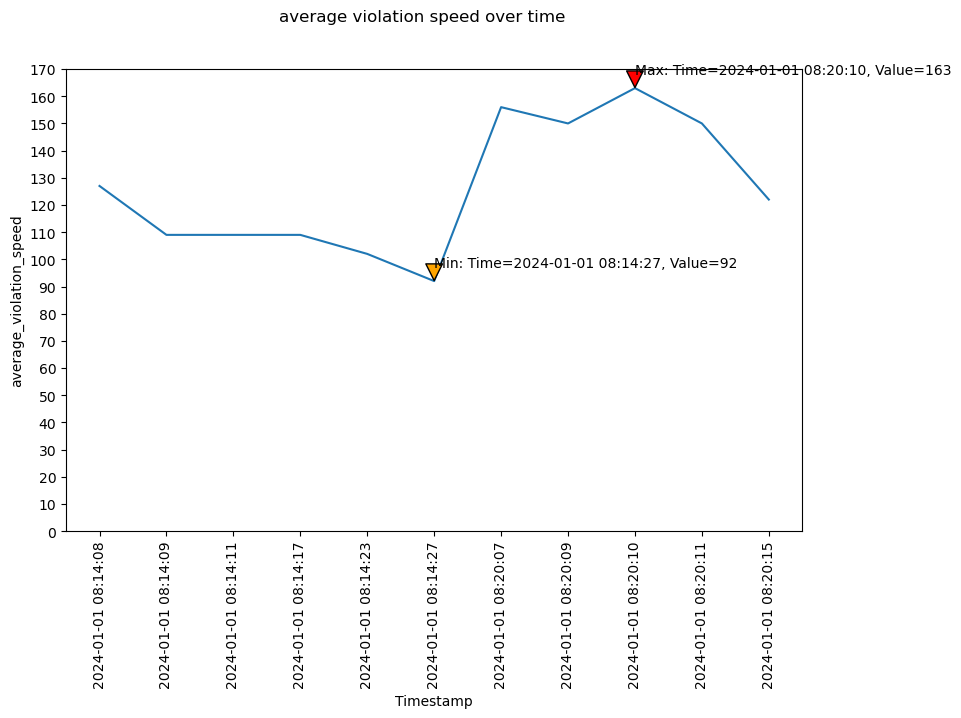

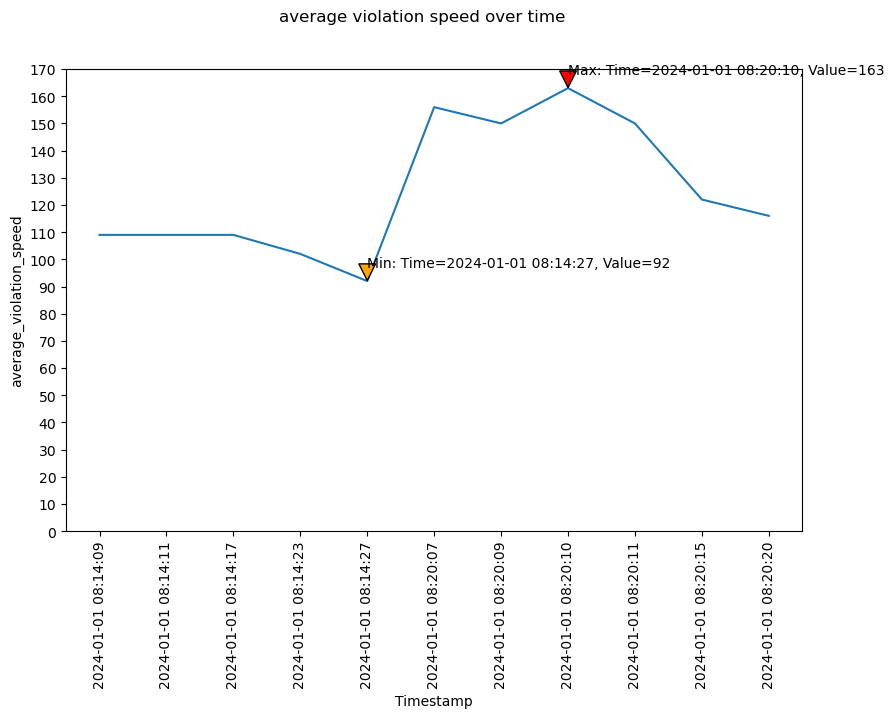

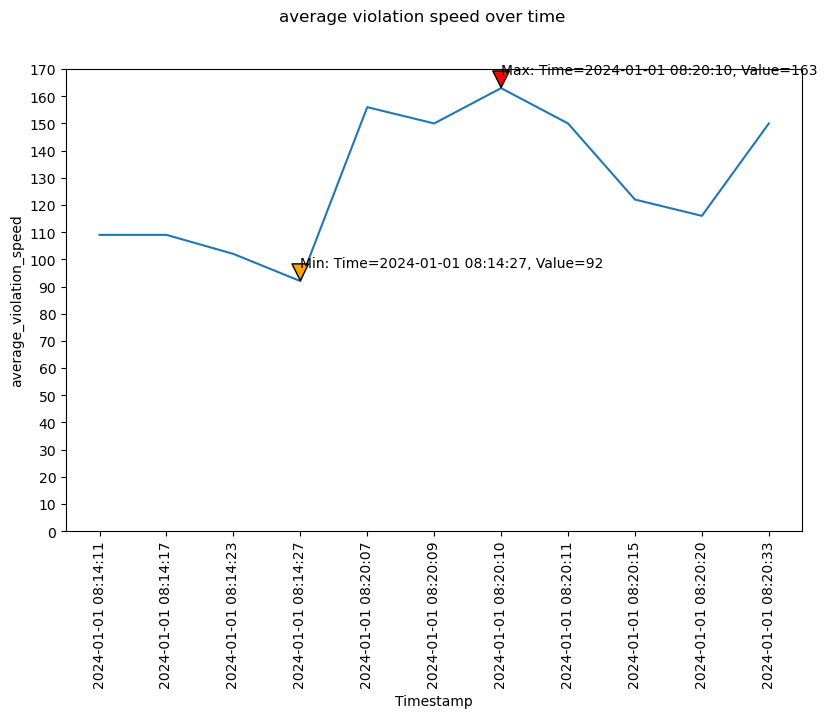

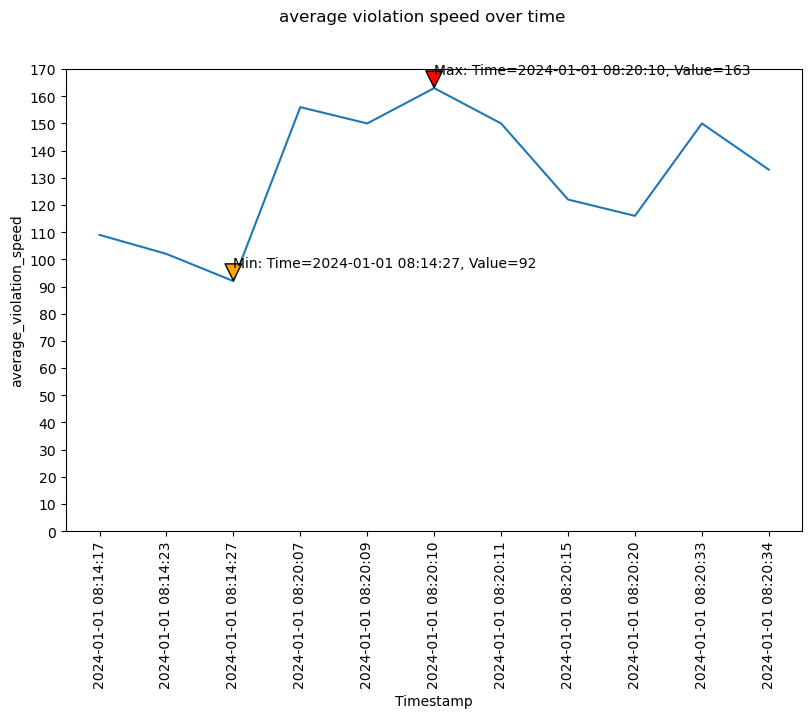

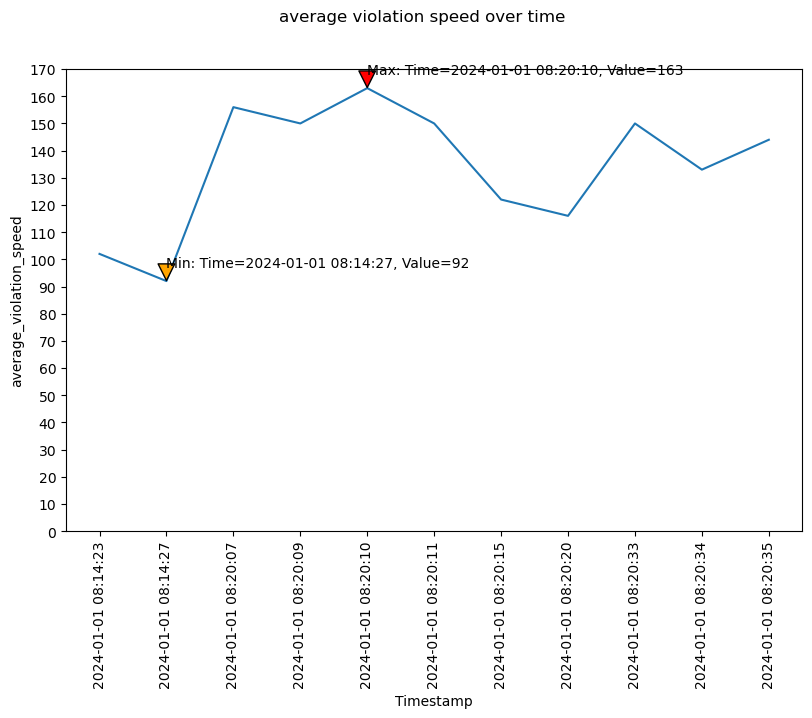

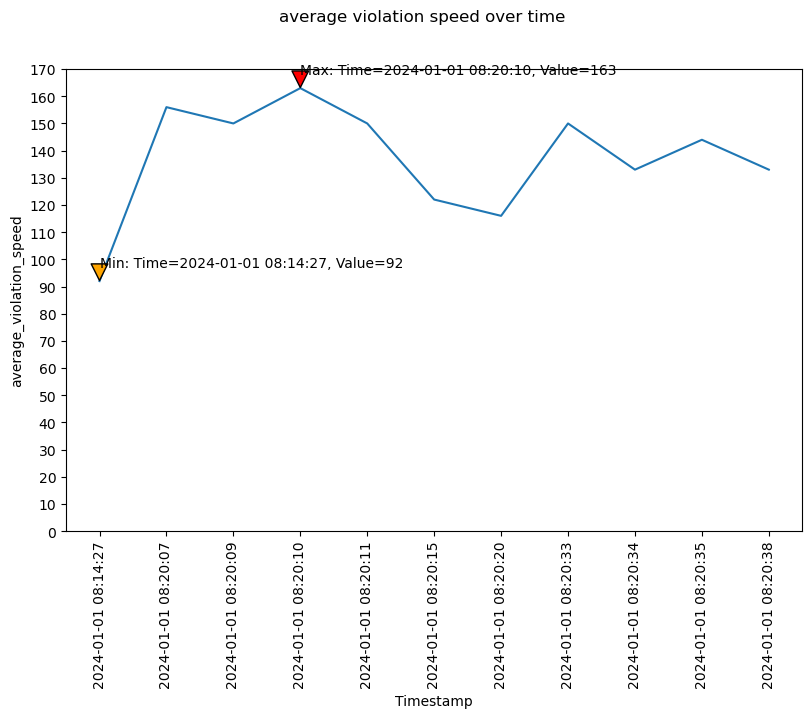

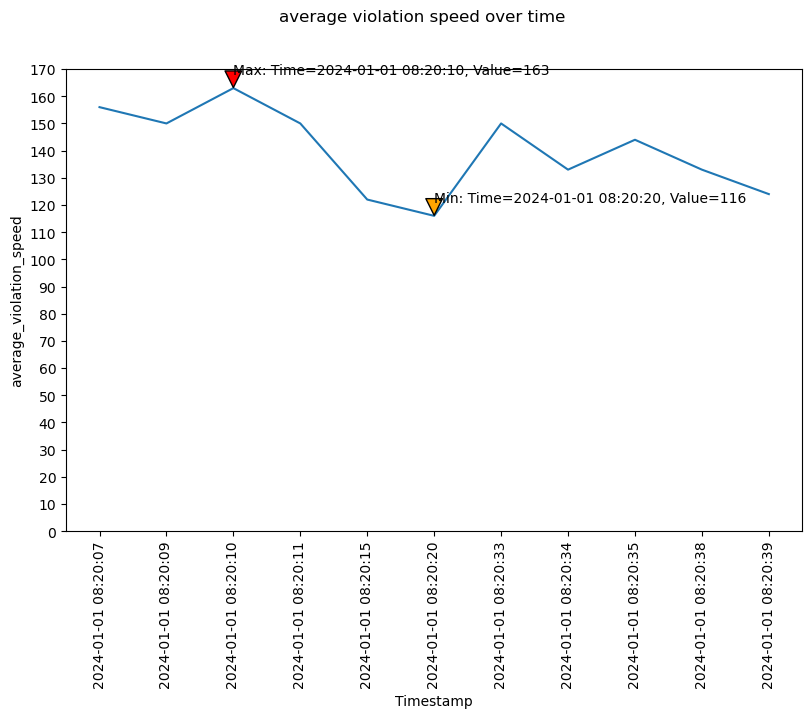

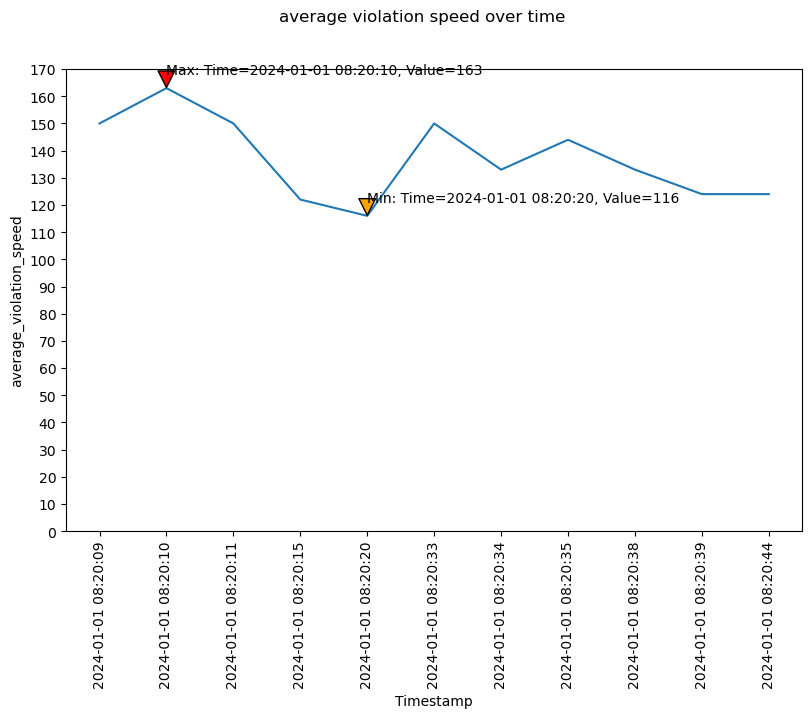

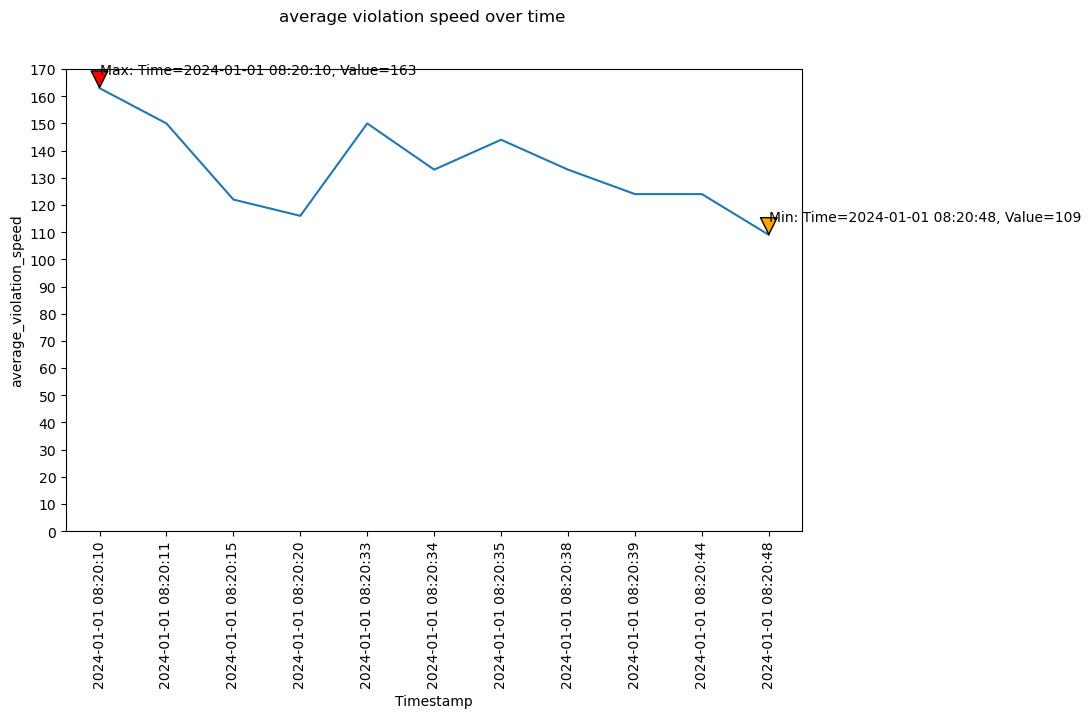

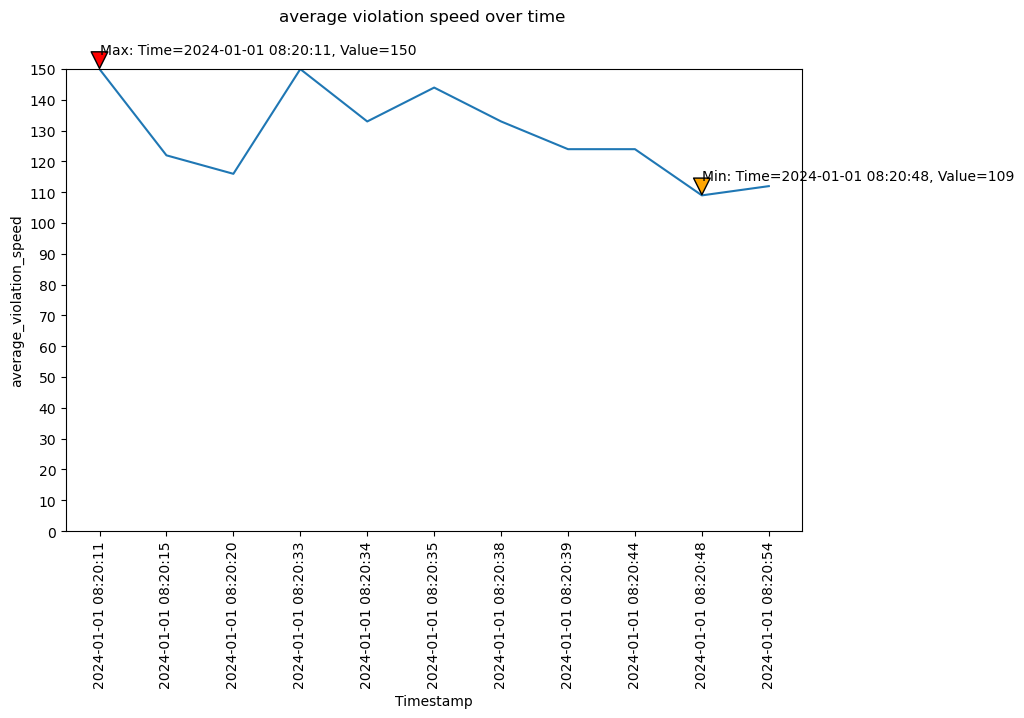

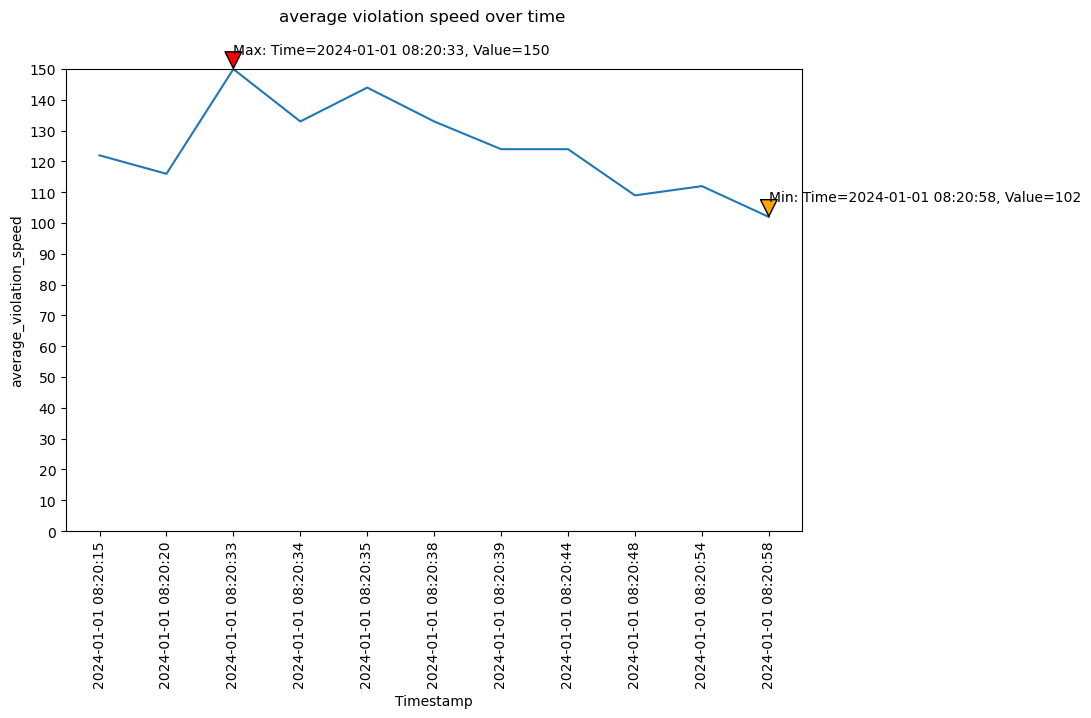

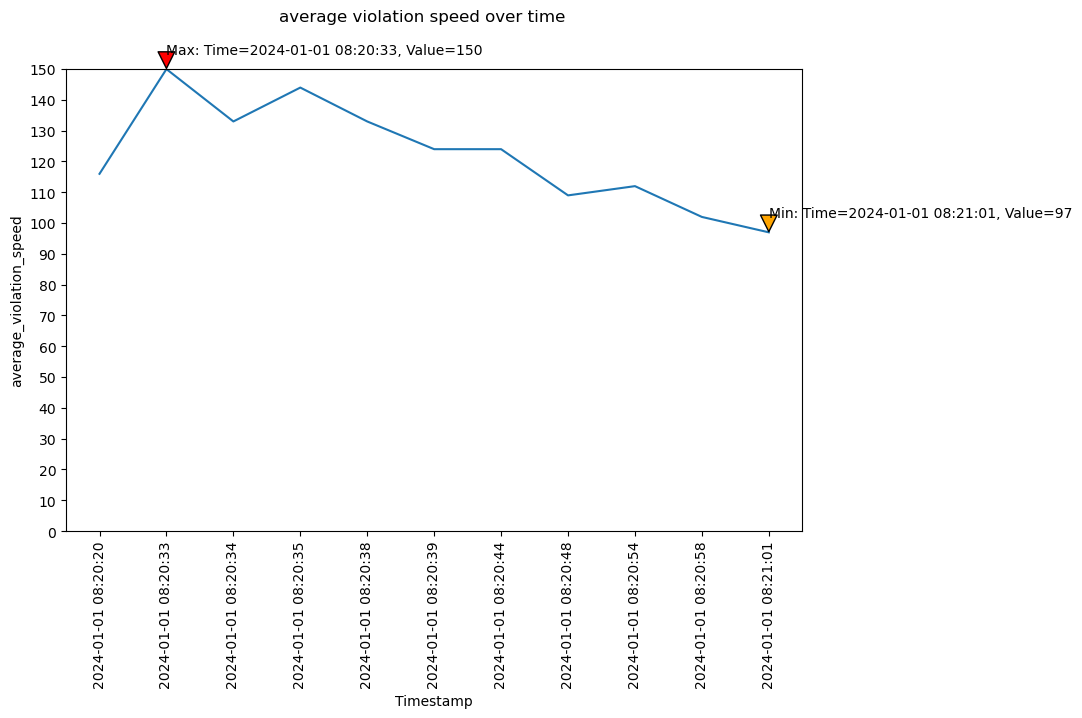

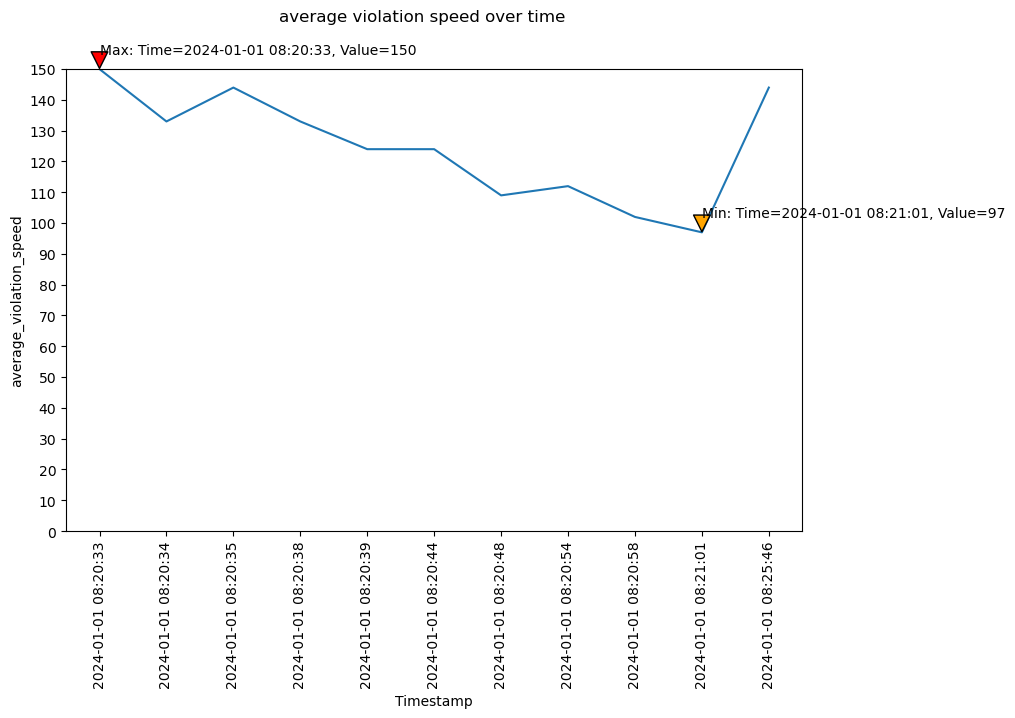

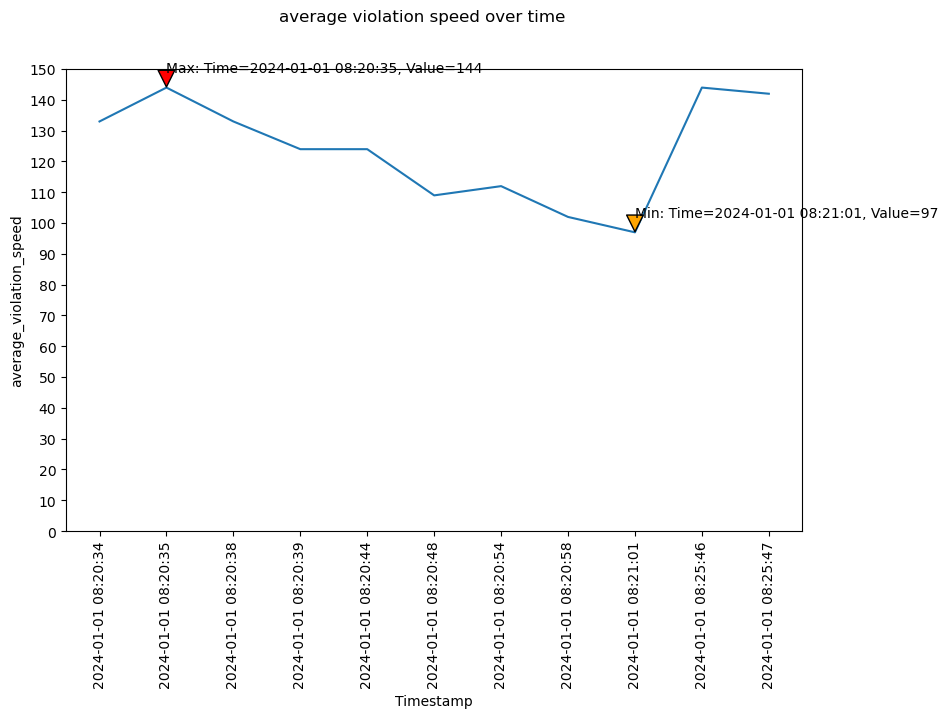

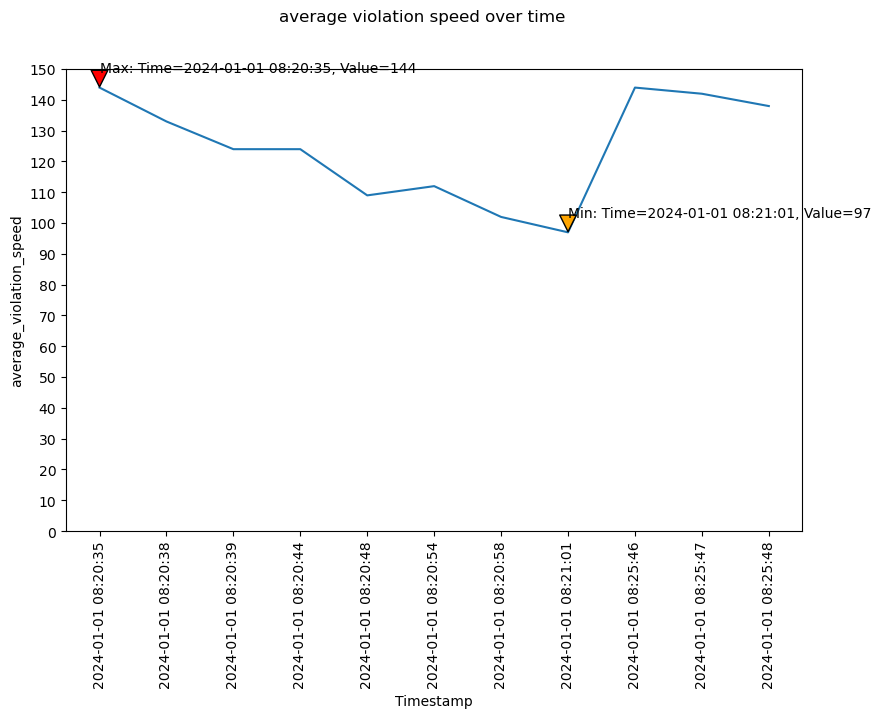

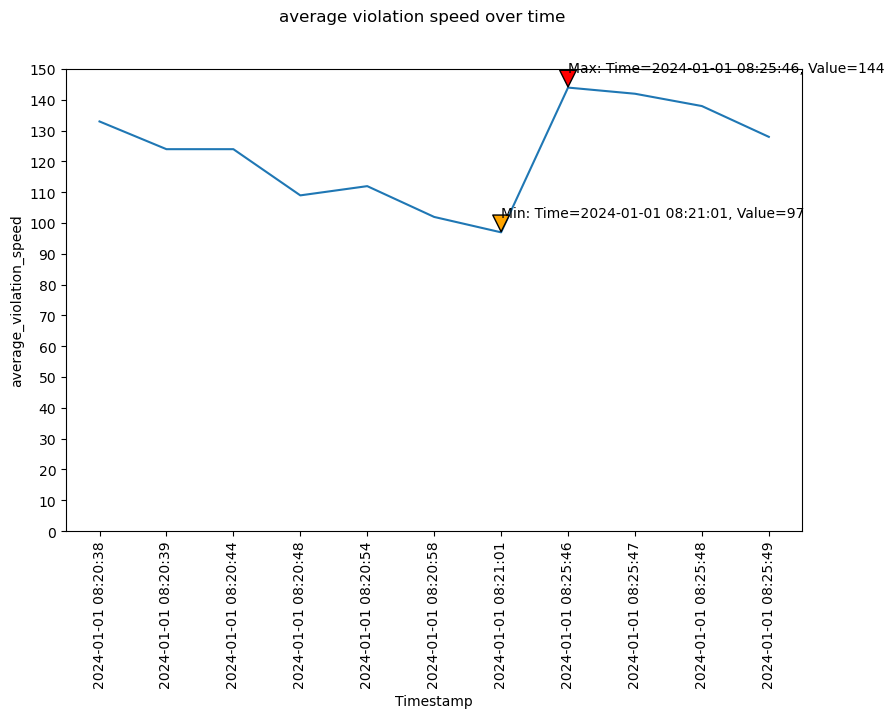

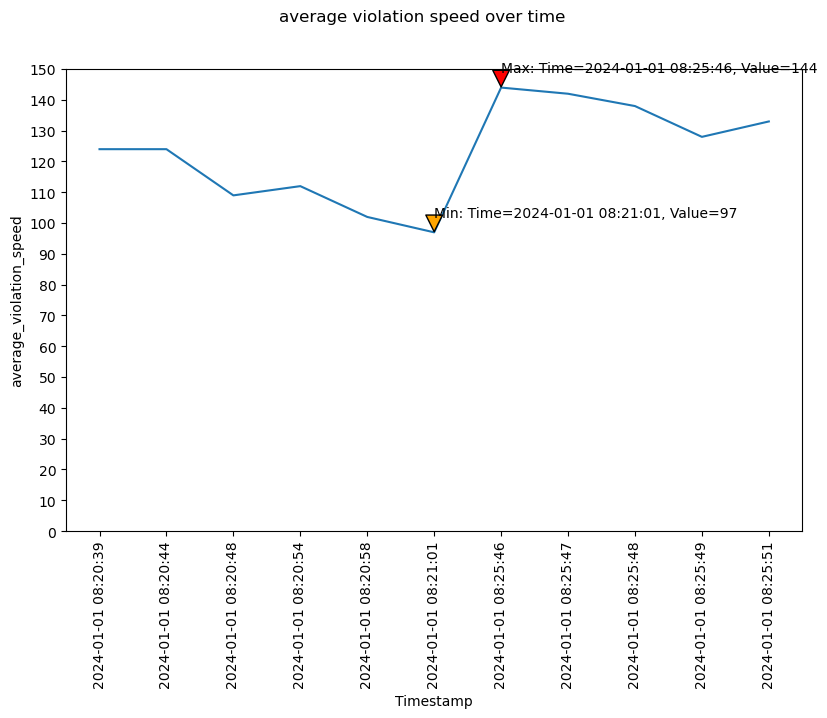

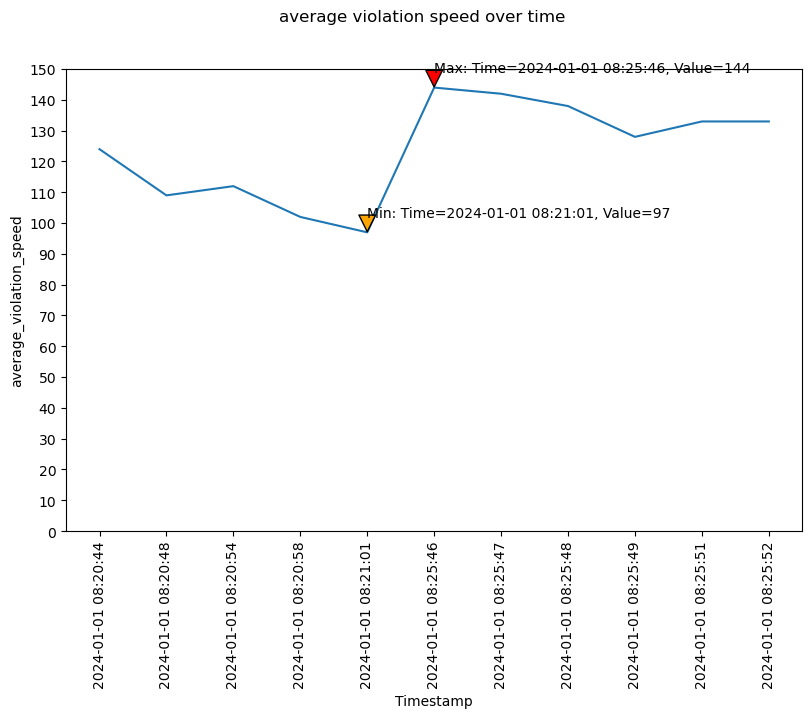

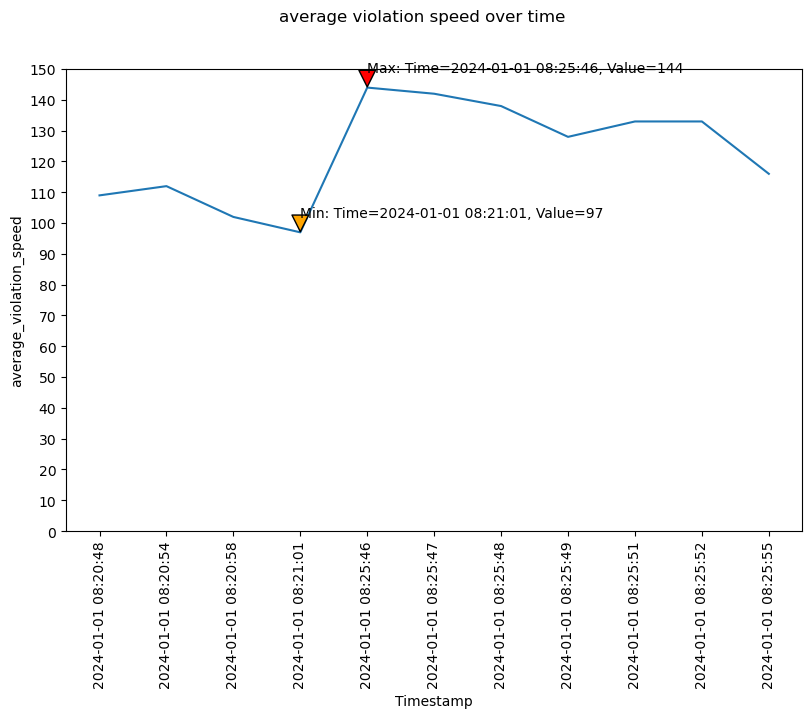

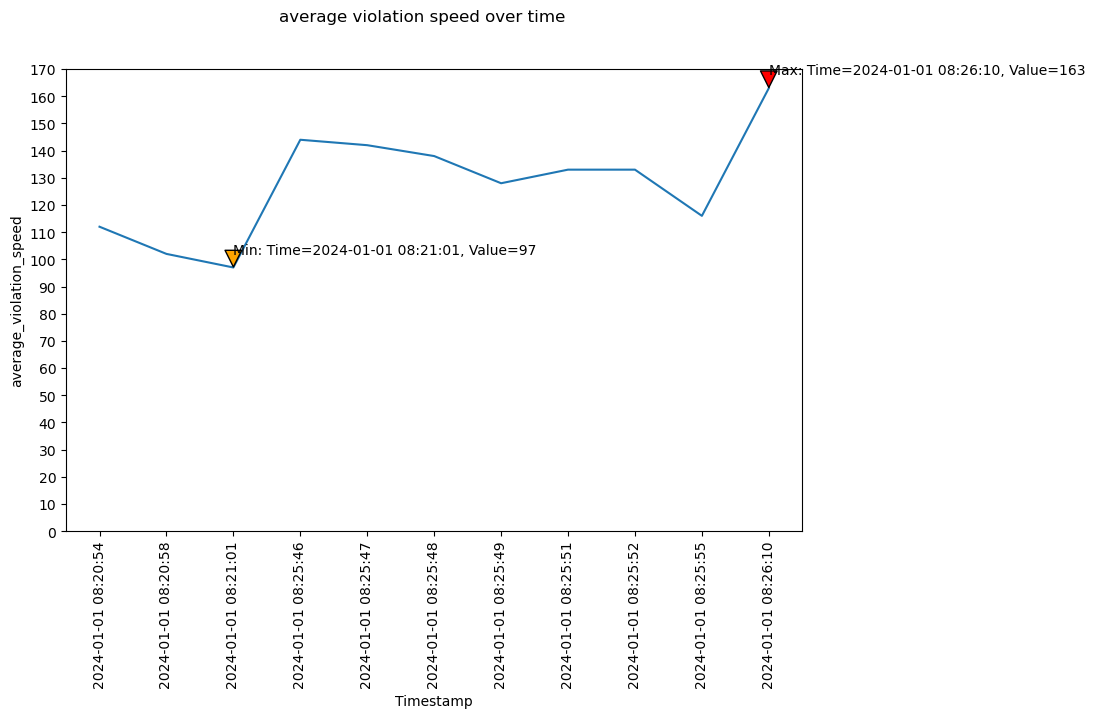

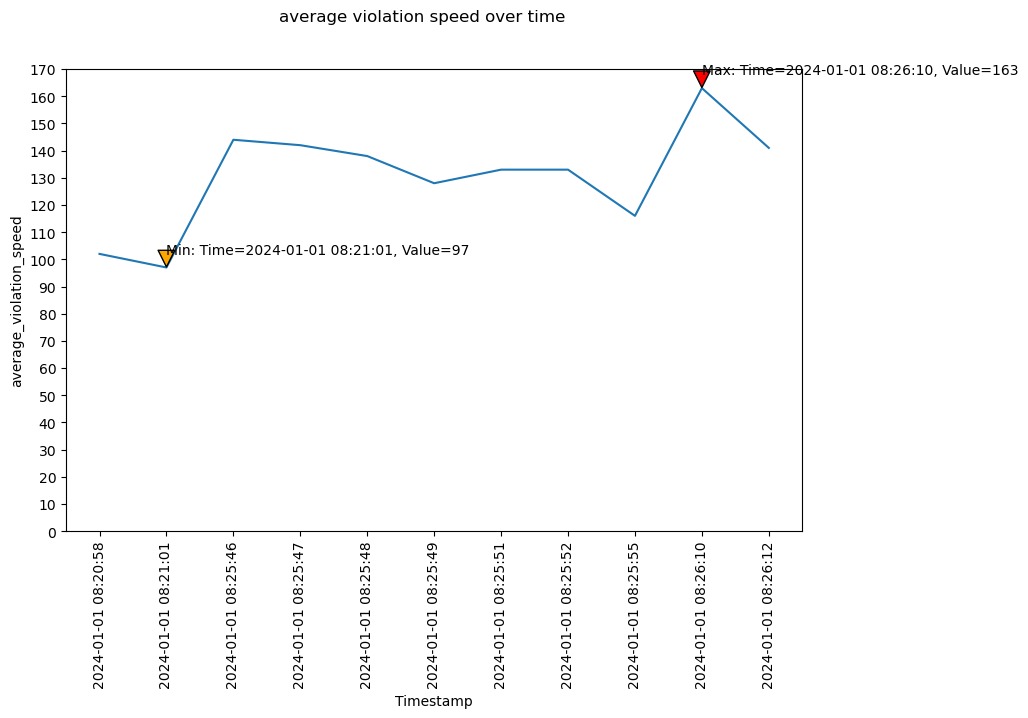

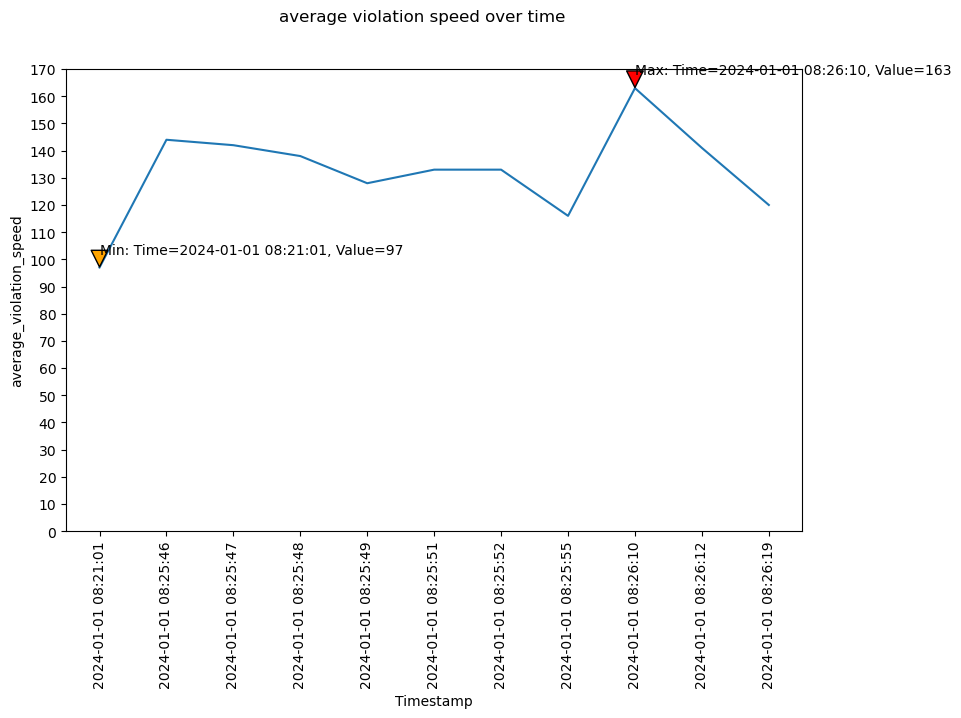

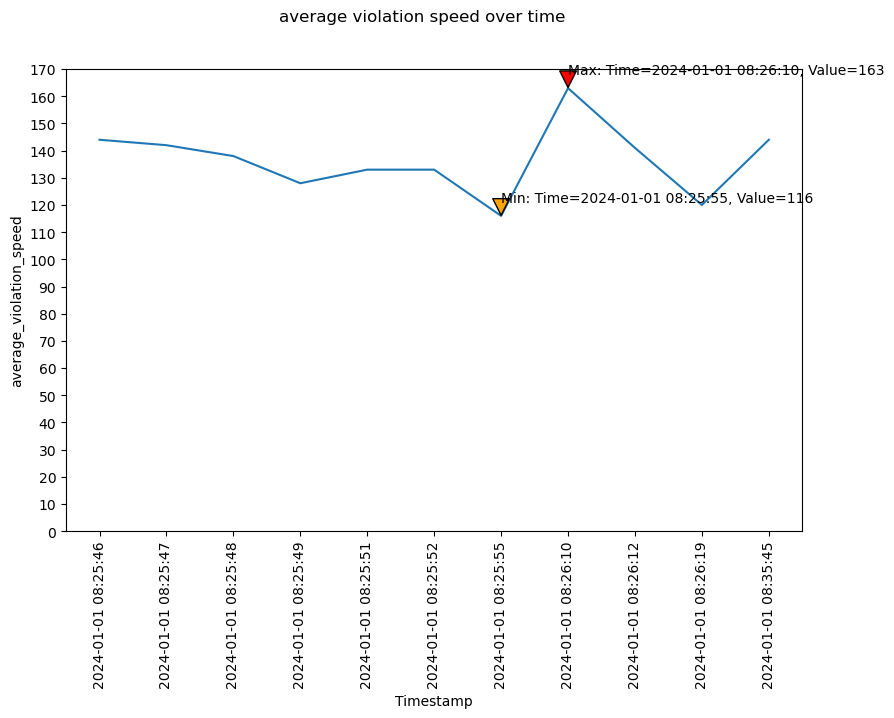

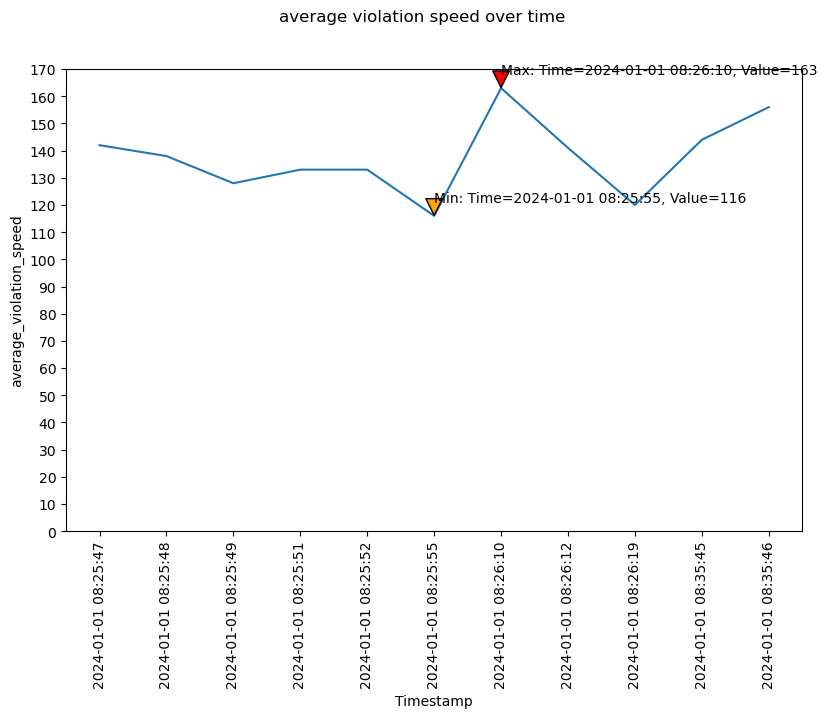

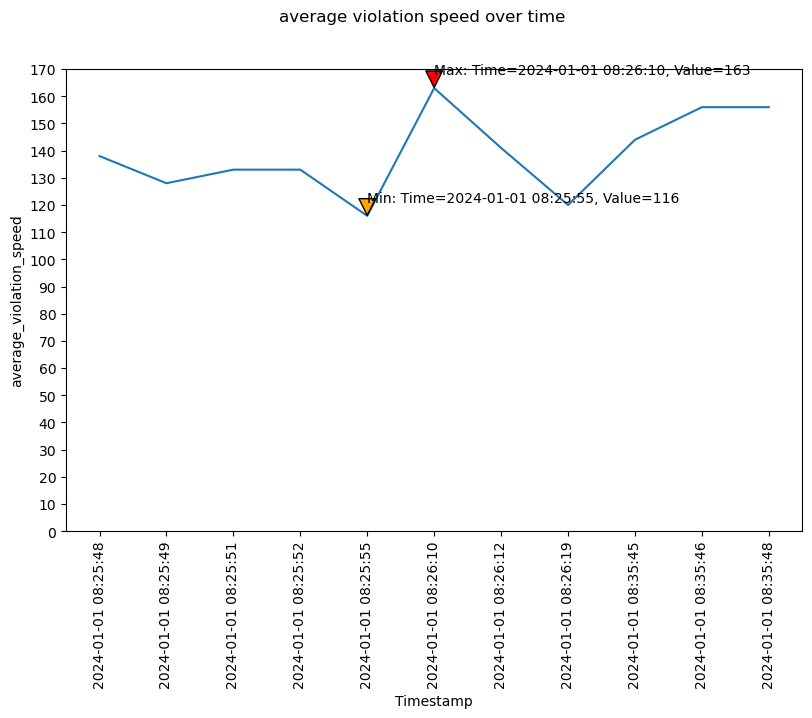

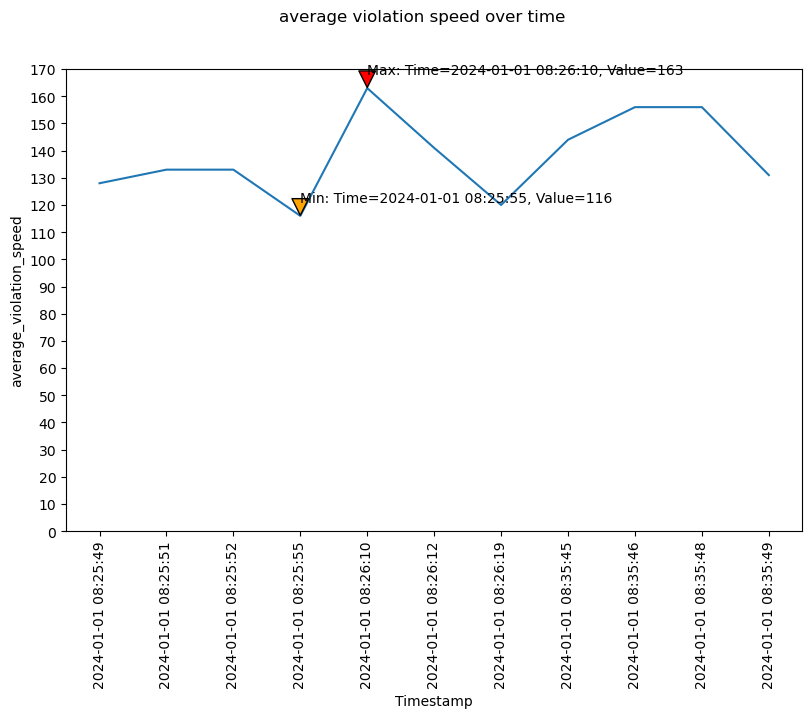

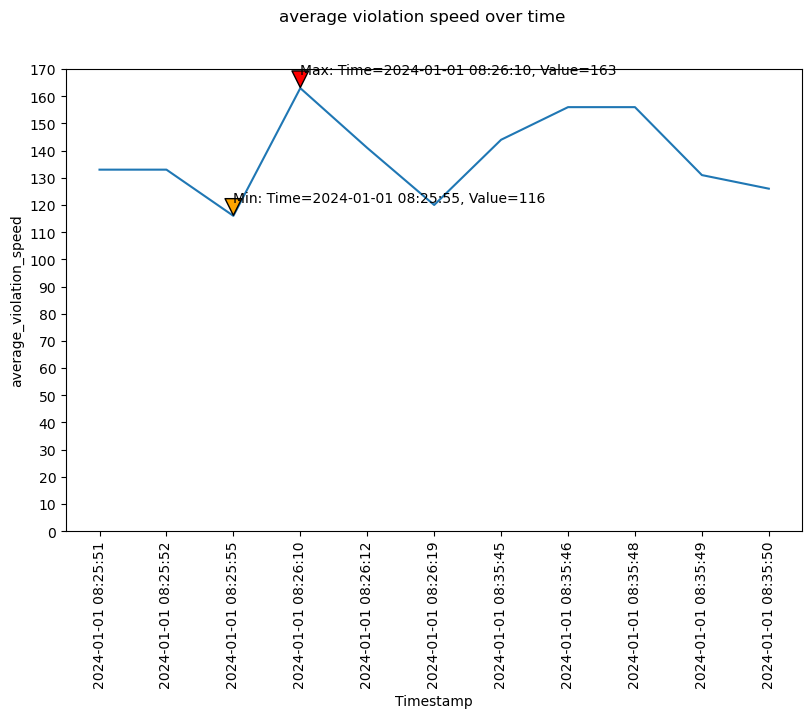

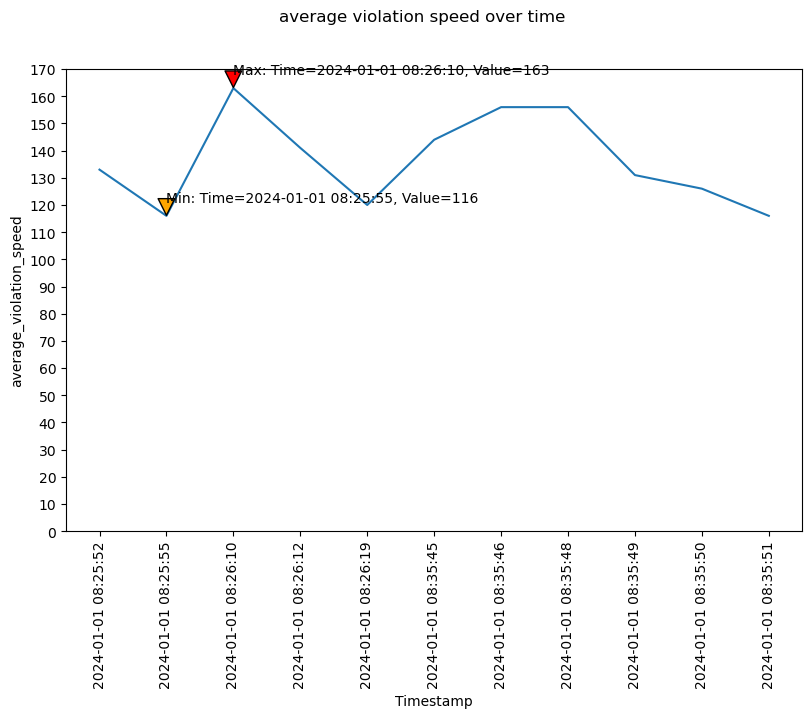

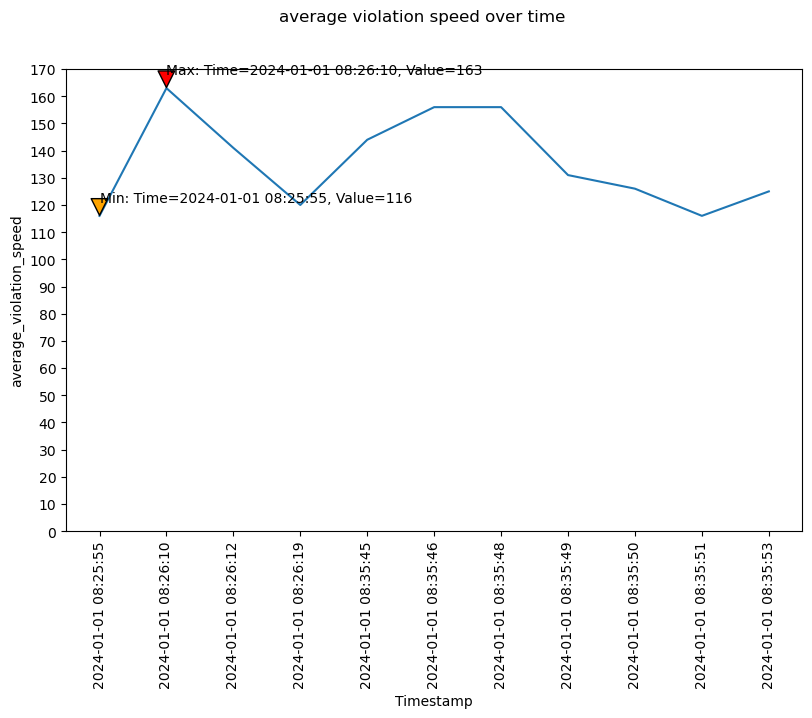

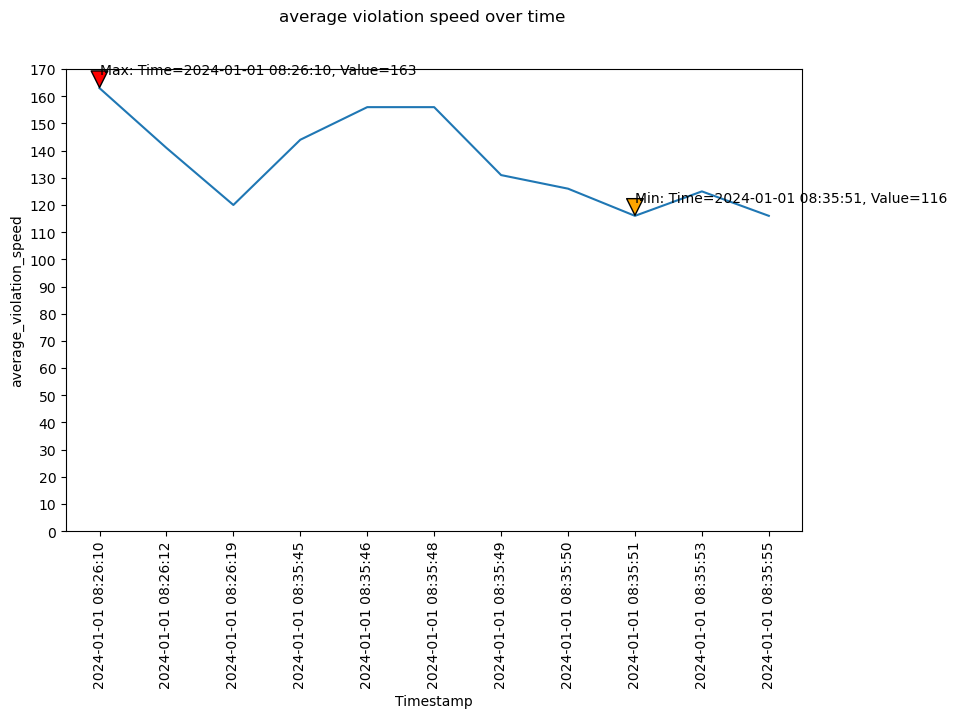

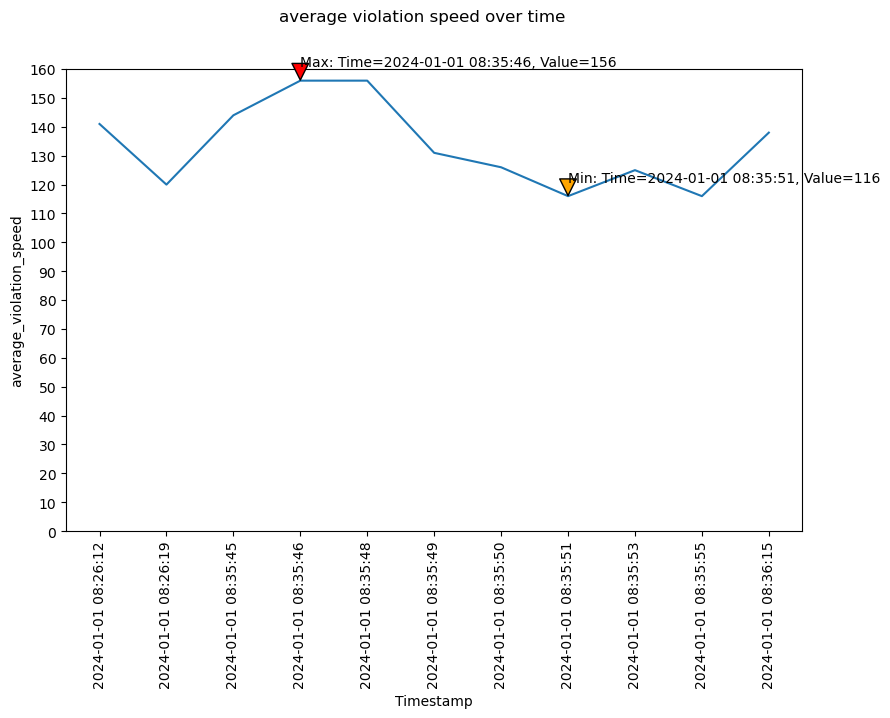

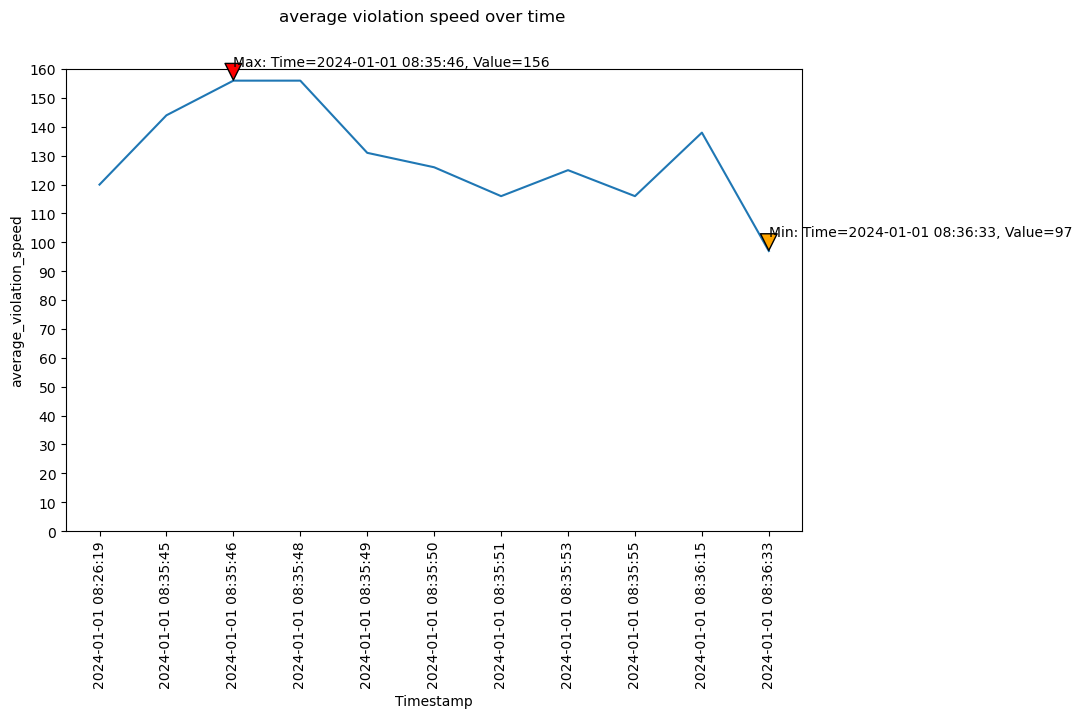

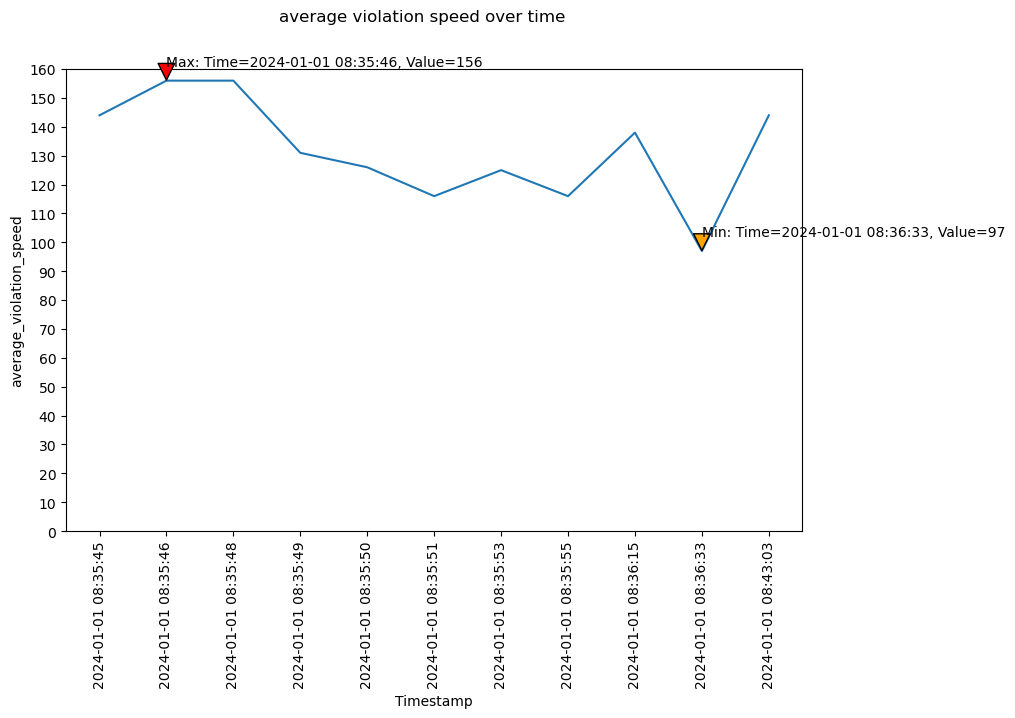

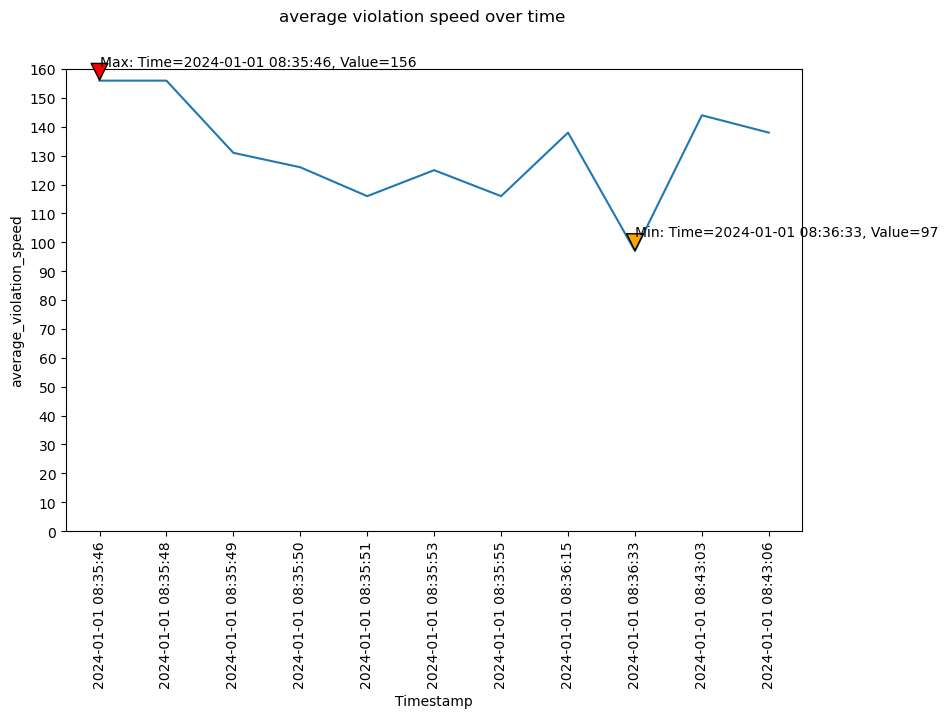

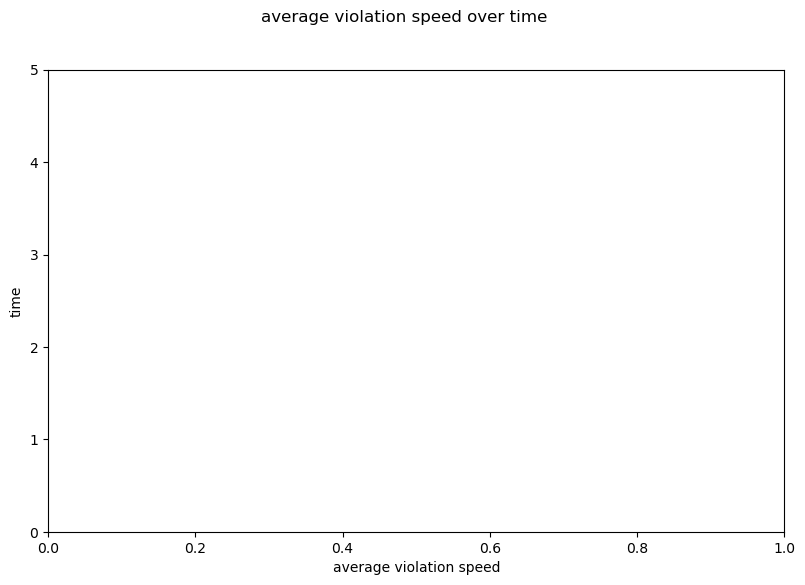

In [3]:
# Preparing the data for plotting
violations_list = list(violations.aggregate([{"$unwind":"$violations_today"},
                                             {"$group":{"_id":{"$dateToString":{"format":"%Y-%m-%d %H:%M:%S", "date":"$violations_today.timestamp_end"}}, "average_speed":{"$avg":"$violations_today.speed_reading"}}},
                                             {"$sort":{"_id":1}}]))

def init_plots():
    try:
        width = 9.5
        height = 6
        fig = plt.figure(figsize=(width,height)) # create new figure
        ax = fig.add_subplot(111) # adding the subplot axes to the given grid position
        fig.suptitle('average violation speed over time') # giving figure a title
        ax.set_xlabel('average violation speed')
        ax.set_ylabel('time')
        ax.set_ylim(0,5)
        ax.set_yticks([0,1,2,3,4,5])
        #fig.show() # displaying the figure
        fig.canvas.draw() # drawing on the canvas
        return fig, ax
    except Exception as ex:
        print(str(ex))

def annotate_max(x, y, ax = None):
    ymax = max(y)
    xpos = y.index(ymax)
    xmax = x[xpos]
    text = 'Max: Time={}, Value={}'.format(xmax, ymax)
    if not ax:
        ax=plt.gca()
    ax.annotate(text, xy=(xmax, ymax), xytext=(xmax, ymax+5), arrowprops=dict(facecolor='red', shrink=0.05),)
    
def annotate_min(x, y, ax = None):
    ymin = min(y)
    xpos = y.index(ymin)
    xmin = x[xpos]
    text = 'Min: Time={}, Value={}'.format(xmin, ymin)
    if not ax:
        ax=plt.gca()
    ax.annotate(text, xy=(xmin, ymin), xytext=(xmin, ymin+5), arrowprops=dict(facecolor='orange', shrink=0.05),)
    
def process_violations_average_speed_by_time(violations, fig, ax):
    try:
        # container for x and y values
        x, y = [], []
        # print('Waiting for messages')
        
        for violation in violations:
            y.append(int(violation["average_speed"]))
            x.append(violation["_id"])
            
            # we start plotting only when we have 10 data points
            if len(y) > 10:  
                ax.clear()
                ax.set_xlabel('Timestamp')
                ax.set_ylabel('average_violation_speed')
                ax.set_ylim(0, max(y))
                ax.set_yticks([y for y in range(0,max(y)+10, 10)])
                ax.plot(x, y)
                #annotate minimum and maximum points of average violation speed per time
                annotate_max(x,y,ax)
                annotate_min(x,y,ax)
                plt.xticks(rotation=90)
                fig.canvas.draw()
                plt.pause(0.01)#render the plots without maxing out memory
                x.pop(0)
                y.pop(0)
                fig,ax = init_plots() #initialize new plot so changes can be seen
    except Exception as ex:
        print(str(ex))
            
            
fig,ax = init_plots()
process_violations_average_speed_by_time(violations_list, fig, ax)